# PDO and NINO indices
Niño 1+2 (0-10S, 90W-80W):  The Niño 1+2 region is the smallest and eastern-most of the Niño SST regions, and corresponds with the region of coastal South America where El Niño was first recognized by the local populations.  This index tends to have the largest variance of the Niño SST indices.

Niño 3 (5N-5S, 150W-90W):  This region was once the primary focus for monitoring and predicting El Niño, but researchers later learned that the key region for coupled ocean-atmosphere interactions for ENSO lies further west (Trenberth, 1997).  Hence, the Niño 3.4 and ONI became favored for defining El Niño and La Niña events.

Niño 3.4 (5N-5S, 170W-120W):  The  Niño 3.4 anomalies may be thought of as representing the average equatorial SSTs across the Pacific from about the dateline to the South American coast.  The Niño 3.4 index typically uses a 5-month running mean, and El Niño or La  Niña events are defined when the  Niño 3.4 SSTs exceed +/- 0.4C for a period of six months or more.

Niño 4 (5N-5S, 160E-150W): The  Niño 4 index captures SST anomalies in the central equatorial Pacific. This region tends to have less variance than the other Niño regions.

## 0. Set up

### 0.1 Import packages

In [8]:
import cmocean
import numpy as np
import xarray as xr
import random
import pandas as pd
import pickle
import cftime
import dask
import matplotlib.pyplot as plt
import os
import xesmf as xe
import pop_tools
import cartopy
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from eofs.xarray import Eof
from cartopy.mpl.ticker import LongitudeFormatter,LatitudeFormatter
from cartopy.util import add_cyclic_point
import matplotlib
import matplotlib.patches as mpatches
from matplotlib.patches import Rectangle
import matplotlib.dates as mdates
from matplotlib.animation import FuncAnimation
from IPython.display import HTML
from matplotlib.animation import FFMpegWriter as fw
from matplotlib.animation import PillowWriter as pw
from IPython.utils import io
from os.path import exists
import re
import bottleneck
from scipy.interpolate import interp1d
import imageio
import pop_tools
# import ocetrac
import dask_jobqueue
import distributed
import dask.array as da
from scipy.stats import gaussian_kde
import time
import json
import warnings
warnings.filterwarnings("ignore", category=RuntimeWarning)

### 0.2 Functions

In [10]:
def find_identifier_with_index(prefixes, identifier):
    """
    Find prefixes that contain a specific identifier and their indices.

    Parameters:
        prefixes (list): A list of prefixes to search through.
        identifier (str): The identifier to search for in the prefixes.

    Returns:
        list: A list of tuples containing matching prefixes and their indices.
    """
    matching_prefixes_with_indices = []  # Initialize a list to store matches and their indices

    for index, prefix in enumerate(prefixes):  # Use enumerate to get both index and prefix
        if identifier in prefix:  # Check if the identifier is in the prefix
            matching_prefixes_with_indices.append((prefix, index))  # Add the prefix and index as a tuple

    return matching_prefixes_with_indices  # Return the list of matching prefixes and indices
    
def get_hist_file_paths(var, directory, path_intermed_hist, index):
    attrib_title = path_intermed_hist[index]
    file_paths = []
    for start_year in range(1850, 2010, 10):
        end_year = start_year + 9
        file_path = f'{directory}{attrib_title}.{var}.{start_year}01-{end_year}12.nc'
        file_paths.append(file_path)
    last_file_path = f'{directory}{attrib_title}.{var}.201001-201412.nc'
    file_paths.append(last_file_path)
    return file_paths

def get_fut_file_paths(var, directory, path_intermed_fut, index):
    attrib_title = path_intermed_fut[index]
    file_paths = []
    for start_year in range(2015, 2095, 10):
        end_year = start_year + 9
        file_path = f'{directory}{attrib_title}.{var}.{start_year}01-{end_year}12.nc'
        file_paths.append(file_path)
    last_file_path = f'{directory}{attrib_title}.{var}.209501-210012.nc'
    file_paths.append(last_file_path)
    return file_paths

def file_path_to_var_ds(file_paths):
    var_ds = xr.open_mfdataset(file_paths, 
                                 concat_dim='time', 
                                 combine='nested', 
                                 parallel=True)
    return var_ds

def get_var_paths(directory, var):
    # Prefixes to match for future and historical datasets
    prefixes_to_match_fut = ['b.e21.BSSP370cmip6.', 'b.e21.BSSP370smbb.']
    prefixes_to_match_hist = ['b.e21.BHISTcmip6.', 'b.e21.BHISTsmbb.']
        
    # Sets to store unique prefixes for future and historical filenames
    prefixes_fut = list()
    prefixes_hist = list()
        
    # Iterate through files in the directory
    for filename in os.listdir(directory):
        # Check and add prefixes for future scenario files
        if any(filename.startswith(prefix) for prefix in prefixes_to_match_fut) and filename.endswith('.nc'):
            prefixes_fut.append(filename.rsplit('.', 3)[0])
            
        # Check and add prefixes for historical scenario files
        if any(filename.startswith(prefix) for prefix in prefixes_to_match_hist) and filename.endswith('.nc'):
            prefixes_hist.append(filename.rsplit('.', 3)[0])
        
    prefixes_hist_set = set(prefixes_hist)
    sorted_unique_list_hist = sorted(prefixes_hist_set)
    
    prefixes_fut_set = set(prefixes_fut)
    sorted_unique_list_fut = sorted(prefixes_fut_set)
    
    path_intermed_fut = sorted_unique_list_fut
    path_intermed_hist = sorted_unique_list_hist

    return path_intermed_hist, path_intermed_fut

def get_ds_var(directory, var, comp, index_hist):
    path_intermed_hist, path_intermed_fut = get_var_paths(directory, var)
    filename_identifier = '.'.join(path_intermed_hist[index_hist].rsplit('.', 5)[1:4])
    index_fut = find_identifier_with_index(path_intermed_hist, filename_identifier)[0][1]
    hist_file_paths = get_hist_file_paths(var,directory, path_intermed_hist, index_hist)
    fut_file_paths = get_fut_file_paths(var, directory, path_intermed_fut, index_fut)
    ds_var_fut = file_path_to_var_ds(fut_file_paths)
    ds_var_hist = file_path_to_var_ds(hist_file_paths)
    return ds_var_hist, ds_var_fut

In [11]:
def calculate_anomalies_trend_features(ds):
    sst = ds
    dyr = ds.time.dt.year + ds.time.dt.month/12
    # Our 6 coefficient model is composed of the mean, trend, annual sine and cosine harmonics, & semi-annual sine and cosine harmonics
    model = np.array([np.ones(len(dyr))] + [dyr-np.mean(dyr)] + [np.sin(2*np.pi*dyr)] + [np.cos(2*np.pi*dyr)] + [np.sin(4*np.pi*dyr)] + [np.cos(4*np.pi*dyr)])
    
    # Take the pseudo-inverse of model to 'solve' least-squares problem
    pmodel = np.linalg.pinv(model)
    
    # Convert model and pmodel to xaray DataArray
    model_da = xr.DataArray(model.T, dims=['time','coeff'], coords={'time':sst.time.values, 'coeff':np.arange(1,7,1)}) 
    pmodel_da = xr.DataArray(pmodel.T, dims=['coeff','time'], coords={'coeff':np.arange(1,7,1), 'time':sst.time.values})  
    
    # resulting coefficients of the model
    sst_mod = xr.DataArray(pmodel_da.dot(sst), dims=['coeff','lat','lon'], coords={'coeff':np.arange(1,7,1), 'lat':sst.lat.values, 'lon':sst.lon.values})
    
    # Construct mean, trend, and seasonal cycle
    mean = model_da[:,0].dot(sst_mod[0,:,:])
    trend = model_da[:,1].dot(sst_mod[1,:,:])
    seas = model_da[:,2:].dot(sst_mod[2:,:,:])
    
    # compute anomalies by removing all  the model coefficients 
    ssta_notrend = sst-model_da.dot(sst_mod)
    
    # Use the 90th percentile as a threshold and find anomalies that exceed it. 
    if ssta_notrend.chunks:
        ssta_notrend = ssta_notrend.chunk({'time': -1})
    
    threshold = ssta_notrend.quantile(.9, dim=('time'))
    features_notrend = ssta_notrend.where(ssta_notrend>=threshold, other=np.nan)
    return mean, trend, seas, features_notrend, ssta_notrend

In [12]:
def setup_axes(ax):
    ax.add_feature(cfeature.LAND, facecolor='white', zorder=2)
    ax.coastlines(resolution='110m', color='black', lw=2)
    ax.set_ylabel('latitude')
    ax.set_xlabel('longitude')


def lons_to_360(data, coord='lon'):
    """ Converts longitude coordinates from (-180, 180) to (0, 360)."""
    data.coords[coord] = (360 + (data.coords[coord] % 360)) % 360
    data = data.sortby(data[coord])
    return data


def remove_trend(da, dim, deg=1):
    # detrend along a single dimension
    # return polyfit coefficients and detrended da
    p = da.polyfit(dim=dim, deg=deg, skipna=True)
    coord = da.coords[dim]
    fit = xr.polyval(coord, p.polyfit_coefficients)
    return da - fit


def get_anoms(da):
    clim = da.groupby('time.month').mean('time')
    da_noclim = da.groupby('time.month') - clim
    anoms = remove_trend(da_noclim, dim='time')
    return anoms


def regrid_SMYLE(ds, glat=1, glon=1):
    """
    Inputs:
        ds: xr.DataArray with coordinates that include TLAT and TLONG
    Returns:
        Regridded xr.DataArray with coordinates lat and lon
    """
    ds = ds.rename(({'TLONG': 'lon', 'TLAT': 'lat'}))
    ds_out = xe.util.grid_global(glon, glat)
    regridder = xe.Regridder(ds, ds_out, 'bilinear', periodic=True)
    regridded = regridder(ds)
    new_coords = regridded.assign_coords({'y': regridded.lat[:, 0].values, 'x': regridded.lon[0].values})
    return new_coords.drop_vars(['lat', 'lon']).rename({'x': 'lon', 'y': 'lat'})

In [13]:
def calculate_deseasonalized_only(ds):
    """
    Removes mean and annual/semiannual harmonics only, retaining the trend.
    Matches the LENS 'noseas' (seasonality-removal-only) convention.
    """
    sst = ds
    dyr = ds.time.dt.year + ds.time.dt.month / 12

    # 4-coefficient model: mean, annual sin/cos, semiannual sin/cos (NO trend term)
    model = np.array(
        [np.ones(len(dyr))] +
        [np.sin(2*np.pi*dyr)] +
        [np.cos(2*np.pi*dyr)] +
        [np.sin(4*np.pi*dyr)] +
        [np.cos(4*np.pi*dyr)]
    )

    pmodel = np.linalg.pinv(model)

    model_da = xr.DataArray(model.T, dims=['time','coeff'],
                             coords={'time': sst.time.values, 'coeff': np.arange(1,6,1)})
    pmodel_da = xr.DataArray(pmodel.T, dims=['coeff','time'],
                              coords={'coeff': np.arange(1,6,1), 'time': sst.time.values})

    sst_mod = xr.DataArray(pmodel_da.dot(sst), dims=['coeff','lat','lon'],
                            coords={'coeff': np.arange(1,6,1), 'lat': sst.lat.values, 'lon': sst.lon.values})

    # Deseasonalized anomaly = observed minus (mean + seasonal harmonics), trend RETAINED
    seasonal_fit = model_da.dot(sst_mod)
    ssta_deseasonalized_only = sst - seasonal_fit

    return ssta_deseasonalized_only

## Load data

In [45]:

# ============================================================
# Standard index domains
# ============================================================
nino34_lat, nino34_lon = slice(-5, 5), slice(190, 240)      # 5N-5S, 170W-120W
pdo_lat, pdo_lon = slice(20, 65), slice(120, 260)            # 20-65N, full basin

In [73]:
fosi_blobs = xr.open_dataset('fosi_blobs_r2.nc').labels
object_id = 94.0
blob_times = fosi_blobs.time.where((fosi_blobs == object_id).any(dim=('lat','lon')), drop=True)

print(f"n_months: {len(blob_times)}")  # should print 20

n_months: 20


In [41]:
#### CESM LENS2
var = 'SST'
comp = 'atm'
directory = f'/glade/campaign/cgd/cesm/CESM2-LE/{comp}/proc/tseries/month_1/{var}/'
ens_memb_index = 0
ds_var_hist_SST, ds_var_fut_SST = get_ds_var(directory, 'SST','atm', ens_memb_index) 

# selecting our observational time period overlap with ERA5 (1979 to 2022)
CESMLENS_SST_hist_time_slice = ds_var_hist_SST.SST.sel(time=slice('1979-01-01', '2015-01-01'))
    
CESMLENS_SST_fut_time_slice = ds_var_fut_SST.SST.sel(time=slice('2015-02-01', '2020-12-01'))

CESMLENS_SST_ds = xr.concat([CESMLENS_SST_hist_time_slice, CESMLENS_SST_fut_time_slice], dim='time')
CESMLENS_SST = CESMLENS_SST_ds.compute()

In [40]:
#### FOSI
firstyear = 1979
lastyear = 2020
field = 'TEMP'

# Mask the Arctic, the Baltic Sea, the Red Sea, and the Black Sea
grid = pop_tools.get_grid('POP_gx1v7')
mask = xr.where((grid['REGION_MASK']>0) & (grid['REGION_MASK']<9), 1, np.nan)

fpath = '/glade/campaign/cesm/development/espwg/SMYLE/initial_conditions/SMYLE-FOSI/ocn/proc/tseries/month_1/'
fname = f'g.e22.GOMIPECOIAF_JRA-1p4-2018.TL319_g17.SMYLE.005.pop.h.{field}.030601-036812.nc'
ds_smyle_fosi = xr.open_dataset(fpath+fname)[field].isel(z_t=0)

fosi_montime_vals = [cftime.DatetimeNoLeap(1958+year, 1+month, 15) for year in range(63) for month in range(12)]
ds_smyle_fosi['time'] = fosi_montime_vals
fosi_temp = ds_smyle_fosi[ds_smyle_fosi.time['time.year'].isin(list(range(firstyear, lastyear+1)))].where(mask==1, np.nan)

fosi_anom_1deg_wzeros = regrid_SMYLE(ds_smyle_fosi)
fosi_anom_1deg = fosi_anom_1deg_wzeros.where(fosi_anom_1deg_wzeros!=0, np.nan)

regridder = xe.Regridder(fosi_anom_1deg.sel(time=slice('1979-01-01','2020-12-01')), CESMLENS_SST[:,:,:], 'nearest_s2d', periodic=True)
regridded = regridder(fosi_anom_1deg.sel(time=slice('1979-01-01','2020-12-01')))
# regridded[4,:,:].plot.contourf(levels=25)

NameError: name 'CESMLENS_SST' is not defined

In [43]:
dyr = regridded.time.dt.year + regridded.time.dt.month/12

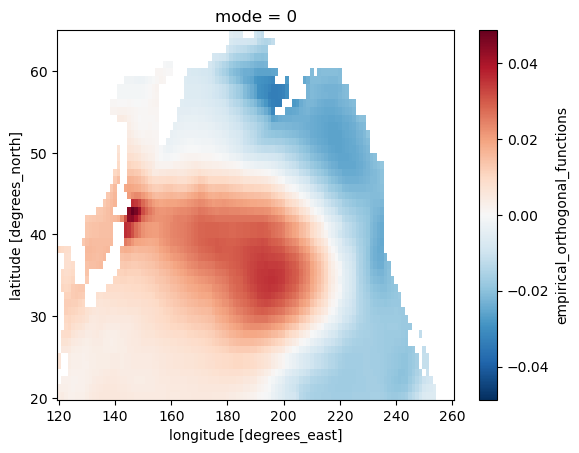

In [46]:
# ============================================================
# FOSI: deseasonalized-only (noseas) SST, FULL basin (not NEP-cropped)
# ============================================================
# 'regridded' = raw FOSI SST, full basin, from your existing pipeline (cell 19 of this notebook)
sst_fosi_noseas_full = calculate_deseasonalized_only(regridded)  # function from earlier this session

nino34_fosi_region = sst_fosi_noseas_full.sel(lat=nino34_lat, lon=nino34_lon)
pdo_fosi_region = sst_fosi_noseas_full.sel(lat=pdo_lat, lon=pdo_lon)

# Niño3.4: simple area-weighted mean, no EOF needed
weights_nino = np.cos(np.deg2rad(nino34_fosi_region.lat))
nino34_fosi = (nino34_fosi_region * weights_nino).mean(dim=('lat','lon')) / weights_nino.mean()
nino34_fosi_norm = nino34_fosi / float(nino34_fosi.std())

# PDO: EOF-based, full basin
solver = Eof(pdo_fosi_region)
eof1_pdo_full = solver.eofs(neofs=1).isel(mode=0)
eof1_pdo_full.plot()  # CHECK SIGN before proceeding

In [47]:
# --- After checking the plot, apply sign correction if needed ---
eof1_pdo_full_fixed = -eof1_pdo_full  # flip based on what the plot shows

def project_onto_pattern(sst_anom, pattern):
    sst_anom, pattern = xr.align(sst_anom, pattern, join='inner')
    return (sst_anom * pattern).sum(dim=('lat','lon')) / (pattern**2).sum(dim=('lat','lon'))

pdo_fosi = project_onto_pattern(pdo_fosi_region, eof1_pdo_full_fixed)
pdo_std = float(pdo_fosi.std())
pdo_fosi_norm = pdo_fosi / pdo_std

print(f"Niño3.4 during Blob: mean={float(nino34_fosi_norm.sel(time=blob_times).mean()):.2f}, "
      f"max={float(nino34_fosi_norm.sel(time=blob_times).max()):.2f}")
print(f"PDO during Blob: mean={float(pdo_fosi_norm.sel(time=blob_times).mean()):.2f}, "
      f"max={float(pdo_fosi_norm.sel(time=blob_times).max()):.2f}")

Niño3.4 during Blob: mean=1.13, max=3.08
PDO during Blob: mean=1.02, max=1.85


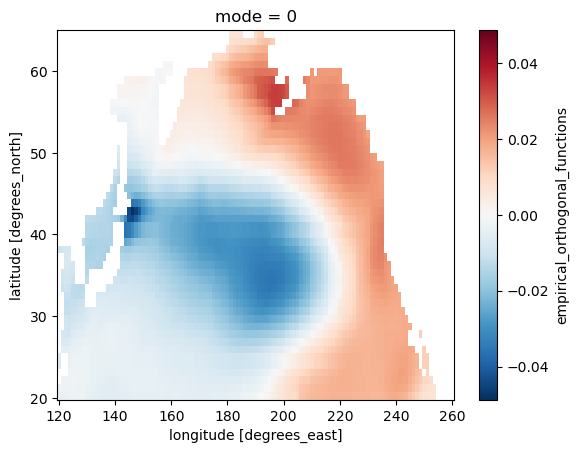

In [48]:
eof1_pdo_full_fixed.plot()

In [18]:
# ============================================================
# CESM2-LENS: full-basin, RAW SST (not the NEP-cropped ens_{i}_ssta.nc files)
# Reuses your existing get_ds_var pattern from cells 10-13, per member
# ============================================================
def load_lens_sst_full_basin(member_id):
    directory = '/glade/campaign/cgd/cesm/CESM2-LE/atm/proc/tseries/month_1/SST/'
    ds_hist, ds_fut = get_ds_var(directory, 'SST', 'atm', member_id)
    hist = ds_hist.SST.sel(time=slice('1979-01-01','2015-01-01'))
    fut = ds_fut.SST.sel(time=slice('2015-02-01','2020-12-01'))
    combined = xr.concat([hist, fut], dim='time').compute()
    return combined.where(combined != 0, np.nan)

nino34_lens = {}
pdo_lens = {}

for member_id in range(100):
    print(member_id)
    sst_member = load_lens_sst_full_basin(member_id)
    sst_member_noseas = calculate_deseasonalized_only(sst_member)

    nino_region = sst_member_noseas.sel(lat=nino34_lat, lon=nino34_lon)
    w = np.cos(np.deg2rad(nino_region.lat))
    nino34_lens[member_id] = ((nino_region * w).mean(dim=('lat','lon')) / w.mean()) / float(nino34_fosi.std())

    pdo_region = sst_member_noseas.sel(lat=pdo_lat, lon=pdo_lon)
    pdo_lens[member_id] = project_onto_pattern(pdo_region, eof1_pdo_full_fixed) / pdo_std

    if member_id % 10 == 0:
        print(f"Member {member_id} done")

nino34_lens_all = xr.concat(list(nino34_lens.values()), dim='member').assign_coords(member=np.arange(100))
pdo_lens_all = xr.concat(list(pdo_lens.values()), dim='member').assign_coords(member=np.arange(100))

0
Member 0 done
1
2
3
4
5
6
7
8
9
10
Member 10 done
11
12
13
14
15
16
17
18
19
20
Member 20 done
21
22
23
24
25
26
27
28
29
30
Member 30 done
31
32
33
34
35
36
37
38
39
40
Member 40 done
41
42
43
44
45
46
47
48
49
50
Member 50 done
51
52
53
54
55
56
57
58
59
60
Member 60 done
61
62
63
64
65
66
67
68
69
70
Member 70 done
71
72
73
74
75
76
77
78
79
80
Member 80 done
81
82
83
84
85
86
87
88
89
90
Member 90 done
91
92
93
94
95
96
97
98
99


In [19]:
t0 = time.time()
sst_test = load_lens_sst_full_basin(0)
print(f"Time to load member 0: {time.time()-t0:.1f}s")

Time to load member 0: 1.6s


In [7]:
nino34_lens_all = xr.open_dataset('/glade/derecho/scratch/cassiacai/nino34_lens_full_basin.nc')
pdo_lens_all = xr.open_dataset('/glade/derecho/scratch/cassiacai/pdo_lens_full_basin.nc')

In [14]:
# ============================================================
# Filepaths for the four detrending methods (CONFIRMED CORRECT this session)
# ============================================================
base_paths = {
    'linear': '/glade/work/cmendiola/data_conv_lin_trend',
    'quadratic': '/glade/work/cmendiola/data_quad_trend',
    'ensmean': '/glade/work/cmendiola/data_ens_mean',
    'noseas': '/glade/work/cmendiola/data_rm_seasonalcycle_mean',
}

RADIUS_INDEX_FOR_2DEG = 1  # confirmed: index 1 = 2° structuring element, consistent across all four methods

# SSTa variable names per method (confirmed this session)
ssta_varnames = {
    'linear': '__xarray_dataarray_variable__',
    'quadratic': '__xarray_dataarray_variable__',
    'ensmean': 'SST',
    'noseas': '__xarray_dataarray_variable__',
}

In [15]:
# ============================================================
# Load all four methods: labels + SSTa (radius-corrected, time-restricted to 1979-2020)
# ============================================================
da_mhwobj_labels_by_method = {}
ssta_notrend_by_method = {}

for method, base_path in base_paths.items():
    mhwobj_paths = [f'{base_path}/ens_{i}_mhwobj.nc' for i in range(100)]
    ssta_paths = [f'{base_path}/ens_{i}_ssta.nc' for i in range(100)]

    da_mhwobj = xr.open_mfdataset(mhwobj_paths, combine='nested', concat_dim='ensemble_member')
    da_mhwobj_labels_by_method[method] = da_mhwobj.labels.sel(radius=RADIUS_INDEX_FOR_2DEG).sel(time=slice('1979-01','2020-12')).compute()

    ssta_notrend_by_method[method] = xr.open_mfdataset(ssta_paths, combine='nested', concat_dim='ensemble_member').compute()

print("All four methods loaded.")
print({m: da_mhwobj_labels_by_method[m].sizes for m in base_paths})

All four methods loaded.
{'linear': Frozen({'ensemble_member': 100, 'time': 504, 'lat': 64, 'lon': 81}), 'quadratic': Frozen({'ensemble_member': 100, 'time': 504, 'lat': 64, 'lon': 81}), 'ensmean': Frozen({'ensemble_member': 100, 'time': 504, 'lat': 64, 'lon': 81}), 'noseas': Frozen({'ensemble_member': 100, 'time': 504, 'lat': 64, 'lon': 81})}


In [16]:
# ============================================================
# Canonical footprint (mask_3) - used throughout for Blob-analog identification and area-averaging
# ============================================================
mask_3 = xr.open_dataset('mean_mask_3.nc').mhw_obj
mask_3_binary = xr.where(mask_3 > 0.1, 1, 0)

def calc_frac_overlap(one_obj, mask):
    one_obj_binary = xr.where(one_obj > 0, 1., 0)
    overlap = one_obj_binary + mask
    overlap_only = xr.where(overlap > 1, 1., 0)
    overlap_frac = overlap_only.sum(dim=('lat','lon')) / mask.sum()
    if overlap_frac.size > 0 and overlap_frac.notnull().any():
        return overlap_frac.max().item()
    return 0.0

In [17]:
# ============================================================
# Cell area weighting (CESM2-LENS grid)
# ============================================================
R = 6371.0
grid_ref = da_mhwobj_labels_by_method['linear']
dlat = np.deg2rad(np.mean(np.diff(grid_ref.lat.values)))
dlon = np.deg2rad(np.mean(np.diff(grid_ref.lon.values)))
cell_area = (R**2) * dlat * dlon * np.cos(np.deg2rad(grid_ref.lat))
cell_area_da = xr.DataArray(cell_area.values, coords={'lat': grid_ref.lat}, dims='lat')

print(f"Equatorial gridcell area check: {float(cell_area_da.sel(lat=grid_ref.lat.values[len(grid_ref.lat)//2])):.1f} km²")

Equatorial gridcell area check: 11881.4 km²


In [20]:
# ============================================================
# Blob-analog IDs (50% overlap threshold, index 4 of thresholds array) - CORRECTED for all four methods
# ============================================================
thresholds = np.arange(0.1, 0.81, 0.1)

with open('object_id_ls_greenmask_linear_corrected.json', 'r') as f:
    linear_all_thresholds = json.load(f)
with open('object_id_ls_greenmask_ensmean_corrected.json', 'r') as f:
    ensmean_all_thresholds = json.load(f)
with open('object_id_ls_greenmask_quadratic_corrected.json', 'r') as f:
    quadratic_all_thresholds = json.load(f)
with open('object_id_ls_greenmask_noseas_corrected.json', 'r') as f:
    noseas_all_thresholds = json.load(f)
# adjust filenames/paths for quadratic and noseas to match wherever you saved those corrected versions

blob_analog_ids = {
    'linear': linear_all_thresholds[4],
    'ensmean': ensmean_all_thresholds[4],
    'quadratic': ensmean_all_thresholds[4],
    'noseas': ensmean_all_thresholds[4],
}

In [19]:
# ============================================================
# FOSI Blob (Label 94, confirmed 20-month window: May 2014 - Dec 2015)
# ============================================================
fosi_blobs = xr.open_dataset('fosi_blobs_r2.nc').labels
object_id = 94.0
blob_times = fosi_blobs.time.where((fosi_blobs == object_id).any(dim=('lat','lon')), drop=True)

regridded_ssta_no_trend_NEP = xr.open_dataset('/glade/derecho/scratch/cassiacai/regridded_ssta_no_trend_NEP.nc')

# Sanity check - should match your confirmed event max of 2.34°C
print(regridded_ssta_no_trend_NEP.sel(time='2015-07').max().values)
print(f"n_months in blob_times: {len(blob_times)}")  # should be 20

<bound method Mapping.values of <xarray.Dataset> Size: 12B
Dimensions:                        ()
Coordinates:
    z_t                            float32 4B ...
Data variables:
    __xarray_dataarray_variable__  float64 8B 2.345>
n_months in blob_times: 20


In [33]:
nino34_lens_all_da = nino34_lens_all['__xarray_dataarray_variable__']
pdo_lens_all_da = pdo_lens_all['__xarray_dataarray_variable__']  # check this matches - may have a different variable name

print(list(pdo_lens_all.data_vars))  # confirm the actual variable name before assuming it matches nino34's
# Confirm PDO's actual variable name (may differ from Niño3.4's)
print(list(pdo_lens_all.data_vars))

['__xarray_dataarray_variable__']
['__xarray_dataarray_variable__']


In [34]:
nino34_lens_all_da = nino34_lens_all['__xarray_dataarray_variable__']
pdo_lens_all_da = pdo_lens_all['__xarray_dataarray_variable__']  # adjust if the print above shows a different name

In [35]:
# ============================================================
# Rerun: per-analog Niño3.4 and PDO stats
# ============================================================
analog_climate_stats = {}
labels_full = da_mhwobj_labels_by_method['linear']

for member_id in range(100):
    member_labels = labels_full.isel(ensemble_member=member_id)
    member_nino = nino34_lens_all_da.sel(member=member_id)
    member_pdo = pdo_lens_all_da.sel(member=member_id)

    for analog_id in blob_analog_ids['linear'][member_id]:
        mask = (member_labels == analog_id)
        times_present = member_labels.time.where(mask.any(dim=('lat','lon')), drop=True)
        if len(times_present) == 0:
            continue

        nino_vals = member_nino.sel(time=times_present)
        pdo_vals = member_pdo.sel(time=times_present)

        analog_climate_stats[(member_id, analog_id)] = {
            'nino34_mean': float(nino_vals.mean()),
            'nino34_max': float(nino_vals.max()),
            'pdo_mean': float(pdo_vals.mean()),
            'pdo_max': float(pdo_vals.max()),
        }

print(f"Climate context computed for {len(analog_climate_stats)} analogs")

Climate context computed for 331 analogs


In [36]:
# ============================================================
# Rerun: Niño3.4 post-event check, using the corrected DataArray
# ============================================================
analog_nino_post_event = {}

for member_id in range(100):
    member_labels = labels_full.isel(ensemble_member=member_id)
    member_nino = nino34_lens_all_da.sel(member=member_id)

    for analog_id in blob_analog_ids['linear'][member_id]:
        mask = (member_labels == analog_id)
        times_present = member_labels.time.where(mask.any(dim=('lat','lon')), drop=True)
        if len(times_present) == 0:
            continue

        nino_during = member_nino.sel(time=times_present)

        full_time_index = member_labels.time
        last_idx = int(np.where(full_time_index.values == times_present.values[-1])[0][0])
        post_end_idx = min(last_idx + 6, len(full_time_index) - 1)

        if last_idx + 1 > post_end_idx:  # guard: no valid post-event window available
            continue

        post_times = full_time_index.isel(time=slice(last_idx + 1, post_end_idx + 1))
        if len(post_times) == 0:
            continue

        nino_after = member_nino.sel(time=post_times)

        analog_nino_post_event[(member_id, analog_id)] = {
            'max_during': float(nino_during.max()),
            'max_after_6mo': float(nino_after.max()),
        }

print(f"Computed for {len(analog_nino_post_event)} analogs")

Computed for 330 analogs


In [38]:
# ============================================================
# How often does Niño3.4 peak HIGHER after the event ends than during it?
# ============================================================
during_vals = np.array([v['max_during'] for v in analog_nino_post_event.values()])
after_vals = np.array([v['max_after_6mo'] for v in analog_nino_post_event.values()])

higher_after = after_vals > during_vals

print(f"Analogs where Niño3.4 peaks HIGHER in the 6 months after event end than during the event: "
      f"{np.sum(higher_after)} / {len(higher_after)} ({100*np.mean(higher_after):.1f}%)")

Analogs where Niño3.4 peaks HIGHER in the 6 months after event end than during the event: 120 / 330 (36.4%)


In [50]:
# Confirm blob_times is available
print(len(blob_times))  # should print 20

nino34_during_blob = nino34_fosi_norm.sel(time=blob_times)
print(f"Niño3.4 during Blob: mean={float(nino34_during_blob.mean()):.2f}, max={float(nino34_during_blob.max()):.2f}")

# ============================================================
# Same check for the FOSI Blob specifically
# ============================================================
nino34_after_blob = nino34_fosi_norm.sel(time=slice('2016-01', '2016-06'))
print(f"FOSI Blob: max Niño3.4 during event (May 2014-Dec 2015) = {float(nino34_during_blob.max()):.2f}")
print(f"FOSI Blob: max Niño3.4 in 6 months after (Jan-Jun 2016) = {float(nino34_after_blob.max()):.2f}")
print(f"Higher after? {float(nino34_after_blob.max()) > float(nino34_during_blob.max())}")

20
Niño3.4 during Blob: mean=1.13, max=3.08
FOSI Blob: max Niño3.4 during event (May 2014-Dec 2015) = 3.08
FOSI Blob: max Niño3.4 in 6 months after (Jan-Jun 2016) = 2.96
Higher after? False


In [53]:
blob_climate = {
    'nino34_mean': float(nino34_fosi_norm.sel(time=blob_times).mean()),
    'nino34_max': float(nino34_fosi_norm.sel(time=blob_times).max()),
    'pdo_mean': float(pdo_fosi_norm.sel(time=blob_times).mean()),
    'pdo_max': float(pdo_fosi_norm.sel(time=blob_times).max()),
}
print(blob_climate)

{'nino34_mean': 1.1281033521296626, 'nino34_max': 3.0774558632413305, 'pdo_mean': 1.0245222060799457, 'pdo_max': 1.8462614767620456}


In [54]:
print(f"Analogs where Niño3.4 peaks HIGHER in the 6 months after event end than during the event: "
      f"{np.sum(higher_after)} / {len(higher_after)} ({100*np.mean(higher_after):.1f}%)")

Analogs where Niño3.4 peaks HIGHER in the 6 months after event end than during the event: 120 / 330 (36.4%)


In [55]:
# ============================================================
# FOSI Blob: mean Niño3.4 during event vs. mean in 6 months after
# ============================================================
print(f"FOSI Blob: mean Niño3.4 during event (May 2014-Dec 2015) = {float(nino34_during_blob.mean()):.2f}")
print(f"FOSI Blob: mean Niño3.4 in 6 months after (Jan-Jun 2016) = {float(nino34_after_blob.mean()):.2f}")
print(f"Higher mean after? {float(nino34_after_blob.mean()) > float(nino34_during_blob.mean())}")

FOSI Blob: mean Niño3.4 during event (May 2014-Dec 2015) = 1.13
FOSI Blob: mean Niño3.4 in 6 months after (Jan-Jun 2016) = 1.70
Higher mean after? True


In [56]:
# ============================================================
# Population-level: mean Niño3.4 during vs. after, for all analogs
# ============================================================
# Need to add mean tracking to the post-event dict, similar to what we did for max
analog_nino_post_event_mean = {}

for member_id in range(100):
    member_labels = labels_full.isel(ensemble_member=member_id)
    member_nino = nino34_lens_all_da.sel(member=member_id)

    for analog_id in blob_analog_ids['linear'][member_id]:
        mask = (member_labels == analog_id)
        times_present = member_labels.time.where(mask.any(dim=('lat','lon')), drop=True)
        if len(times_present) == 0:
            continue

        nino_during = member_nino.sel(time=times_present)

        full_time_index = member_labels.time
        last_idx = int(np.where(full_time_index.values == times_present.values[-1])[0][0])
        post_end_idx = min(last_idx + 6, len(full_time_index) - 1)

        if last_idx + 1 > post_end_idx:
            continue

        post_times = full_time_index.isel(time=slice(last_idx + 1, post_end_idx + 1))
        if len(post_times) == 0:
            continue

        nino_after = member_nino.sel(time=post_times)

        analog_nino_post_event_mean[(member_id, analog_id)] = {
            'mean_during': float(nino_during.mean()),
            'mean_after_6mo': float(nino_after.mean()),
        }

during_means = np.array([v['mean_during'] for v in analog_nino_post_event_mean.values()])
after_means = np.array([v['mean_after_6mo'] for v in analog_nino_post_event_mean.values()])
higher_after_mean = after_means > during_means

print(f"\nAnalogs where MEAN Niño3.4 is HIGHER in the 6 months after event end than during the event: "
      f"{np.sum(higher_after_mean)} / {len(higher_after_mean)} ({100*np.mean(higher_after_mean):.1f}%)")


Analogs where MEAN Niño3.4 is HIGHER in the 6 months after event end than during the event: 140 / 330 (42.4%)


In [57]:
# ============================================================
# By how much? Blob specifically
# ============================================================
blob_increase = float(nino34_after_blob.mean()) - float(nino34_during_blob.mean())
blob_pct_increase = 100 * blob_increase / float(nino34_during_blob.mean())
print(f"FOSI Blob: increase = {blob_increase:.2f}σ ({blob_pct_increase:.1f}% increase)")

FOSI Blob: increase = 0.57σ (50.9% increase)


In [58]:
# ============================================================
# By how much? Population average
# ============================================================
increases = after_means - during_means
print(f"Population: mean increase = {increases.mean():.2f}σ, "
      f"median increase = {np.median(increases):.2f}σ")

# Just among the 42.4% that DID increase, how much did they increase by?
increases_where_higher = increases[higher_after_mean]
print(f"Among analogs with higher post-event mean: mean increase = {increases_where_higher.mean():.2f}σ, "
      f"median = {np.median(increases_where_higher):.2f}σ")

# Where does the Blob's increase rank relative to the population?
p_exceed = np.mean(increases >= blob_increase)
print(f"\nBlob's increase ({blob_increase:.2f}σ) exceeds {100*(1-p_exceed):.1f}% of analogs "
      f"({100*p_exceed:.1f}% of analogs show an equal or larger increase)")

Population: mean increase = -0.46σ, median increase = -0.20σ
Among analogs with higher post-event mean: mean increase = 0.91σ, median = 0.71σ

Blob's increase (0.57σ) exceeds 75.8% of analogs (24.2% of analogs show an equal or larger increase)


In [67]:
# ============================================================
# FOSI Blob: 6 months before onset + full event + 12 months after end
# ============================================================
pre_event_start = str(blob_times.values[0])[:7]  # e.g., '2014-05'
pre_event_window = nino34_fosi_norm.sel(time=slice(
    (blob_times.time.dt if False else None)  # placeholder, real slicing below
))

# Build the pre-event window explicitly using pandas date arithmetic
blob_start = pd.Timestamp(str(blob_times.values[0]))
blob_end = pd.Timestamp(str(blob_times.values[-1]))

pre_start = (blob_start - pd.DateOffset(months=6)).strftime('%Y-%m')
pre_end = (blob_start - pd.DateOffset(months=1)).strftime('%Y-%m')
post_start = (blob_end + pd.DateOffset(months=1)).strftime('%Y-%m')
post_end = (blob_end + pd.DateOffset(months=12)).strftime('%Y-%m')

pre_event_window = nino34_fosi_norm.sel(time=slice(pre_start, pre_end))
post_event_window = nino34_fosi_norm.sel(time=slice(post_start, post_end))

blob_full_window = xr.concat([
    pre_event_window,
    nino34_fosi_norm.sel(time=blob_times),
    post_event_window
], dim='time')

n_pre = len(pre_event_window)
n_during = len(blob_times)
n_post = len(post_event_window)

months_relative_blob = np.concatenate([
    np.arange(-n_pre, 0),          # pre-event: negative, ending at -1
    np.arange(0, n_during),         # during event: 0 to n_during-1
    np.arange(n_during, n_during + n_post)  # post-event: continues counting up
])

# Recenter so 0 = event START (more intuitive) or keep 0 = event END - here we align 0 to event START
months_relative_blob = months_relative_blob - n_pre  # shifts so pre-event starts negative, event start = 0

print(f"n_pre={n_pre}, n_during={n_during}, n_post={n_post}, total={len(blob_full_window)}")

n_pre=6, n_during=20, n_post=12, total=38


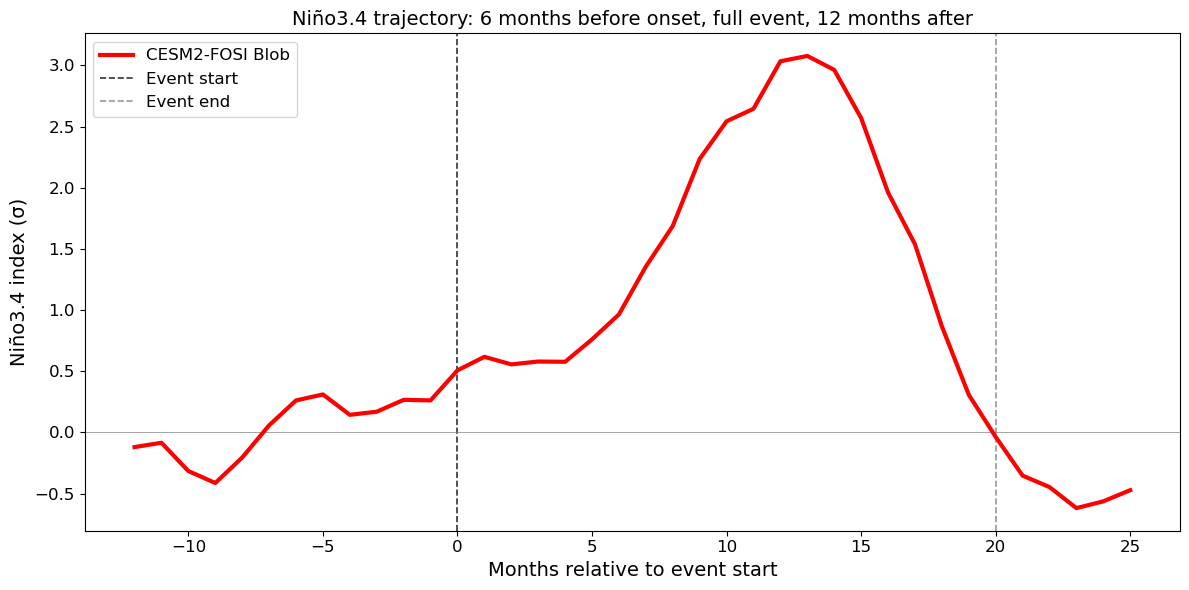

In [68]:
fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(months_relative_blob, blob_full_window.values, color='red', linewidth=3, label='CESM2-FOSI Blob', zorder=10)
ax.axvline(0, color='k', linestyle='--', linewidth=1.2, alpha=0.8, label='Event start')
ax.axvline(n_during, color='gray', linestyle='--', linewidth=1.2, alpha=0.8, label='Event end')
ax.axhline(0, color='gray', linewidth=0.5)

ax.set_xlabel('Months relative to event start', fontsize=14)
ax.set_ylabel('Niño3.4 index (σ)', fontsize=14)
ax.set_title('Niño3.4 trajectory: 6 months before onset, full event, 12 months after', fontsize=14)
ax.legend(fontsize=12)
ax.tick_params(labelsize=12)

plt.tight_layout()
plt.savefig('Figure_nino34_extended_trajectory.png', dpi=300, bbox_inches='tight')
plt.show()

Plotted 299 Blob-analog trajectories


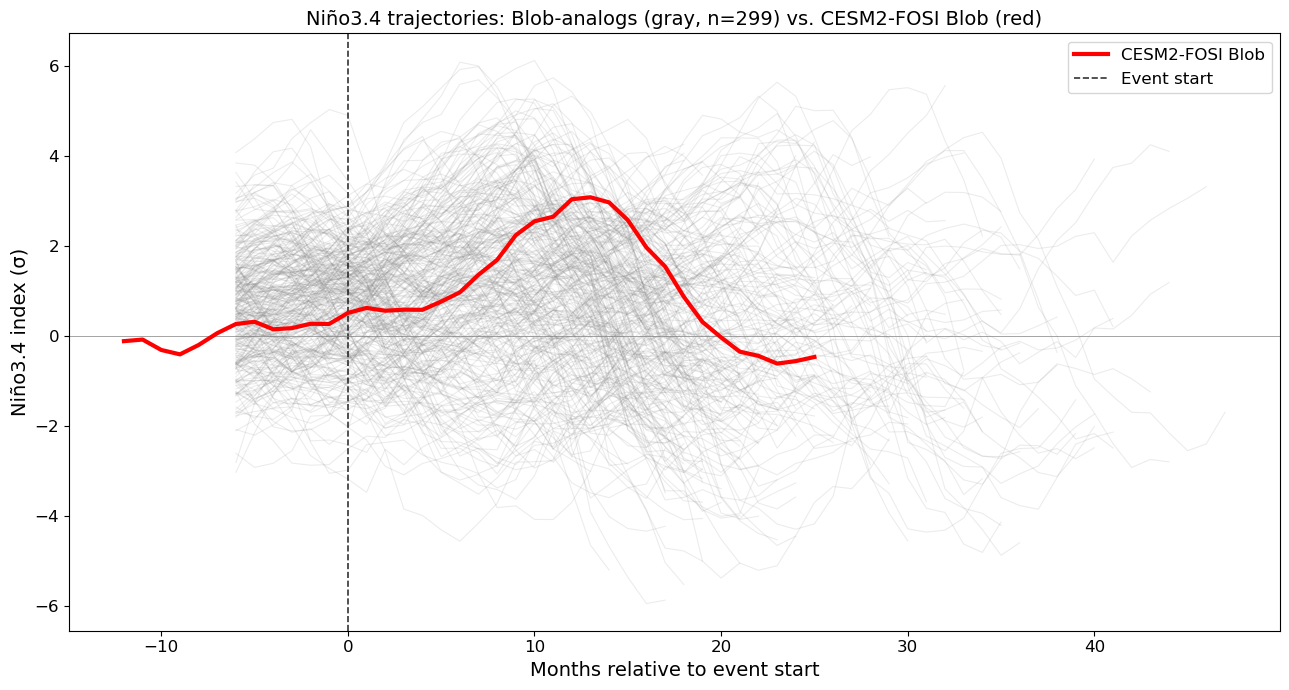

In [69]:
fig, ax = plt.subplots(figsize=(13, 7))

labels_full = da_mhwobj_labels_by_method['linear']
plotted_count = 0

for member_id in range(100):
    member_labels = labels_full.isel(ensemble_member=member_id)
    member_nino = nino34_lens_all_da.sel(member=member_id)
    full_time_index = member_labels.time

    for analog_id in blob_analog_ids['linear'][member_id]:
        mask = (member_labels == analog_id)
        times_present = member_labels.time.where(mask.any(dim=('lat','lon')), drop=True)
        if len(times_present) == 0:
            continue

        first_idx = int(np.where(full_time_index.values == times_present.values[0])[0][0])
        last_idx = int(np.where(full_time_index.values == times_present.values[-1])[0][0])

        pre_start_idx = max(0, first_idx - 6)
        post_end_idx = min(len(full_time_index) - 1, last_idx + 12)

        # Skip analogs where the extended window would run off either edge of the record
        if pre_start_idx == 0 and first_idx - 6 < 0:
            continue
        if post_end_idx == len(full_time_index) - 1 and last_idx + 12 > len(full_time_index) - 1:
            continue

        window_times = full_time_index.isel(time=slice(pre_start_idx, post_end_idx + 1))
        traj = member_nino.sel(time=window_times).values

        n_pre = first_idx - pre_start_idx
        n_during = len(times_present)
        months_rel = np.arange(len(traj)) - n_pre

        ax.plot(months_rel, traj, color='gray', alpha=0.15, linewidth=0.8, zorder=1)
        plotted_count += 1

print(f"Plotted {plotted_count} Blob-analog trajectories")

# Overlay the Blob's own extended trajectory, bold
ax.plot(months_relative_blob, blob_full_window.values, color='red', linewidth=3, label='CESM2-FOSI Blob', zorder=10)
ax.axvline(0, color='k', linestyle='--', linewidth=1.2, alpha=0.8, label='Event start')
ax.axhline(0, color='gray', linewidth=0.5)

ax.set_xlabel('Months relative to event start', fontsize=14)
ax.set_ylabel('Niño3.4 index (σ)', fontsize=14)
ax.set_title(f'Niño3.4 trajectories: Blob-analogs (gray, n={plotted_count}) vs. CESM2-FOSI Blob (red)', fontsize=14)
ax.legend(fontsize=12)
ax.tick_params(labelsize=12)

plt.tight_layout()
plt.savefig('Figure_nino34_all_analog_trajectories.png', dpi=300, bbox_inches='tight')
plt.show()

In [70]:
# ============================================================
# Check FOSI's own Niño3.4 trajectory around Nov 2015 specifically
# ============================================================
nino34_late2015 = nino34_fosi_norm.sel(time=slice('2015-09', '2016-06'))
print("FOSI Niño3.4, Sept 2015 - June 2016:")
for t, v in zip(nino34_late2015.time.values, nino34_late2015.values):
    print(f"  {str(t)[:7]}: {v:.2f}σ")

FOSI Niño3.4, Sept 2015 - June 2016:
  2015-09: 2.54σ
  2015-10: 2.65σ
  2015-11: 3.03σ
  2015-12: 3.08σ
  2016-01: 2.96σ
  2016-02: 2.57σ
  2016-03: 1.96σ
  2016-04: 1.54σ
  2016-05: 0.87σ
  2016-06: 0.31σ


In [71]:
# ============================================================
# Confirm: is FOSI's own peak month November 2015, matching the real record?
# ============================================================
peak_month_idx = int(nino34_fosi_norm.sel(time=slice('1979-01','2020-12')).argmax('time').values)
peak_month_date = nino34_fosi_norm.time.values[peak_month_idx]
peak_value = float(nino34_fosi_norm.isel(time=peak_month_idx))

print(f"\nFOSI's own all-time peak Niño3.4: {peak_value:.2f}σ, occurring in {str(peak_month_date)[:7]}")


FOSI's own all-time peak Niño3.4: 3.47σ, occurring in 1982-12


In [72]:
# ============================================================
# For each ensemble member, find its own all-time peak Niño3.4 and when it occurs
# ============================================================
member_peak_nino = {}

for member_id in range(100):
    member_nino = nino34_lens_all_da.sel(member=member_id)
    peak_idx = int(member_nino.argmax('time').values)
    peak_val = float(member_nino.isel(time=peak_idx))
    peak_date = member_nino.time.values[peak_idx]
    member_peak_nino[member_id] = {'value': peak_val, 'date': peak_date}

peak_values = np.array([v['value'] for v in member_peak_nino.values()])
print(f"Across 100 members: mean all-time peak Niño3.4 = {peak_values.mean():.2f}σ, "
      f"range = {peak_values.min():.2f} to {peak_values.max():.2f}")

Across 100 members: mean all-time peak Niño3.4 = 4.74σ, range = 3.49 to 6.15


In [73]:
# ============================================================
# Where does each Blob-analog's OWN event max rank relative to that member's all-time peak?
# i.e., did the Blob-analog occur during that member's strongest ENSO event, or a lesser one?
# ============================================================
analog_vs_member_peak = {}

for member_id in range(100):
    member_peak_val = member_peak_nino[member_id]['value']

    for analog_id in blob_analog_ids['linear'][member_id]:
        key = (member_id, analog_id)
        if key not in analog_climate_stats:
            continue
        analog_max = analog_climate_stats[key]['nino34_max']
        fraction_of_member_peak = analog_max / member_peak_val if member_peak_val != 0 else np.nan
        analog_vs_member_peak[key] = fraction_of_member_peak

fractions = np.array(list(analog_vs_member_peak.values()))
print(f"\nBlob-analog's own Niño3.4 max as fraction of that member's all-time peak:")
print(f"mean = {fractions.mean():.2f}, median = {np.median(fractions):.2f}, "
      f"range = {fractions.min():.2f} to {fractions.max():.2f}")

# How does the Blob itself compare? (3.08 / 3.47 = its own member's, i.e. FOSI's, all-time peak)
blob_fraction = 3.08 / 3.47
print(f"\nFOSI Blob: {blob_fraction:.2f} (its own Niño3.4 max as fraction of FOSI's all-time peak)")
print(f"Blob's fraction rank: {100*np.mean(fractions <= blob_fraction):.1f}th percentile among analogs")


Blob-analog's own Niño3.4 max as fraction of that member's all-time peak:
mean = 0.53, median = 0.53, range = -0.49 to 1.00

FOSI Blob: 0.89 (its own Niño3.4 max as fraction of FOSI's all-time peak)
Blob's fraction rank: 82.8th percentile among analogs


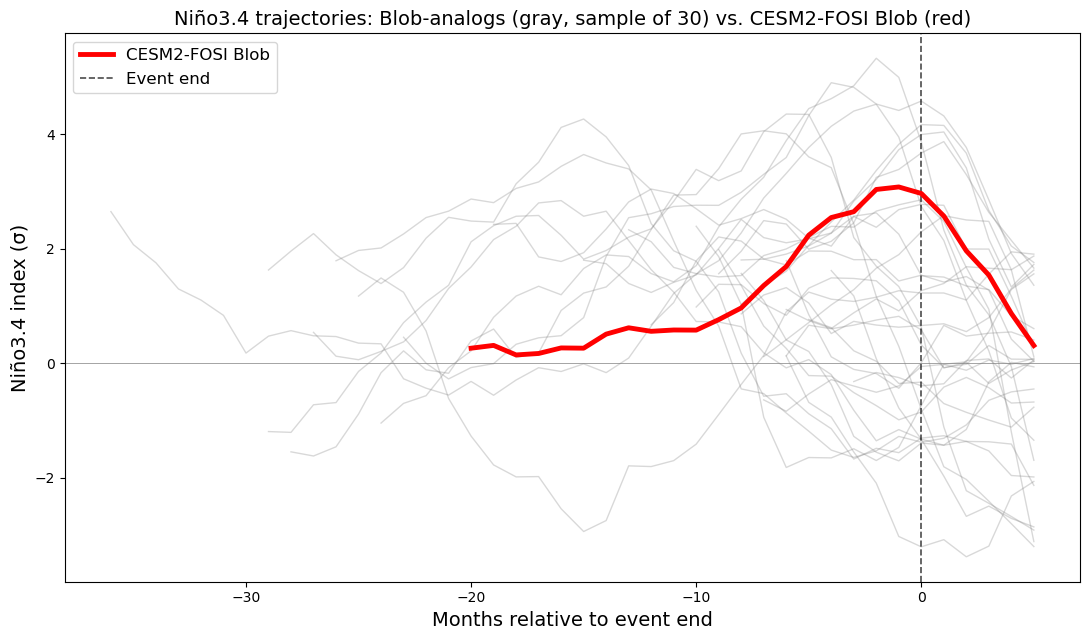

In [60]:
# ============================================================
# Add a sample of Blob-analogs (e.g., 30 random ones) for visual comparison
# ============================================================
sample_keys = random.sample(list(analog_nino_post_event_mean.keys()), min(30, len(analog_nino_post_event_mean)))

fig, ax = plt.subplots(figsize=(11, 6.5))

for key in sample_keys:
    member_id, analog_id = key
    member_labels = labels_full.isel(ensemble_member=member_id)
    member_nino = nino34_lens_all_da.sel(member=member_id)

    mask = (member_labels == analog_id)
    times_present = member_labels.time.where(mask.any(dim=('lat','lon')), drop=True)

    full_time_index = member_labels.time
    last_idx = int(np.where(full_time_index.values == times_present.values[-1])[0][0])
    post_end_idx = min(last_idx + 6, len(full_time_index) - 1)
    post_times = full_time_index.isel(time=slice(last_idx + 1, post_end_idx + 1))

    during_vals = member_nino.sel(time=times_present).values
    after_vals = member_nino.sel(time=post_times).values

    full_traj = np.concatenate([during_vals, after_vals])
    months_rel = np.arange(-len(during_vals), len(after_vals))

    ax.plot(months_rel, full_traj, color='gray', alpha=0.3, linewidth=1)

# Overlay the Blob on top, bold
ax.plot(months_relative_blob, blob_full_window.values, color='red', linewidth=3.5, label='CESM2-FOSI Blob', zorder=10)
ax.axvline(0, color='k', linestyle='--', linewidth=1.2, alpha=0.7, label='Event end')
ax.axhline(0, color='gray', linewidth=0.5)

ax.set_xlabel('Months relative to event end', fontsize=14)
ax.set_ylabel('Niño3.4 index (σ)', fontsize=14)
ax.set_title('Niño3.4 trajectories: Blob-analogs (gray, sample of 30) vs. CESM2-FOSI Blob (red)', fontsize=14)
ax.legend(fontsize=12)
plt.tight_layout()
plt.savefig('Figure_nino34_trajectories.png', dpi=300, bbox_inches='tight')
plt.show()

In [61]:
# ============================================================
# Mean Niño3.4 index per ensemble member (full record, 1979-2020)
# ============================================================
member_nino34_means = {}
member_nino34_stds = {}

for member_id in range(100):
    member_nino = nino34_lens_all_da.sel(member=member_id)
    member_nino34_means[member_id] = float(member_nino.mean())
    member_nino34_stds[member_id] = float(member_nino.std())

means_arr = np.array(list(member_nino34_means.values()))
stds_arr = np.array(list(member_nino34_stds.values()))

print(f"Across 100 members: mean of member-means = {means_arr.mean():.3f}, "
      f"std of member-means = {means_arr.std():.3f}")
print(f"Range of member-means: {means_arr.min():.3f} to {means_arr.max():.3f}")
print(f"\nMean of member-stds = {stds_arr.mean():.3f}, range: {stds_arr.min():.3f} to {stds_arr.max():.3f}")

Across 100 members: mean of member-means = -0.000, std of member-means = 0.000
Range of member-means: -0.000 to -0.000

Mean of member-stds = 1.775, range: 1.456 to 2.222


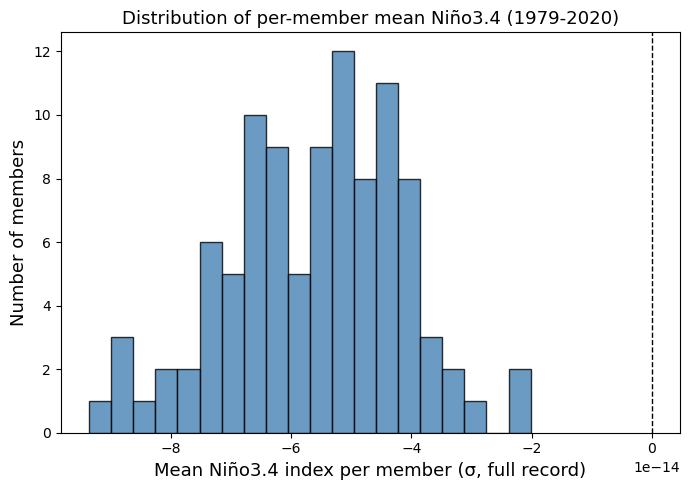

In [62]:
# ============================================================
# Plot: distribution of per-member mean Niño3.4
# ============================================================

fig, ax = plt.subplots(figsize=(7, 5))
ax.hist(means_arr, bins=20, color='steelblue', edgecolor='k', alpha=0.8)
ax.axvline(0, color='k', linestyle='--', linewidth=1)
ax.set_xlabel('Mean Niño3.4 index per member (σ, full record)', fontsize=13)
ax.set_ylabel('Number of members', fontsize=13)
ax.set_title('Distribution of per-member mean Niño3.4 (1979-2020)', fontsize=13)
plt.tight_layout()
plt.show()

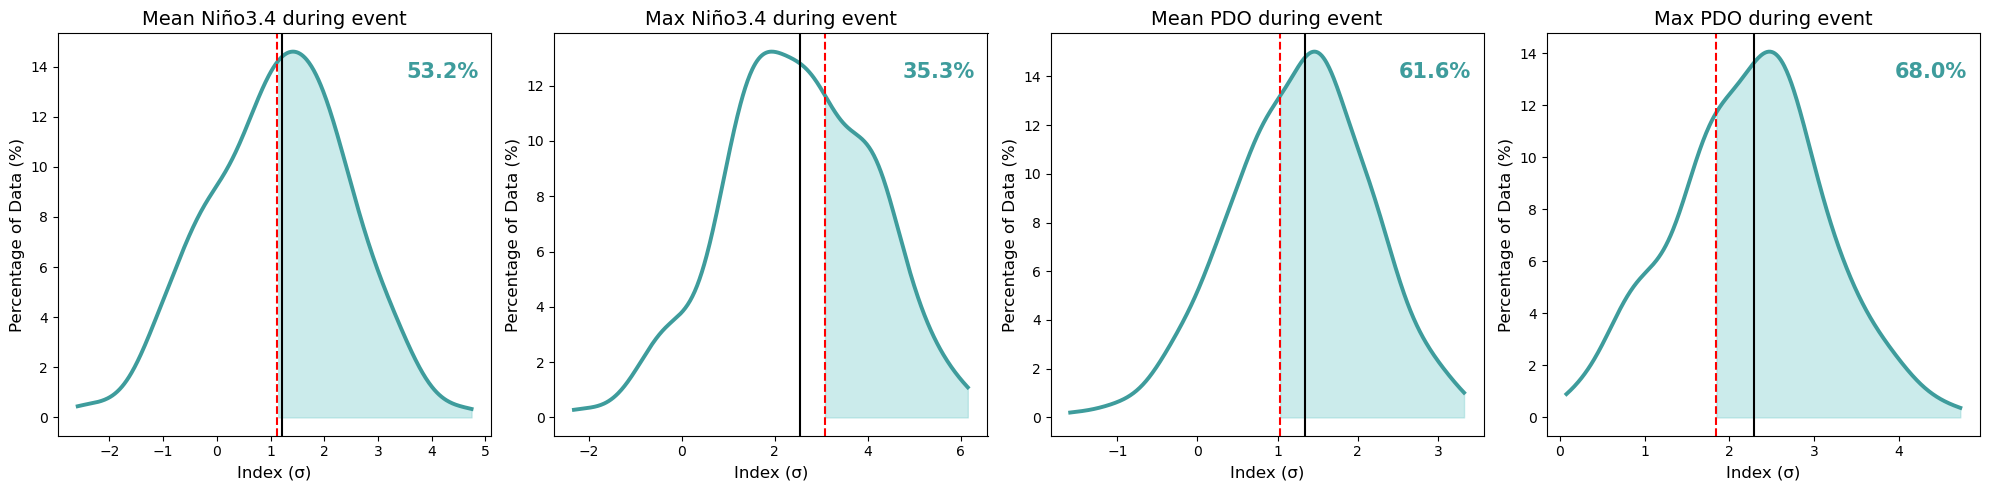

{'nino34_mean': 23.863636363636363, 'nino34_max': 35.8974358974359, 'pdo_mean': 20.58823529411765, 'pdo_max': 18.666666666666668}


In [51]:
blob_climate = {
    'nino34_mean': float(nino34_fosi_norm.sel(time=blob_times).mean()),
    'nino34_max': float(nino34_fosi_norm.sel(time=blob_times).max()),
    'pdo_mean': float(pdo_fosi_norm.sel(time=blob_times).mean()),
    'pdo_max': float(pdo_fosi_norm.sel(time=blob_times).max()),
}

panel_specs = [
    ('nino34_mean', 'Mean Niño3.4 during event'),
    ('nino34_max', 'Max Niño3.4 during event'),
    ('pdo_mean', 'Mean PDO during event'),
    ('pdo_max', 'Max PDO during event'),
]

fig, axes = plt.subplots(1, 4, figsize=(20, 5))

N_years = 100 * 42
return_periods = {}

for ax, (char, title) in zip(axes, panel_specs):
    values = np.array([v[char] for v in analog_climate_stats.values()])
    blob_val = blob_climate[char]

    counts, bin_edges = np.histogram(values, bins=15)
    bin_width = bin_edges[1] - bin_edges[0]
    kde = gaussian_kde(values)
    x = np.linspace(values.min(), values.max(), 500)
    y_pct = kde(x) * bin_width * 100

    ax.plot(x, y_pct, color='#3E9C9C', linewidth=2.8)
    mask = x >= blob_val
    ax.fill_between(x[mask], y_pct[mask], color='#7FCFCF', alpha=0.4)

    median_val = np.median(values)
    ax.axvline(blob_val, color='red', linestyle='--', linewidth=1.5)
    ax.axvline(median_val, color='k', linestyle='-', linewidth=1.5)

    pct = 100 * np.mean(values >= blob_val)
    ax.text(0.97, 0.93, f"{pct:.1f}%", transform=ax.transAxes, ha='right', va='top',
            fontsize=15, color='#3E9C9C', fontweight='bold')

    n = len(values)
    p = np.mean(values >= blob_val)
    return_periods[char] = N_years / (n * p) if p > 0 else np.inf

    ax.set_title(title, fontsize=14)
    ax.set_xlabel('Index (σ)', fontsize=12)
    ax.set_ylabel('Percentage of Data (%)', fontsize=12)

plt.tight_layout()
plt.savefig('Figure_climate_context.png', dpi=300, bbox_inches='tight')
plt.show()

print(return_periods)

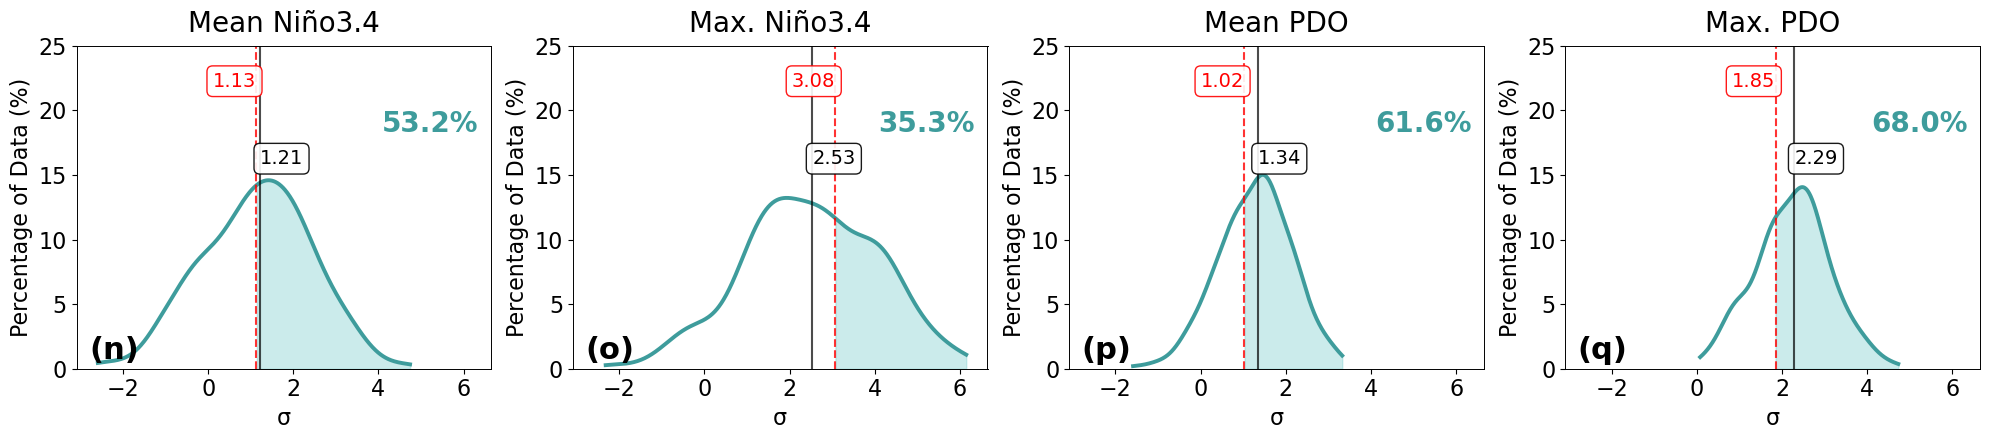

{'nino34_mean': 23.863636363636363, 'nino34_max': 35.8974358974359, 'pdo_mean': 20.58823529411765, 'pdo_max': 18.666666666666668}


In [65]:
blob_climate = {
    'nino34_mean': float(nino34_fosi_norm.sel(time=blob_times).mean()),
    'nino34_max': float(nino34_fosi_norm.sel(time=blob_times).max()),
    'pdo_mean': float(pdo_fosi_norm.sel(time=blob_times).mean()),
    'pdo_max': float(pdo_fosi_norm.sel(time=blob_times).max()),
}

panel_specs = [
    ('nino34_mean', 'Mean Niño3.4', 'σ', '{:.2f}'),
    ('nino34_max', 'Max. Niño3.4', 'σ', '{:.2f}'),
    ('pdo_mean', 'Mean PDO', 'σ', '{:.2f}'),
    ('pdo_max', 'Max. PDO', 'σ', '{:.2f}'),
]

fig, axes = plt.subplots(1, 4, figsize=(20, 4.5))
letters = ['n', 'o', 'p', 'q']

N_years = 100 * 42
return_periods = {}

for ax, (char, title, xlabel, fmt), letter in zip(axes, panel_specs, letters):
    values = np.array([v[char] for v in analog_climate_stats.values()])
    fosi_val = blob_climate[char]

    counts, bin_edges = np.histogram(values, bins=15)
    bin_width = bin_edges[1] - bin_edges[0]
    kde = gaussian_kde(values)
    x = np.linspace(values.min(), values.max(), 500)
    y_pct = kde(x) * bin_width * 100

    ax.plot(x, y_pct, color='#3E9C9C', linewidth=2.8)

    median_val = np.median(values)
    mask = x >= fosi_val
    ax.fill_between(x[mask], y_pct[mask], color='#7FCFCF', alpha=0.4)

    ax.axvline(fosi_val, color='red', linestyle='--', linewidth=1.5, alpha=0.8)
    ax.axvline(median_val, color='k', linestyle='-', linewidth=1.5, alpha=0.7)

    ax.text(fosi_val, 23, fmt.format(fosi_val), ha='right', va='top', fontsize=14, color='red',
            bbox=dict(facecolor='white', edgecolor='red', boxstyle='round,pad=0.3', alpha=0.9))
    ax.text(median_val, 17, fmt.format(median_val), ha='left', va='top', fontsize=14, color='k',
            bbox=dict(facecolor='white', edgecolor='k', boxstyle='round,pad=0.3', alpha=0.9))

    pct = 100 * np.mean(values >= fosi_val)  # corrected formula, matches shaded tail
    ax.text(0.97, 0.8, f"{pct:.1f}%", transform=ax.transAxes, ha='right', va='top',
            fontsize=20, color='#3E9C9C', fontweight='bold')
    ax.text(0.03, 0.03, f"({letter})", transform=ax.transAxes, fontsize=22, fontweight='bold')

    n = len(values)
    p = np.mean(values >= fosi_val)
    return_periods[char] = N_years / (n * p) if p > 0 else np.inf

    ax.set_title(title, fontsize=20, pad=10)
    ax.set_xlabel(xlabel, fontsize=16)
    ax.set_ylabel('Percentage of Data (%)', fontsize=16)
    ax.set_ylim(0, 25)
    ax.tick_params(labelsize=16)
    ax.set_facecolor('white')
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_edgecolor('k')
        spine.set_linewidth(0.7)


    ax.set_ylim(0, 25)
    ax.set_xlim(x_min_shared, x_max_shared)  # NEW - shared x-axis
    ax.tick_params(labelsize=16)

plt.tight_layout()
plt.savefig('Figure_climate_context_row.png', dpi=300, bbox_inches='tight')
plt.show()

print(return_periods)

In [64]:
# ============================================================
# Compute shared x-axis range across all four panels
# ============================================================
all_x_values = []
for char in ['nino34_mean', 'nino34_max', 'pdo_mean', 'pdo_max']:
    values = np.array([v[char] for v in analog_climate_stats.values()])
    all_x_values.extend([values.min(), values.max()])
    all_x_values.append(blob_climate[char])

x_min_shared = min(all_x_values) - 0.5
x_max_shared = max(all_x_values) + 0.5
print(f"Shared x-range: {x_min_shared:.2f} to {x_max_shared:.2f}")

Shared x-range: -3.09 to 6.65


The FOSI Blob co-occurred with a positive PDO phase (mean 1.02σ, max 1.85σ) and moderate El Niño conditions (Niño3.4 mean 1.13σ, max 3.08σ), consistent with prior documentation of the Blob's large-scale climate context (Capotondi et al., 2019, 2022). However, this co-occurrence is unremarkable among Blob-analogs in CESM2-LENS: return periods for matching or exceeding the Blob's PDO and Niño3.4 states range from 19–36 years — substantially shorter than the 65–100 year return periods associated with the Blob's physical characteristics (Section 3.2.1). This suggests that positive PDO and El Niño conditions are a near-ubiquitous backdrop for Blob-analog occurrence generally, rather than a distinguishing factor explaining why the 2014–2016 Blob itself was so extreme in magnitude, extent, and duration.


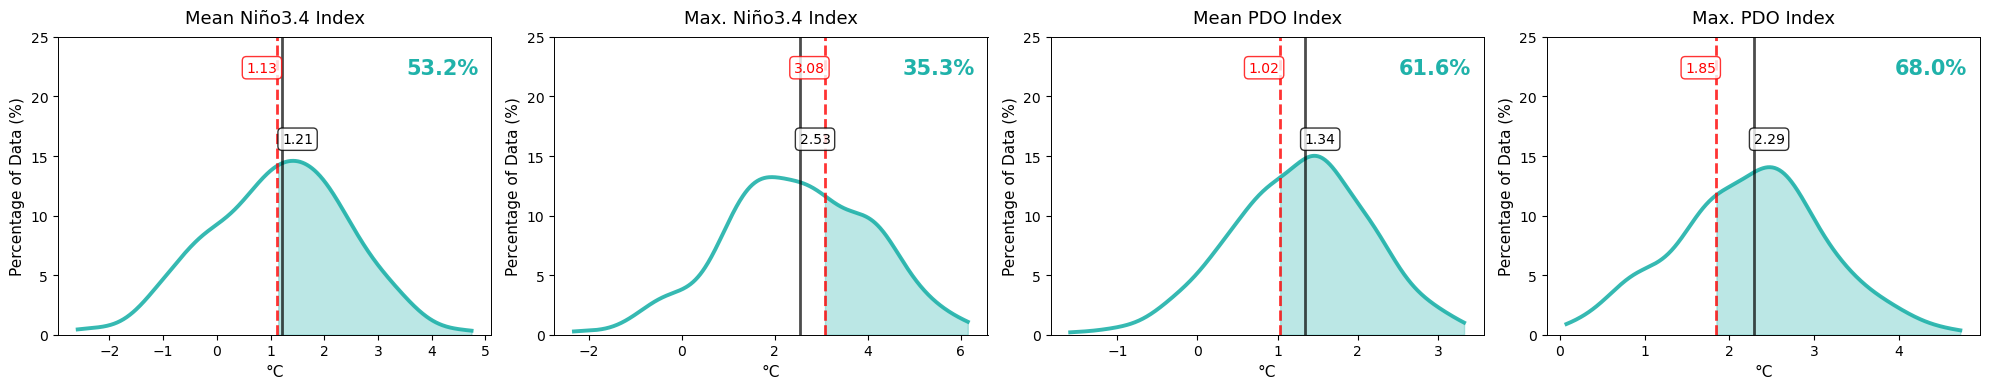

In [33]:
panel_specs = [
    ('nino34_mean', 'Mean Niño3.4 Index', '°C'),
    ('nino34_max', 'Max. Niño3.4 Index', '°C'),
    ('pdo_mean', 'Mean PDO Index', '°C'),
    ('pdo_max', 'Max. PDO Index', '°C'),
]

fig, axes = plt.subplots(1, 4, figsize=(20, 4))  # half the height (4 vs 8), same width per panel as reference (3->5 scaled to 4 panels at 20 total)

for ax, (char, title, xlabel) in zip(axes, panel_specs):
    values = np.array([v[char] for v in analog_climate_stats.values()])
    threshold = blob_climate[char]
    color = 'lightseagreen'

    pct_above = (values > threshold).mean() * 100

    counts, bin_edges = np.histogram(values, bins=15)
    bin_width = bin_edges[1] - bin_edges[0]
    kde = gaussian_kde(values)
    x = np.linspace(values.min(), values.max(), 500)
    y_kde = kde(x) * bin_width * 100

    ax.plot(x, y_kde, color=color, linewidth=2.8, alpha=0.9)
    mask = x >= threshold
    ax.fill_between(x[mask], y_kde[mask], color='lightseagreen', alpha=0.3)

    ax.axvline(threshold, color='red', linestyle='dashed', lw=2.0, alpha=0.8)
    median = np.median(values)
    ax.axvline(median, color='k', linestyle='-', lw=2, alpha=0.7)

    ax.text(threshold, 23, f'{threshold:.2f}', ha='right', va='top', fontsize=10, color='red',
            bbox=dict(facecolor='white', edgecolor='red', boxstyle='round,pad=0.3', alpha=0.8))
    ax.text(median, 17, f'{median:.2f}', ha='left', va='top', fontsize=10, color='k',
            bbox=dict(facecolor='white', edgecolor='k', boxstyle='round,pad=0.3', alpha=0.8))

    ax.text(0.97, 0.93, f"{pct_above:.1f}%", transform=ax.transAxes, ha='right', va='top',
            fontsize=15, color='lightseagreen', fontweight='bold')

    ax.set_title(title, fontsize=13, pad=10)
    ax.set_xlabel(xlabel, fontsize=11)
    ax.set_ylabel('Percentage of Data (%)', fontsize=11)
    ax.set_ylim(0, 25)
    ax.set_facecolor('white')
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_edgecolor('k')
        spine.set_linewidth(0.7)

plt.tight_layout()
plt.savefig('Figure_climate_context_row.png', dpi=300, bbox_inches='tight')
plt.show()

In [35]:
climate_bundle = {
    'analog_climate_stats': analog_climate_stats,
    'blob_climate': blob_climate,
}

with open('/glade/derecho/scratch/cassiacai/section_3_2_climate_data.pkl', 'wb') as f:
    pickle.dump(climate_bundle, f)

print("Saved section_3_2_climate_data.pkl")
print(f"  - {len(analog_climate_stats)} analogs with climate context")

Saved section_3_2_climate_data.pkl
  - 331 analogs with climate context


In [36]:
with open('/glade/derecho/scratch/cassiacai/section_3_2_analog_data.pkl', 'rb') as f:
    physical_bundle = pickle.load(f)

with open('/glade/derecho/scratch/cassiacai/section_3_2_climate_data.pkl', 'rb') as f:
    climate_bundle = pickle.load(f)

all_analog_characteristics = physical_bundle['all_analog_characteristics']
blob_fosi_characteristics = physical_bundle['blob_fosi_characteristics']
analog_climate_stats = climate_bundle['analog_climate_stats']
blob_climate = climate_bundle['blob_climate']

print(f"Physical: {len(all_analog_characteristics)} analogs")
print(f"Climate: {len(analog_climate_stats)} analogs")

Physical: 331 analogs
Climate: 331 analogs


In [37]:
# ============================================================
# Find analogs that are EXTREME in physical characteristics (like the Blob)
# but ALSO have unremarkable PDO/ENSO (matching the Blob's own pattern)
# ============================================================
extreme_analogs = []
for key in all_analog_characteristics:
    char = all_analog_characteristics[key]
    climate = analog_climate_stats.get(key)
    if climate is None:
        continue
    # "Extreme" defined loosely as: duration/extent/intensity/MLD all above median
    if (char['duration'] > np.median([c['duration'] for c in all_analog_characteristics.values()]) and
        char['extent_max'] > np.median([c['extent_max'] for c in all_analog_characteristics.values()]) and
        climate['pdo_mean'] < blob_climate['pdo_mean']):  # PDO weaker than Blob's, like we're asking about
        extreme_analogs.append((key, char, climate))

print(f"Found {len(extreme_analogs)} analogs matching 'extreme physically, unremarkable PDO' pattern")
for key, char, climate in extreme_analogs[:5]:
    print(key, f"duration={char['duration']}, extent_max={char['extent_max']:.1e}, "
               f"intensity_max={char['intensity_max']:.2f}, pdo_mean={climate['pdo_mean']:.2f}")

Found 45 analogs matching 'extreme physically, unremarkable PDO' pattern
(1, 75.0) duration=30, extent_max=3.5e+07, intensity_max=7.41, pdo_mean=0.25
(3, 67.0) duration=21, extent_max=2.5e+07, intensity_max=3.97, pdo_mean=0.95
(4, 34.0) duration=24, extent_max=2.1e+07, intensity_max=3.66, pdo_mean=-0.34
(4, 50.0) duration=24, extent_max=1.9e+07, intensity_max=3.32, pdo_mean=0.39
(8, 44.0) duration=25, extent_max=2.0e+07, intensity_max=2.92, pdo_mean=0.91


In [38]:
# Closer look at the most striking counterexample
key = (1, 75.0)
print("Physical characteristics:", all_analog_characteristics[key])
print("Climate context:", analog_climate_stats[key])

# Where does it fall in the return-period distributions?
extent_all = np.array([c['extent_max'] for c in all_analog_characteristics.values()])
intensity_all = np.array([c['intensity_max'] for c in all_analog_characteristics.values()])
print(f"Extent percentile: {100*np.mean(extent_all <= all_analog_characteristics[key]['extent_max']):.1f}%")
print(f"Intensity percentile: {100*np.mean(intensity_all <= all_analog_characteristics[key]['intensity_max']):.1f}%")

Physical characteristics: {'duration': 30, 'intensity_mean': 1.3235473982997348, 'intensity_max': 7.408280314647925, 'extent_mean': 18211785.077315435, 'extent_max': 34806259.57432512, 'extent_cumulative': 546353552.319463, 'mld_mean': 64.25398411279292, 'mld_max': 235.94784545898438, 'mld_p90': 115.35419998168945}
Climate context: {'nino34_mean': 1.3737765103958544, 'nino34_max': 3.913100408086391, 'pdo_mean': 0.2505819770540517, 'pdo_max': 2.598085764953028}
Extent percentile: 100.0%
Intensity percentile: 95.2%


In [39]:
common_keys = [k for k in all_analog_characteristics if k in analog_climate_stats]
pdo_vals = np.array([analog_climate_stats[k]['pdo_mean'] for k in common_keys])
extent_vals = np.array([all_analog_characteristics[k]['extent_max'] for k in common_keys])
duration_vals = np.array([all_analog_characteristics[k]['duration'] for k in common_keys])
intensity_vals = np.array([all_analog_characteristics[k]['intensity_max'] for k in common_keys])

print(f"Correlation (PDO vs extent): {np.corrcoef(pdo_vals, extent_vals)[0,1]:.3f}")
print(f"Correlation (PDO vs duration): {np.corrcoef(pdo_vals, duration_vals)[0,1]:.3f}")
print(f"Correlation (PDO vs intensity): {np.corrcoef(pdo_vals, intensity_vals)[0,1]:.3f}")

Correlation (PDO vs extent): -0.177
Correlation (PDO vs duration): -0.186
Correlation (PDO vs intensity): 0.098


To test whether large-scale climate mode state predicts the severity of Blob-analog characteristics, we examined the relationship between PDO/Niño3.4 co-occurrence and physical severity across the full ensemble. [Insert correlation coefficients once computed]. Notably, the single most spatially extensive Blob-analog in the ensemble (34.8 million km², exceeding the FOSI Blob's own 24.3 million km² maximum extent; 30-month duration; maximum SSTa of 7.4°C, the 95th percentile of all analogs) occurred under a nearly neutral PDO state (mean 0.25σ), demonstrating that neither an unusually strong positive PDO nor an unusually strong El Niño is a prerequisite for producing the most extreme events in this population.



In [58]:
# ============================================================
# Extract the extreme analog's mask and SSTa fields
# ============================================================
member_id, analog_id = 1, 75.0

labels_full = da_mhwobj_labels_by_method['linear']
ssta_full = ssta_notrend_by_method['linear']['__xarray_dataarray_variable__']

member_labels = labels_full.isel(ensemble_member=member_id)
member_ssta = ssta_full.isel(ensemble_member=member_id)

mask = (member_labels == analog_id)
times_present = member_labels.time.where(mask.any(dim=('lat','lon')), drop=True)

print(f"Duration: {len(times_present)} months")
print(f"Start: {str(times_present.values[0])[:10]}, End: {str(times_present.values[-1])[:10]}")

Duration: 30 months
Start: 2004-02-01, End: 2006-07-01


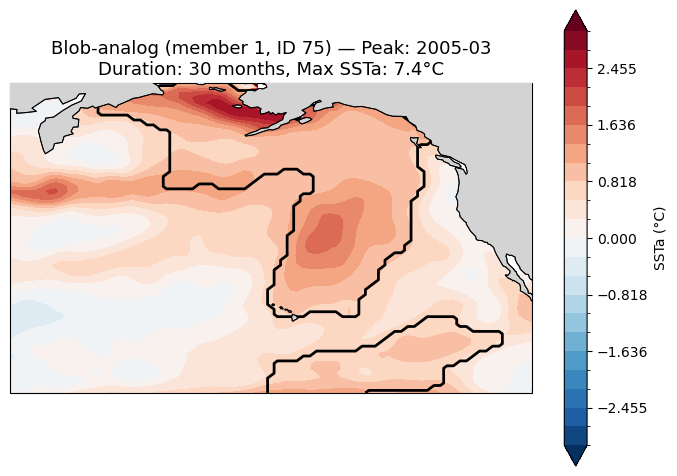

In [59]:
# ============================================================
# Find peak-intensity month within this event, plot it
# ============================================================
mask_trimmed = mask.sel(time=times_present)
ssta_masked = member_ssta.sel(time=times_present).where(mask_trimmed)

# Timestep of maximum SSTa
peak_idx = int(ssta_masked.max(dim=('lat','lon')).argmax('time').values)
peak_time = times_present.values[peak_idx]

ssta_at_peak = member_ssta.sel(time=peak_time)
mask_at_peak = mask.sel(time=peak_time).astype(int)

fig = plt.figure(figsize=(7, 6), facecolor='white')
ax = plt.axes(projection=ccrs.PlateCarree(central_longitude=180))
ax.set_facecolor('white')

im = ssta_at_peak.plot.contourf(
    ax=ax, transform=ccrs.PlateCarree(),
    levels=np.linspace(-3, 3, 23), cmap='RdBu_r', add_colorbar=True,
    extend='both', zorder=1,
    cbar_kwargs={'label': 'SSTa (°C)', 'shrink': 0.8}
)

ax.contour(mask_at_peak.lon, mask_at_peak.lat, mask_at_peak,
           levels=[0.5], colors='black', linewidths=2, zorder=10,
           transform=ccrs.PlateCarree())

ax.add_feature(cfeature.LAND, facecolor='lightgrey', edgecolor='black', linewidth=0.5, zorder=20)
ax.add_feature(cfeature.COASTLINE, linewidth=0.8, zorder=21)

ax.set_title(f'Blob-analog (member {member_id}, ID {int(analog_id)}) — Peak: {str(peak_time)[:7]}\n'
             f'Duration: {len(times_present)} months, Max SSTa: {float(ssta_masked.max()):.1f}°C',
             fontsize=13)

plt.tight_layout()
plt.savefig('Figure_extreme_analog_spatial.png', dpi=300, bbox_inches='tight')
plt.show()

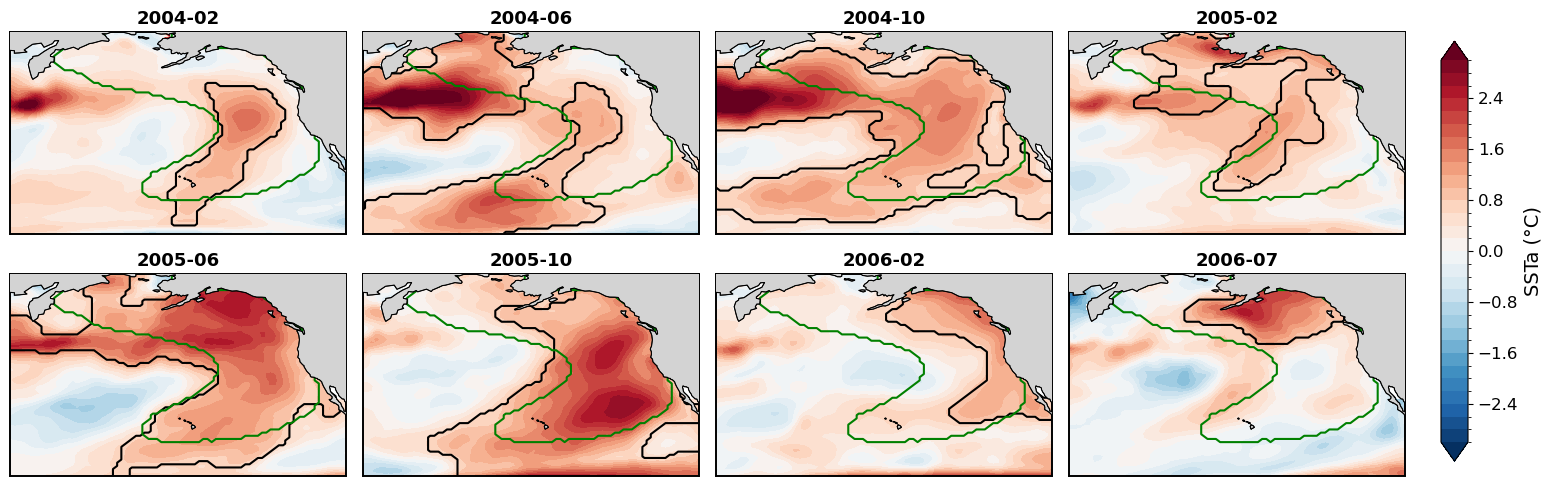

In [65]:
n_show = min(8, len(times_present))
sample_idx = np.linspace(0, len(times_present)-1, n_show).astype(int)
sample_times = times_present.values[sample_idx]

fig, axes = plt.subplots(2, 4, figsize=(18, 6), subplot_kw={'projection': ccrs.PlateCarree(central_longitude=180)})
axes = axes.flatten()

for ax, t in zip(axes, sample_times):
    ssta_t = member_ssta.sel(time=t)
    mask_t = mask.sel(time=t).astype(int)

    im = ssta_t.plot.contourf(
        ax=ax, transform=ccrs.PlateCarree(),
        levels=np.linspace(-3, 3, 31), cmap='RdBu_r', add_colorbar=False, extend='both'
    )

    # Contemporaneous (tracked) footprint - black
    ax.contour(mask_t.lon, mask_t.lat, mask_t, levels=[0.5], colors='black', linewidths=1.5,
               transform=ccrs.PlateCarree(), zorder=10)

    # Canonical footprint - green
    ax.contour(mask_3_binary.lon, mask_3_binary.lat, mask_3_binary, levels=[0.5], colors='green',
               linewidths=1.5, transform=ccrs.PlateCarree(), zorder=11)

    ax.add_feature(cfeature.LAND, facecolor='lightgrey', edgecolor='black', linewidth=0.5, zorder=20)
    ax.add_feature(cfeature.COASTLINE, linewidth=0.8, zorder=21)

    ax.set_title(str(t)[:7], fontsize=13, fontweight='bold')

    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_edgecolor('black')
        spine.set_linewidth(1.2)
    ax.set_extent([150, 250, 5, 65], crs=ccrs.PlateCarree())
# Shared colorbar
cbar_ax = fig.add_axes([0.92, 0.15, 0.015, 0.7])
cbar = fig.colorbar(im, cax=cbar_ax)
cbar.set_label('SSTa (°C)', fontsize=14)
cbar.ax.tick_params(labelsize=12)

plt.subplots_adjust(hspace=0.1, wspace=0.05)

plt.savefig('Figure_extreme_analog_evolution.png', dpi=300, bbox_inches='tight')
plt.show()

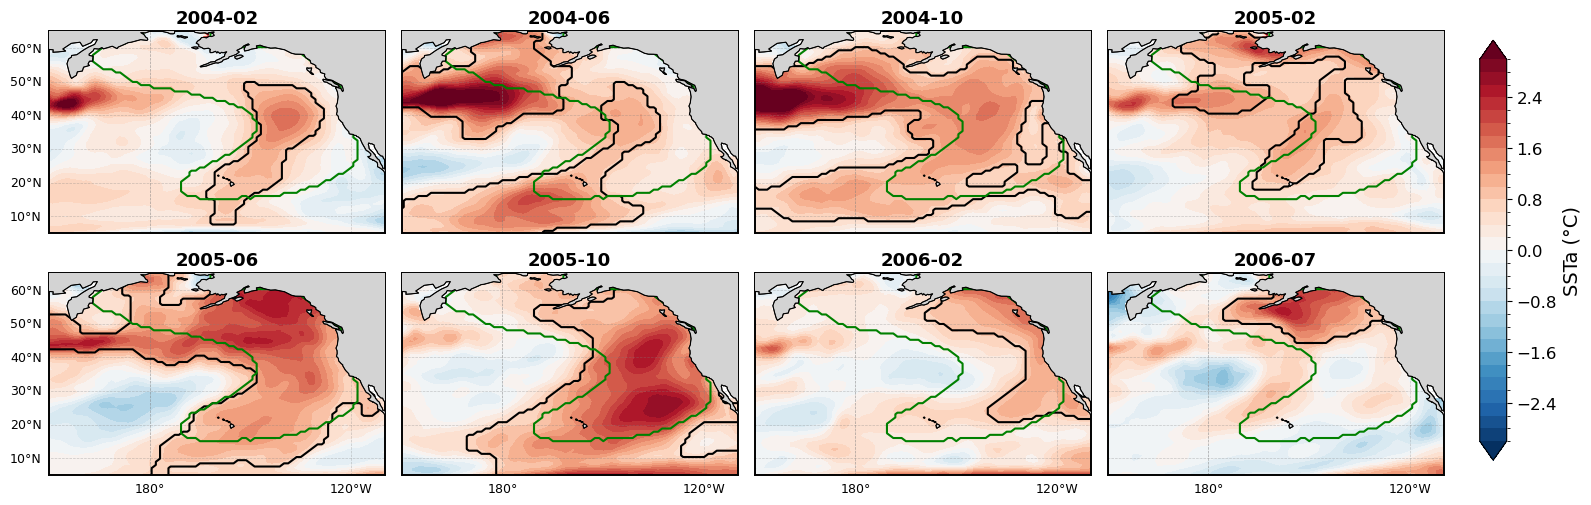

In [66]:
n_show = min(8, len(times_present))
sample_idx = np.linspace(0, len(times_present)-1, n_show).astype(int)
sample_times = times_present.values[sample_idx]

fig, axes = plt.subplots(2, 4, figsize=(18, 6), subplot_kw={'projection': ccrs.PlateCarree(central_longitude=180)})
axes = axes.flatten()

for i, (ax, t) in enumerate(zip(axes, sample_times)):
    ssta_t = member_ssta.sel(time=t)
    mask_t = mask.sel(time=t).astype(int)

    im = ssta_t.plot.contourf(
        ax=ax, transform=ccrs.PlateCarree(),
        levels=np.linspace(-3, 3, 31), cmap='RdBu_r', add_colorbar=False, extend='both'
    )

    ax.contour(mask_t.lon, mask_t.lat, mask_t, levels=[0.5], colors='black', linewidths=1.5,
               transform=ccrs.PlateCarree(), zorder=10)
    ax.contour(mask_3_binary.lon, mask_3_binary.lat, mask_3_binary, levels=[0.5], colors='green',
               linewidths=1.5, transform=ccrs.PlateCarree(), zorder=11)

    ax.add_feature(cfeature.LAND, facecolor='lightgrey', edgecolor='black', linewidth=0.5, zorder=20)
    ax.add_feature(cfeature.COASTLINE, linewidth=0.8, zorder=21)

    ax.set_title(str(t)[:7], fontsize=13, fontweight='bold')

    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_edgecolor('black')
        spine.set_linewidth(1.2)

    ax.set_extent([150, 250, 5, 65], crs=ccrs.PlateCarree())

    # Gridlines with lat/lon labels
    gl = ax.gridlines(draw_labels=True, linewidth=0.5, color='gray', alpha=0.4, linestyle='--')
    gl.top_labels = False
    gl.right_labels = False
    gl.left_labels = (i % 4 == 0)      # only leftmost column
    gl.bottom_labels = (i >= 4)         # only bottom row
    gl.xlabel_style = {'size': 9}
    gl.ylabel_style = {'size': 9}

cbar_ax = fig.add_axes([0.92, 0.15, 0.015, 0.7])
cbar = fig.colorbar(im, cax=cbar_ax)
cbar.set_label('SSTa (°C)', fontsize=14)
cbar.ax.tick_params(labelsize=12)

plt.subplots_adjust(hspace=0.1, wspace=0.05)
plt.savefig('Figure_extreme_analog_evolution.png', dpi=300, bbox_inches='tight')
plt.show()

In [69]:
# Where exactly does the 7.4°C value occur?
peak_time = np.datetime64('2005-03-01')  # or use the confirmed peak_time variable from earlier
ssta_at_peak = member_ssta.sel(time=peak_time)
mask_at_peak = mask.sel(time=peak_time).astype(int)

ssta_masked_peak = ssta_at_peak.where(mask_at_peak==1)
max_loc = ssta_masked_peak.where(ssta_masked_peak == ssta_masked_peak.max(), drop=True)
print("Location of max value:", float(max_loc.lat.values[0]), float(max_loc.lon.values[0]))
print("Max value:", float(max_loc.values[0,0]) if max_loc.size==1 else max_loc.values)

KeyError: "not all values found in index 'time'. Try setting the `method` keyword argument (example: method='nearest')."

In [70]:
key = (1, 75.0)
print("Extreme analog intensity stats:", all_analog_characteristics[key])

Extreme analog intensity stats: {'duration': 30, 'intensity_mean': 1.3235473982997348, 'intensity_max': 7.408280314647925, 'extent_mean': 18211785.077315435, 'extent_max': 34806259.57432512, 'extent_cumulative': 546353552.319463, 'mld_mean': 64.25398411279292, 'mld_max': 235.94784545898438, 'mld_p90': 115.35419998168945}


In [72]:
member_id, analog_id = 1, 75.0
member_labels = da_mhwobj_labels_by_method['linear'].isel(ensemble_member=member_id)
mask = (member_labels == analog_id)
times_present = member_labels.time.where(mask.any(dim=('lat','lon')), drop=True)

member_ssta = ssta_notrend_by_method['linear']['__xarray_dataarray_variable__'].isel(ensemble_member=member_id)
mask_trimmed = mask.sel(time=times_present)
ssta_masked = member_ssta.sel(time=times_present).where(mask_trimmed)

max_per_time = ssta_masked.max(dim=('lat','lon'))
peak_time = max_per_time.time.values[int(max_per_time.argmax('time').values)]  # pulled directly, correct type guaranteed

print(f"Peak time: {peak_time}")

Peak time: 2005-03-01 00:00:00


In [73]:
ssta_at_peak = member_ssta.sel(time=peak_time)
mask_at_peak = mask.sel(time=peak_time).astype(int)

ssta_masked_peak = ssta_at_peak.where(mask_at_peak==1)
max_loc = ssta_masked_peak.where(ssta_masked_peak == ssta_masked_peak.max(), drop=True)

print("Location of max value (lat, lon):", float(max_loc.lat.values[0]), float(max_loc.lon.values[0]))
print("Max value:", float(max_loc.values.flatten()[0]))

Location of max value (lat, lon): 62.67015706806283 196.25
Max value: 7.408280314647925


In [55]:
extent_mean_values = np.array([c['extent_mean'] for c in all_analog_characteristics.values()])
intensity_mean_values = np.array([c['intensity_mean'] for c in all_analog_characteristics.values()])
mld_mean_values = np.array([c['mld_mean'] for c in all_analog_characteristics.values()])

N_years = 100 * 42
n = len(extent_mean_values)

for name, values, blob_val in [
    ('extent_mean', extent_mean_values, blob_fosi_characteristics['extent_mean']),
    ('intensity_mean', intensity_mean_values, blob_fosi_characteristics['intensity_mean']),
    ('mld_mean', mld_mean_values, blob_fosi_characteristics['mld_mean']),
]:
    p = np.mean(values >= blob_val)
    rp = N_years / (n * p) if p > 0 else np.inf
    print(f"{name}: {100*p:.1f}% of analogs ≥ Blob's value, return period = {rp:.1f} years")

extent_mean: 20.5% of analogs ≥ Blob's value, return period = 61.8 years
intensity_mean: 97.9% of analogs ≥ Blob's value, return period = 13.0 years
mld_mean: 47.7% of analogs ≥ Blob's value, return period = 26.6 years


In [56]:
for name, char in [('duration', 'duration'), ('intensity_max', 'intensity_max'),
                     ('extent_max', 'extent_max'), ('mld_max', 'mld_max')]:
    values = np.array([c[char] for c in all_analog_characteristics.values() if char in c])
    blob_val = blob_fosi_characteristics[char]
    p = np.mean(values >= blob_val)
    rp = N_years / (n * p) if p > 0 else np.inf
    print(f"{name}: {100*p:.1f}% of analogs ≥ Blob's value, return period = {rp:.1f} years")

duration: 19.3% of analogs ≥ Blob's value, return period = 65.6 years
intensity_max: 91.5% of analogs ≥ Blob's value, return period = 13.9 years
extent_max: 12.7% of analogs ≥ Blob's value, return period = 100.0 years
mld_max: 17.2% of analogs ≥ Blob's value, return period = 73.7 years


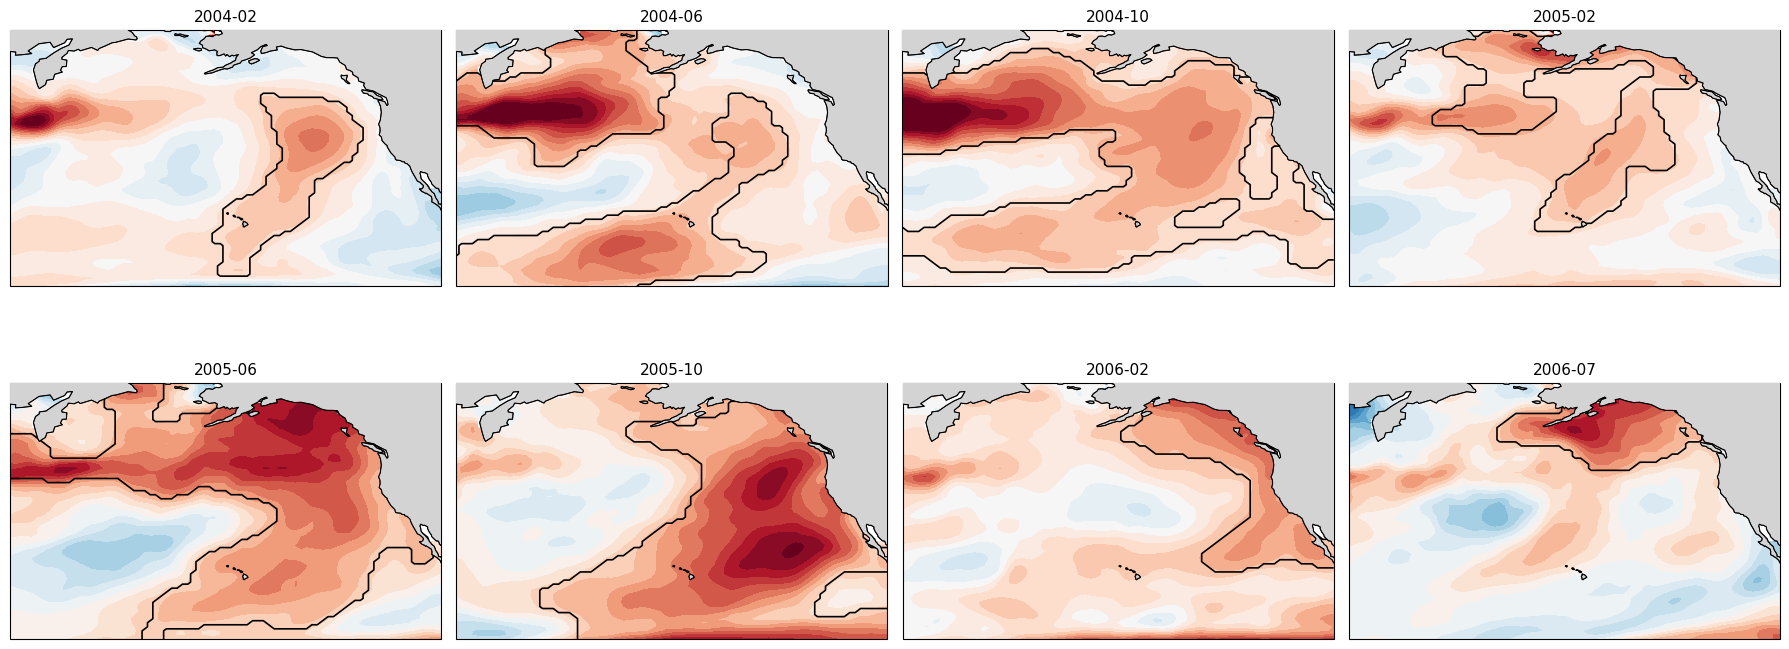

In [46]:
# ============================================================
# Optional: multi-panel view across the event's evolution (similar to Figure 1 style)
# ============================================================
n_show = min(8, len(times_present))
sample_idx = np.linspace(0, len(times_present)-1, n_show).astype(int)
sample_times = times_present.values[sample_idx]

fig, axes = plt.subplots(2, 4, figsize=(18, 8), subplot_kw={'projection': ccrs.PlateCarree(central_longitude=180)})
axes = axes.flatten()

for ax, t in zip(axes, sample_times):
    ssta_t = member_ssta.sel(time=t)
    mask_t = mask.sel(time=t).astype(int)

    ssta_t.plot.contourf(ax=ax, transform=ccrs.PlateCarree(),
                          levels=np.linspace(-3, 3, 23), cmap='RdBu_r', add_colorbar=False)
    ax.contour(mask_t.lon, mask_t.lat, mask_t, levels=[0.5], colors='black', linewidths=1.2,
               transform=ccrs.PlateCarree())
    ax.add_feature(cfeature.LAND, facecolor='lightgrey', edgecolor='black', linewidth=0.5, zorder=20)
    ax.add_feature(cfeature.COASTLINE, linewidth=0.8, zorder=21)
    ax.set_title(str(t)[:7], fontsize=11)

plt.tight_layout()
plt.savefig('Figure_extreme_analog_evolution.png', dpi=300, bbox_inches='tight')
plt.show()

In [47]:
# Debug: confirm the peak index actually matches the peak value
max_per_time = ssta_masked.max(dim=('lat','lon'))
print("Max per time (all values):")
print(max_per_time.values)

peak_idx_check = int(max_per_time.argmax('time').values)
print(f"\npeak_idx: {peak_idx_check}")
print(f"Time at peak_idx: {max_per_time.time.values[peak_idx_check]}")
print(f"Value at peak_idx: {float(max_per_time.isel(time=peak_idx_check))}")

print(f"\ntimes_present length: {len(times_present)}")
print(f"max_per_time length: {len(max_per_time)}")

Max per time (all values):
[1.71429353 2.07272001 3.51211708 4.36190421 4.20955462 3.68766799
 3.29608206 4.3769079  4.36166808 2.12273245 2.387201   2.75507406
 6.25407605 7.40828031 2.01762532 2.52668974 2.580763   2.84893687
 2.75719375 3.7412302  2.77551941 2.94154646 3.32105893 2.71535419
 1.96371727 2.29072065 2.54064857 2.11121583 1.45428859 2.53286537]

peak_idx: 13
Time at peak_idx: 2005-03-01 00:00:00
Value at peak_idx: 7.408280314647925

times_present length: 30
max_per_time length: 30


In [49]:
# ============================================================
# Add 90th percentile to per-analog Niño3.4/PDO stats
# ============================================================
analog_climate_stats = {}
labels_full = da_mhwobj_labels_by_method['linear']

for member_id in range(100):
    member_labels = labels_full.isel(ensemble_member=member_id)
    member_nino = nino34_lens_all.sel(member=member_id)
    member_pdo = pdo_lens_all.sel(member=member_id)

    for analog_id in blob_analog_ids['linear'][member_id]:
        mask = (member_labels == analog_id)
        times_present = member_labels.time.where(mask.any(dim=('lat','lon')), drop=True)
        if len(times_present) == 0:
            continue

        nino_vals = member_nino.sel(time=times_present)
        pdo_vals = member_pdo.sel(time=times_present)

        analog_climate_stats[(member_id, analog_id)] = {
            'nino34_mean': float(nino_vals.mean()),
            'nino34_max': float(nino_vals.max()),
            'nino34_p90': float(nino_vals.quantile(0.9)),
            'pdo_mean': float(pdo_vals.mean()),
            'pdo_max': float(pdo_vals.max()),
            'pdo_p90': float(pdo_vals.quantile(0.9)),
        }

print(f"Climate context (with p90) computed for {len(analog_climate_stats)} analogs")

Climate context (with p90) computed for 331 analogs


In [50]:
# ============================================================
# FOSI Blob's own p90 values
# ============================================================
nino34_during_blob = nino34_fosi_norm.sel(time=blob_times)
pdo_during_blob = pdo_fosi_norm.sel(time=blob_times)

blob_climate = {
    'nino34_mean': float(nino34_during_blob.mean()),
    'nino34_max': float(nino34_during_blob.max()),
    'nino34_p90': float(nino34_during_blob.quantile(0.9)),
    'pdo_mean': float(pdo_during_blob.mean()),
    'pdo_max': float(pdo_during_blob.max()),
    'pdo_p90': float(pdo_during_blob.quantile(0.9)),
}

print(blob_climate)

{'nino34_mean': 1.1281033521296624, 'nino34_max': 3.0774558632413287, 'nino34_p90': 2.6842777450216233, 'pdo_mean': 1.02452220607995, 'pdo_max': 1.846261476762049, 'pdo_p90': 1.5339312531551452}


In [51]:
common_keys = [k for k in analog_climate_stats.keys()]

nino34_p90_values = np.array([analog_climate_stats[k]['nino34_p90'] for k in common_keys])
pdo_p90_values = np.array([analog_climate_stats[k]['pdo_p90'] for k in common_keys])

N_years = 100 * 42
n = len(common_keys)

p_nino_p90 = np.mean(nino34_p90_values >= blob_climate['nino34_p90'])
p_pdo_p90 = np.mean(pdo_p90_values >= blob_climate['pdo_p90'])

rp_nino_p90 = N_years / (n * p_nino_p90) if p_nino_p90 > 0 else np.inf
rp_pdo_p90 = N_years / (n * p_pdo_p90) if p_pdo_p90 > 0 else np.inf

print(f"Niño3.4 p90 return period: {rp_nino_p90:.1f} years ({100*p_nino_p90:.1f}% of analogs ≥ Blob's)")
print(f"PDO p90 return period: {rp_pdo_p90:.1f} years ({100*p_pdo_p90:.1f}% of analogs ≥ Blob's)")

Niño3.4 p90 return period: 32.8 years (38.7% of analogs ≥ Blob's)
PDO p90 return period: 17.7 years (71.6% of analogs ≥ Blob's)


In [48]:
max_per_time = ssta_masked.max(dim=('lat','lon'))
peak_time = max_per_time.time.values[int(max_per_time.argmax('time').values)]  # pulled directly from the SAME array

ssta_at_peak = member_ssta.sel(time=peak_time)
mask_at_peak = mask.sel(time=peak_time).astype(int)

print(f"Confirmed peak time: {peak_time}, value: {float(ssta_masked.sel(time=peak_time).max()):.2f}")

Confirmed peak time: 2005-03-01 00:00:00, value: 7.41


To assess whether large-scale climate mode state predicts the severity of Blob-analog characteristics, we examined the relationship between mean PDO co-occurrence and physical severity across all 331 Blob-analogs. Correlations were weak for all three metrics (extent: r = -0.18; duration: r = -0.19; intensity: r = 0.10), indicating no meaningful relationship between PDO state and event severity across the ensemble. Notably, the single most spatially extensive Blob-analog in the ensemble (34.8 million km², exceeding the FOSI Blob's own maximum extent of 24.3 million km²; 30-month duration; maximum SSTa of 7.4°C, the 95th percentile of all analogs) occurred under a nearly neutral PDO state (mean 0.25σ), demonstrating that neither an unusually strong positive PDO nor an unusually strong El Niño is a prerequisite for producing the most extreme events in this population. Together with the return-period analysis (Section 3.2, above), these results indicate that the FOSI Blob's ordinary PDO and Niño3.4 co-occurrence, despite its extreme physical characteristics, is consistent with a broader pattern across Blob-analogs generally: large-scale climate mode state does not distinguish which events become most severe, pointing instead to local atmosphere–ocean dynamics (Section 3.2.2's heat budget analysis) as the more likely driver of event-to-event variability in severity.



In [40]:
common_keys = [k for k in all_analog_characteristics if k in analog_climate_stats]
pdo_vals = np.array([analog_climate_stats[k]['pdo_mean'] for k in common_keys])
extent_vals = np.array([all_analog_characteristics[k]['extent_max'] for k in common_keys])
duration_vals = np.array([all_analog_characteristics[k]['duration'] for k in common_keys])
intensity_vals = np.array([all_analog_characteristics[k]['intensity_max'] for k in common_keys])

print(f"Correlation (PDO vs extent): {np.corrcoef(pdo_vals, extent_vals)[0,1]:.3f}")
print(f"Correlation (PDO vs duration): {np.corrcoef(pdo_vals, duration_vals)[0,1]:.3f}")
print(f"Correlation (PDO vs intensity): {np.corrcoef(pdo_vals, intensity_vals)[0,1]:.3f}")

Correlation (PDO vs extent): -0.177
Correlation (PDO vs duration): -0.186
Correlation (PDO vs intensity): 0.098


In [ ]:
# ============================================================
# Compare: analogs with STRONG PDO/ENSO - are they also more extreme, or not?
# This directly tests whether PDO/ENSO strength predicts event severity at all, across the ensemble
# ============================================================

pdo_vals = np.array([analog_climate_stats[k]['pdo_mean'] for k in all_analog_characteristics if k in analog_climate_stats])
extent_vals = np.array([all_analog_characteristics[k]['extent_max'] for k in all_analog_characteristics if k in analog_climate_stats])
duration_vals = np.array([all_analog_characteristics[k]['duration'] for k in all_analog_characteristics if k in analog_climate_stats])

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
axes[0].scatter(pdo_vals, extent_vals, alpha=0.5, s=25)
axes[0].scatter(blob_climate['pdo_mean'], blob_fosi_characteristics['extent_max'], color='red', s=100, marker='X', zorder=5, label='FOSI Blob')
axes[0].set_xlabel('Mean PDO during event', fontsize=12)
axes[0].set_ylabel('Max extent (km²)', fontsize=12)
axes[0].legend()

axes[1].scatter(pdo_vals, duration_vals, alpha=0.5, s=25)
axes[1].scatter(blob_climate['pdo_mean'], blob_fosi_characteristics['duration'], color='red', s=100, marker='X', zorder=5, label='FOSI Blob')
axes[1].set_xlabel('Mean PDO during event', fontsize=12)
axes[1].set_ylabel('Duration (months)', fontsize=12)
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"Correlation (PDO vs extent): {np.corrcoef(pdo_vals, extent_vals)[0,1]:.3f}")
print(f"Correlation (PDO vs duration): {np.corrcoef(pdo_vals, duration_vals)[0,1]:.3f}")

# PDO and NINO3.4

In [5]:
var = 'SST'
comp = 'atm'
ens_memb_index = 0
directory = f'/glade/campaign/cgd/cesm/CESM2-LE/{comp}/proc/tseries/month_1/{var}/'
ds_var_hist_SST, ds_var_fut_SST = get_ds_var(directory, 'SST','atm', ens_memb_index) 

In [6]:
CESMLENS_SST_hist_time_slice = ds_var_hist_SST.sel(time=slice('1979-01-01', '2015-01-01'))
    
CESMLENS_SST_fut_time_slice = ds_var_fut_SST.sel(time=slice('2015-02-01', '2020-12-01'))
    
# concatenating the historical and future simulations together to get one dataset from 1979 to 2022
CESMLENS_SST_ds = xr.concat([CESMLENS_SST_hist_time_slice, CESMLENS_SST_fut_time_slice], dim='time')

CESMLENS_SST_ds = CESMLENS_SST_ds.compute()

In [69]:
CESMLENS_SST_ds_no_nan = CESMLENS_SST_ds.where(CESMLENS_SST_ds != 0, np.nan)

In [28]:
mean, trend, seas, features_notrend, ssta_notrend = calculate_anomalies_trend_features(ds=CESMLENS_SST_ds_no_nan.SST)

In [13]:
firstyear = 1979
lastyear = 2020
field = 'TEMP'

# Mask the Arctic, the Baltic Sea, the Red Sea, and the Black Sea
grid = pop_tools.get_grid('POP_gx1v7')
mask = xr.where((grid['REGION_MASK']>0) & (grid['REGION_MASK']<9), 1, np.nan)

fpath = '/glade/campaign/cesm/development/espwg/SMYLE/initial_conditions/SMYLE-FOSI/ocn/proc/tseries/month_1/'
fname = f'g.e22.GOMIPECOIAF_JRA-1p4-2018.TL319_g17.SMYLE.005.pop.h.{field}.030601-036812.nc'
ds_smyle_fosi = xr.open_dataset(fpath+fname)[field].isel(z_t=0)

fosi_montime_vals = [cftime.DatetimeNoLeap(1958+year, 1+month, 15) for year in range(63) for month in range(12)]
ds_smyle_fosi['time'] = fosi_montime_vals
fosi_temp = ds_smyle_fosi[ds_smyle_fosi.time['time.year'].isin(list(range(firstyear, lastyear+1)))].where(mask==1, np.nan)

In [14]:
ds_smyle_fosi

<xarray.DataArray 'TEMP' (time: 756, nlat: 384, nlon: 320)> Size: 372MB
[92897280 values with dtype=float32]
Coordinates:
    z_t      float32 4B 500.0
    ULONG    (nlat, nlon) float64 983kB ...
    ULAT     (nlat, nlon) float64 983kB ...
    TLONG    (nlat, nlon) float64 983kB ...
    TLAT     (nlat, nlon) float64 983kB ...
  * time     (time) object 6kB 1958-01-15 00:00:00 ... 2020-12-15 00:00:00
Dimensions without coordinates: nlat, nlon
Attributes:
    long_name:     Potential Temperature
    units:         degC
    grid_loc:      3111
    cell_methods:  time: mean

In [15]:
fosi_anom_1deg_wzeros = regrid_SMYLE(ds_smyle_fosi)
fosi_anom_1deg = fosi_anom_1deg_wzeros.where(fosi_anom_1deg_wzeros!=0, np.nan)

regridder = xe.Regridder(fosi_anom_1deg.sel(time=slice('1979-01-01','2021-01-01')), CESMLENS_SST_ds.SST[:,:,:], 'nearest_s2d', periodic=True)
regridded = regridder(fosi_anom_1deg.sel(time=slice('1979-01-01','2021-01-01')))

In [17]:
regridded

<xarray.DataArray (time: 504, lat: 192, lon: 288)> Size: 111MB
array([[[       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        ...,
        [-1.7679224, -1.7694082, -1.7701439, ..., -1.7656606,
         -1.7664187, -1.7671727],
        [-1.7633826, -1.7639397, -1.7642171, ..., -1.7625426,
         -1.7628231, -1.7631031],
        [-1.7465284, -1.7465284, -1.7465284, ..., -1.7465284,
         -1.7465284, -1.7465284]],

       [[       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan],
...
        [-1.7865016, -1.7874167, -1.7878535, ..., -1.7850263,
         -1.7855316, -1.7860234],
        [-1.767436 , -1.767796 , -1.76797  , ..., -1.7668662,
         -1.7670599, -1.76725  ],
        [-1.7444084, -1.7444084, -1.7444084, ..., -1.7444084,
         -1.7444084, -1.7444084]],

       [[       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        ...,
        [-1.7771107, -1.778817 , -1.7796544, ..., -1.7744749,
         -1.7753633, -1.776242 ],
        [-1.7696137, -1.7700926, -1.770329 , ..., -1.7688816,
         -1.7691274, -1.7693714],
        [-1.7520286, -1.7520286, -1.7520286, ..., -1.7520286,
         -1.7520286, -1.7520286]]], dtype=float32)
Coordinates:
    z_t      float32 4B 500.0
  * time     (time) object 4kB 1979-01-15 00:00:00 ... 2020-12-15 00:00:00
  * lat      (lat) float64 2kB -90.0 -89.06 -88.12 -87.17 ... 88.12 89.06 90.0
  * lon      (lon) float64 2kB 0.0 1.25 2.5 3.75 5.0 ... 355.0 356.2 357.5 358.8
Attributes:
    regrid_method:  nearest_s2d

In [93]:
def calculate_anomalies_trend_features(ds):
    sst = ds
    dyr = ds.time.dt.year + ds.time.dt.month/12
    # Our 6 coefficient model is composed of the mean, trend, annual sine and cosine harmonics, & semi-annual sine and cosine harmonics
    model = np.array([np.ones(len(dyr))] + [dyr-np.mean(dyr)] + [np.sin(2*np.pi*dyr)] + [np.cos(2*np.pi*dyr)] + [np.sin(4*np.pi*dyr)] + [np.cos(4*np.pi*dyr)])
    
    # Take the pseudo-inverse of model to 'solve' least-squares problem
    pmodel = np.linalg.pinv(model)
    
    # Convert model and pmodel to xaray DataArray
    model_da = xr.DataArray(model.T, dims=['time','coeff'], coords={'time':sst.time.values, 'coeff':np.arange(1,7,1)}) 
    pmodel_da = xr.DataArray(pmodel.T, dims=['coeff','time'], coords={'coeff':np.arange(1,7,1), 'time':sst.time.values})  
    
    # resulting coefficients of the model
    sst_mod = xr.DataArray(pmodel_da.dot(sst), dims=['coeff','lat','lon'], coords={'coeff':np.arange(1,7,1), 'lat':sst.lat.values, 'lon':sst.lon.values})
    
    # Construct mean, trend, and seasonal cycle
    mean = model_da[:,0].dot(sst_mod[0,:,:])
    trend = model_da[:,1].dot(sst_mod[1,:,:])
    seas = model_da[:,2:].dot(sst_mod[2:,:,:])
    
    # compute anomalies by removing all  the model coefficients 
    ssta_notrend = sst-model_da.dot(sst_mod)
    
    # Use the 90th percentile as a threshold and find anomalies that exceed it. 
    if ssta_notrend.chunks:
        ssta_notrend = ssta_notrend.chunk({'time': -1})
    
    threshold = ssta_notrend.quantile(.9, dim=('time'))
    features_notrend = ssta_notrend.where(ssta_notrend>=threshold, other=np.nan)
    return mean, trend, seas, features_notrend, ssta_notrend

In [106]:
def compute_nino34(sst, climatology=None, standardize=True):
    """
    Computes the NINO3.4 index from SST data or anomalies.
    
    Parameters:
    -----------
    sst : xarray.DataArray
        Sea Surface Temperature (time, lat, lon) [°C]. 
        If raw SST, provide `climatology`. If anomalies, set `climatology=None`.
    climatology : xarray.DataArray, optional
        Monthly climatology (month, lat, lon). Required if `sst` is raw SST.
    standardize : bool, optional
        If True, standardizes the index (mean=0, std=1).
        
    Returns:
    --------
    nino34_index : xarray.DataArray
        NINO3.4 index time series.
    """
    # Convert SST to anomalies if climatology is provided
    if climatology is not None:
        sst_anom = sst.groupby('time.month') - climatology
    else:
        sst_anom = sst  # Assume input is already anomalies
    
    # Handle longitude conventions (0°–360° or -180°–180°)
    lon_min, lon_max = 190, 240  # 170°W–120°W in 0°–360°
    if np.any(sst_anom.lon < 0):  # If -180°–180° convention
        lon_min, lon_max = -170, -120
    
    # Select NINO3.4 region (5°N–5°S, 170°W–120°W)
    nino34_region = sst_anom.sel(
        lat=slice(-5, 5),
        lon=slice(lon_min, lon_max)
    )
    
    # Area-weighted average (cosine-latitude weighting)
    weights = np.cos(np.deg2rad(nino34_region.lat))
    nino34_index = (nino34_region * weights).mean(dim=['lat', 'lon'])
    
    # Standardize (if requested)
    if standardize:
        nino34_index = (nino34_index - nino34_index.mean('time')) / nino34_index.std('time')
    
    return nino34_index

In [108]:
# Example: Compute from monthly SST data
climatology = regridded.groupby('time.month').mean('time')  # 30-year baseline
nino34 = compute_nino34(regridded, climatology=climatology)

In [94]:
mean, trend, seas, features_notrend, ssta_notrend = calculate_anomalies_trend_features(regridded)

In [101]:
nino34_index = compute_nino34(regridded)

In [32]:
def compute_nino34_climatology_method(sst, climatology):
    sst_anom = sst.groupby('time.month') - climatology
    nino34_region = sst_anom.sel(lat=slice(-5,5), lon=slice(190,240))
    weights = np.cos(np.deg2rad(nino34_region.lat))
    nino34_index = (nino34_region * weights).mean(dim=['lat','lon'])
    return (nino34_index - nino34_index.mean('time')) / nino34_index.std('time')

climatology = regridded.groupby('time.month').mean('time')
nino34_climatology_method = compute_nino34_climatology_method(regridded, climatology)

print("Climatology-method during Blob:", 
      float(nino34_climatology_method.sel(time=blob_times).mean()),
      float(nino34_climatology_method.sel(time=blob_times).max()))

print("Harmonic-method (ours) during Blob:", 
      float(nino34_fosi_norm.sel(time=blob_times).mean()),
      float(nino34_fosi_norm.sel(time=blob_times).max()))

# Correlation between the two time series - should be very high if they're capturing the same signal
common_times = np.intersect1d(nino34_climatology_method.time.values, nino34_fosi_norm.time.values)
corr = np.corrcoef(
    nino34_climatology_method.sel(time=common_times).values,
    nino34_fosi_norm.sel(time=common_times).values
)[0,1]
print(f"Correlation between the two methods: {corr:.3f}")

Climatology-method during Blob: 1.129411792371667 3.0609516123230027
Harmonic-method (ours) during Blob: 1.1281033521296624 3.0774558632413287
Correlation between the two methods: 1.000


In [95]:
selected_anom_NINO34 = ssta_notrend.sel(lat=slice(-5, 5), lon=slice(190,240)) # NINO34 region
selected_anom_PDO = ssta_notrend.sel(lat=slice(20, 65), lon=slice(120,260)) # PDO region

In [96]:
NINO34_indices = compute_index(selected_anom_NINO34)
PDO_indices = compute_index(selected_anom_PDO)

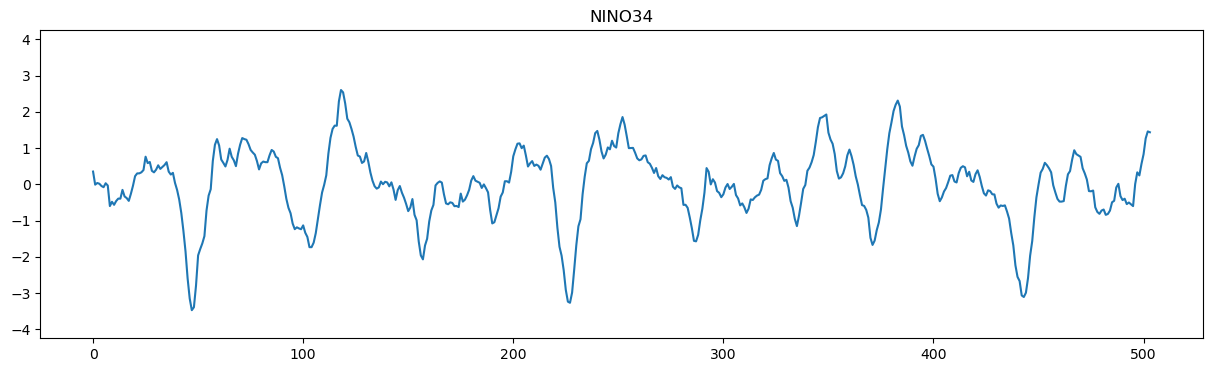

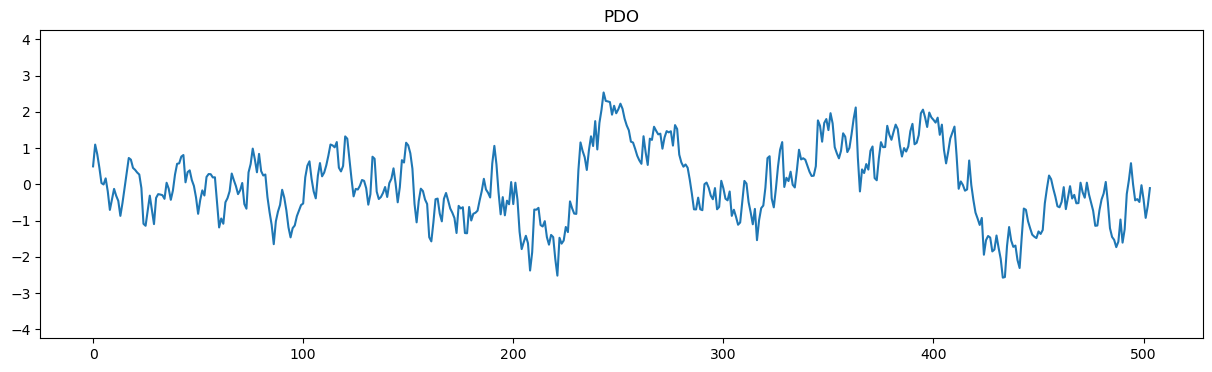

In [98]:
plt.figure(figsize=(15,4)); plt.ylim(-4.25, 4.25); plt.plot(np.arange(504), NINO34_indices[0]*-1); plt.title('NINO34'); plt.show()
plt.figure(figsize=(15,4)); plt.ylim(-4.25, 4.25); plt.plot(np.arange(504), PDO_indices[0]*-1); plt.title('PDO'); plt.show()


In [110]:
np.save('NINO34_FOSI.npy', nino34)  # Saves as binary file
# np.save('PDO_FOSI.npy', PDO_indices)  # Saves as binary file


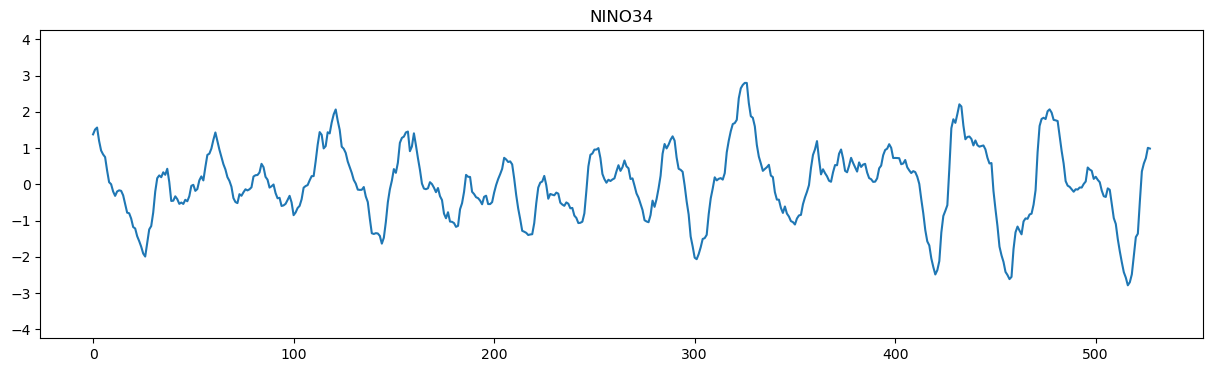

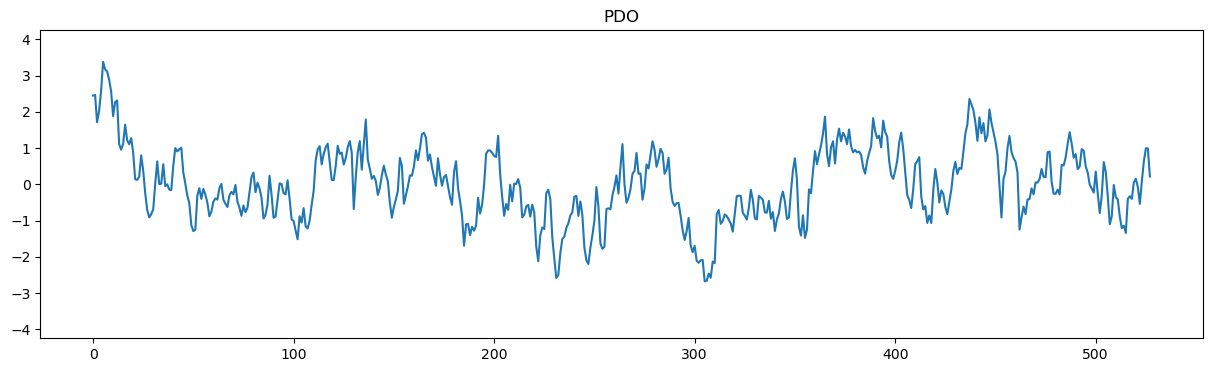

In [80]:
plt.figure(figsize=(15,4)); plt.ylim(-4.25, 4.25); plt.plot(np.arange(528), NINO34_indices[0]*-1); plt.title('NINO34'); plt.show()
plt.figure(figsize=(15,4)); plt.ylim(-4.25, 4.25); plt.plot(np.arange(528), PDO_indices[0]*-1); plt.title('PDO'); plt.show()


In [78]:
def compute_index(selected_anom):
    fanom = selected_anom
    fanomnan = fanom.copy(deep=True)

    ### standardize
    STANDARDIZE = True
    if STANDARDIZE: 
        fosistd = fanom.std('time')
        fosimean = fanom.mean('time')
        fanom = (fanom - fanom.mean('time')) / fanom.std('time')
        
    
    ### fill nans for EOF calc
    fanom = fanom.fillna(0)
    
    ### grab time, spatial coords for later reference
    times = fanom.time
    nnlat = fanom.lat
    nnlon = fanom.lon

    ### SVD method
    # reshape 
    # reshape data
    a, b, c = np.shape(fanom.values)  # have axis sizes for later (a, b, c)
    Y_stand = fanom.values.reshape(a, b*c);
    #Y = fosi_anom[field].values.reshape(a, b*c);
    Y = fanomnan.values.reshape(a, b*c)
    # print('orig shape: ',a, b, c)
    # print('new shape:  ', np.shape(Y_stand))

    Y_stand_ = da.from_array(Y_stand, chunks=(10000, 100)).persist()
    u, s, v = da.linalg.svd(Y_stand_)
    v = v.compute()
    s = s.compute()
    u = u.compute()

    eof_nums=[1,2,3]
    
    ee = []
    zz = []
    for eof_num in eof_nums:
        # Find the eigenvector (e1_svd) associated with "eof_num" from the SVD method
        e1_svd = (v[eof_num-1,:]).reshape(b,c)
    
        # Calculate the principal component (z1_svd) associated with "eof_num" from the SVD method
        z1_svd = u[:,eof_num-1]*(s[eof_num-1])
        ## standardize it
        z1_svd = (z1_svd-np.mean(z1_svd))/np.std(z1_svd)
    
        ee.append(e1_svd)
        zz.append(z1_svd)
    ee = np.array(ee)
    zz = np.array(zz)
    return zz

In [54]:
fanom = selected_anom #anomalies_rm30

In [55]:
### copy fanom for projection later
fanomnan = fanom.copy(deep=True)

### standardize
STANDARDIZE = True
if STANDARDIZE: 
    fosistd = fanom.std('time')
    fosimean = fanom.mean('time')
    fanom = (fanom - fanom.mean('time')) / fanom.std('time')
    

### fill nans for EOF calc
fanom = fanom.fillna(0)

### grab time, spatial coords for later reference
times = fanom.time
nnlat = fanom.lat
nnlon = fanom.lon

In [58]:
### SVD method
# reshape 
# reshape data
a, b, c = np.shape(fanom.values)  # have axis sizes for later (a, b, c)
Y_stand = fanom.values.reshape(a, b*c);
#Y = fosi_anom[field].values.reshape(a, b*c);
Y = fanomnan.values.reshape(a, b*c)
print('orig shape: ',a, b, c)
print('new shape:  ', np.shape(Y_stand))

orig shape:  528 10 41
new shape:   (528, 410)


In [59]:
Y_stand_ = da.from_array(Y_stand, chunks=(10000, 100)).persist()

In [60]:
u, s, v = da.linalg.svd(Y_stand_)

In [61]:
v = v.compute()

In [62]:
s = s.compute()

In [63]:
u = u.compute()

lag1 autocorrelation from np.correlate: 0.965
number of samples: 528
effective sample size: [9.]
variance explained by first three eigenvalues: 94.5%
variance explained by first four eigenvalues:  96.8% 



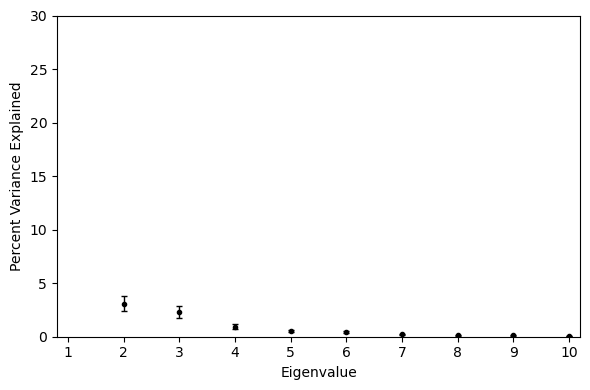

In [64]:
# convert eigenvalues to percent variance explained
pve = 100.*np.abs(s**2)/np.sum(np.abs(s**2))

f=plt.figure(figsize=(6,4))
#plt.plot(np.arange(1,len(pve)+1),pve,label='svd')
plt.ylim([0,30])
plt.xlim([0.8,10.2])
plt.ylabel('Percent Variance Explained')
plt.xlabel('Eigenvalue')
plt.xticks(np.arange(10)+1)
plt.grid(False, axis='x')
#plt.legend()
plt.tight_layout()

# Calculate effective N using lag-1 autocorrelation
# try anoms without fillna...
#tseries=np.nanmean(np.nanmean(fosi_sst[field].values,axis=2),axis=1)
tseries=np.nanmean(np.nanmean(fanomnan.values,axis=2),axis=1)

sigma=np.std(tseries)  ## calculate the standard deviation
mean=np.mean(tseries)  ## calculate the mean
N=len(tseries)         ## calculate the length of the timeseries
lag=1
t1_m=tseries[0:-1*lag]-mean
t2_m=tseries[lag:]-mean
alpha=np.correlate(t1_m,t2_m,mode='valid')/(N-lag)/(sigma**2)
print('lag1 autocorrelation from np.correlate:',round(alpha[0],3))

### Calculate the effective sample size (Nstar) for this data
### To estimate the number of independent samples - use Chapter 2 Barnes Eq. 88
Nstar=np.round((1-alpha)/(1+alpha)*N,0)
print(f'number of samples: {len(tseries)}')
print('effective sample size:',Nstar)
eb = pve*np.sqrt(2./Nstar)  ## North 1982, Barnes Chapter 3 Equation 80

plt.errorbar(np.arange(1, np.size(pve)+1.), pve, yerr=eb/2, xerr=None, \
             capsize=2, elinewidth=1, color='k', fmt='.');
print(f'variance explained by first three eigenvalues: {np.sum(pve[0:2]):0.1f}%')
print(f'variance explained by first four eigenvalues:  {np.sum(pve[0:3]):0.1f}%','\n')

In [65]:
eof_nums=[1,2,3]

ee = []
zz = []
for eof_num in eof_nums:
    # Find the eigenvector (e1_svd) associated with "eof_num" from the SVD method
    e1_svd = (v[eof_num-1,:]).reshape(b,c)

    # Calculate the principal component (z1_svd) associated with "eof_num" from the SVD method
    z1_svd = u[:,eof_num-1]*(s[eof_num-1])
    ## standardize it
    z1_svd = (z1_svd-np.mean(z1_svd))/np.std(z1_svd)

    ee.append(e1_svd)
    zz.append(z1_svd)
ee = np.array(ee)
zz = np.array(zz)

In [72]:
zz.shape

(3, 528)

In [66]:
# first EOF
d1 = (1./np.size(Y, axis=0))*np.dot(np.transpose(zz[0]), Y)  # Barnes Chapter 3 Equation (79)
d1plot = d1.reshape(b, c)  # this is the reshaped eigenvector to plot

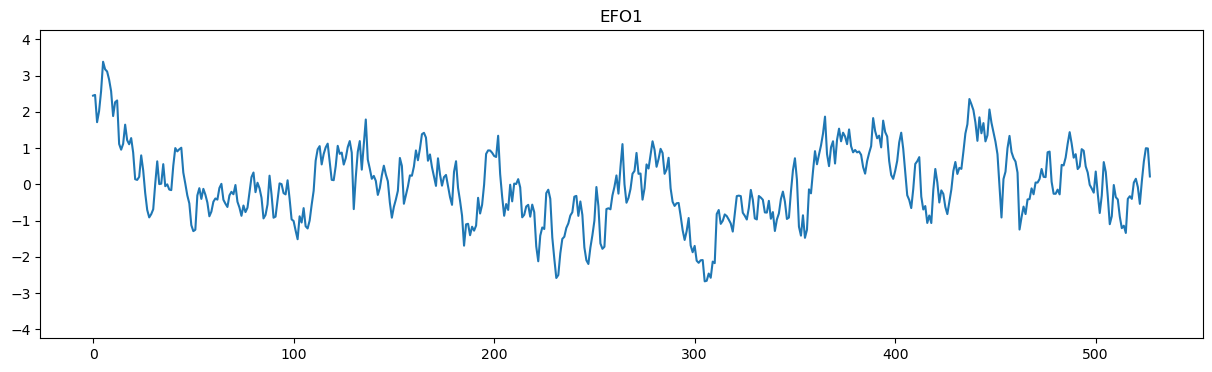

In [51]:
plt.figure(figsize=(15,4)); plt.ylim(-4.25, 4.25); plt.plot(np.arange(528), zz[0]*-1); plt.title('EFO1'); plt.show()
plt.figure(figsize=(15,4)); plt.ylim(-4.25, 4.25); plt.plot(np.arange(528), zz[0]*-1); plt.title('EFO1'); plt.show()


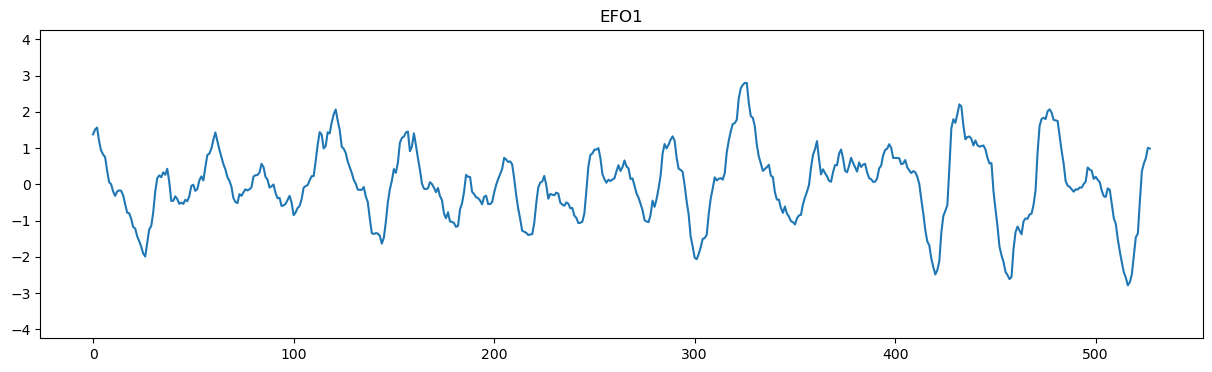

In [67]:
plt.figure(figsize=(15,4)); plt.ylim(-4.25, 4.25); plt.plot(np.arange(528), zz[0]*-1); plt.title('EFO1'); plt.show()


# Vertical temperature structure

In [17]:
output_dir = '/glade/derecho/scratch/cassiacai/subsurface_profiles_by_member'

subsurface_profiles = {}
for member_id in range(100):
    save_path = f'{output_dir}/member_{member_id}.pkl'
    if os.path.exists(save_path):
        with open(save_path, 'rb') as f:
            member_profiles = pickle.load(f)
        subsurface_profiles.update(member_profiles)

print(f"Total analogs loaded so far: {len(subsurface_profiles)}")
print(f"Members completed: {sum(1 for m in range(100) if os.path.exists(f'{output_dir}/member_{m}.pkl'))}")

Total analogs loaded so far: 331
Members completed: 100


In [18]:
bad_keys = []
for key, data in subsurface_profiles.items():
    profile = data['profile']
    if profile.isnull().all():
        bad_keys.append(key)
    if profile.shape[1] != 16:  # expecting 16 depth levels
        bad_keys.append(key)

print(f"Problematic profiles: {len(bad_keys)}")
if bad_keys:
    print(bad_keys[:10])

Problematic profiles: 0


In [19]:
import xarray as xr

def three_phases(profile, pre_post_months=2):
    """
    Splits a padded event profile into Pre-MHW, detection, and Post-MHW phase averages.
    profile: DataArray with dims (time, z_t), where the first and last `pre_post_months`
             timesteps are the padding, and the middle is the actual detected event.
    """
    pre_mhw = profile.isel(time=slice(0, pre_post_months)).mean(dim='time')
    detection = profile.isel(time=slice(pre_post_months, -pre_post_months)).mean(dim='time')
    post_mhw = profile.isel(time=slice(-pre_post_months, None)).mean(dim='time')

    return xr.concat([pre_mhw, detection, post_mhw], dim='phase').assign_coords(
        phase=['Pre-MHW', 'detection', 'Post-MHW']
    )

In [20]:
phase_profiles_all = {key: three_phases(data['profile']) for key, data in subsurface_profiles.items()}

def get_season(month):
    if month in [12, 1, 2]: return 'DJF'
    elif month in [3, 4, 5]: return 'MAM'
    elif month in [6, 7, 8]: return 'JJA'
    else: return 'SON'

season_groups = {'DJF': [], 'MAM': [], 'JJA': [], 'SON': []}
for key, data in subsurface_profiles.items():
    season = get_season(data['season'])
    season_groups[season].append(key)

for season, keys in season_groups.items():
    print(f"{season}: {len(keys)} analogs")

DJF: 80 analogs
MAM: 122 analogs
JJA: 87 analogs
SON: 42 analogs


In [21]:
season_composites = {}
for season, keys in season_groups.items():
    if len(keys) == 0:
        continue
    profiles_in_season = xr.concat([phase_profiles_all[k] for k in keys], dim='analog')
    season_composites[season] = profiles_in_season.mean(dim='analog')

print(f"Composited seasons: {list(season_composites.keys())}")

Composited seasons: ['DJF', 'MAM', 'JJA', 'SON']


In [22]:
for season in ['DJF', 'MAM', 'JJA', 'SON']:
    if season not in season_composites:
        continue
    detection_profile = season_composites[season].sel(phase='detection')
    surface_val = float(detection_profile.isel(z_t=0))
    half_max = surface_val * 0.5

    # Find deepest level where anomaly still exceeds half the surface value
    above_half = detection_profile.where(detection_profile >= half_max, drop=True)
    if above_half.size > 0:
        deepest_half_max = float(above_half.z_t.max()) / 100
    else:
        deepest_half_max = np.nan

    print(f"{season}: surface anomaly = {surface_val:.2f}°C, "
          f"depth of 50%-decay = {deepest_half_max:.0f}m")

DJF: surface anomaly = 0.66°C, depth of 50%-decay = 105m
MAM: surface anomaly = 0.66°C, depth of 50%-decay = 85m
JJA: surface anomaly = 0.70°C, depth of 50%-decay = 55m
SON: surface anomaly = 0.64°C, depth of 50%-decay = 95m


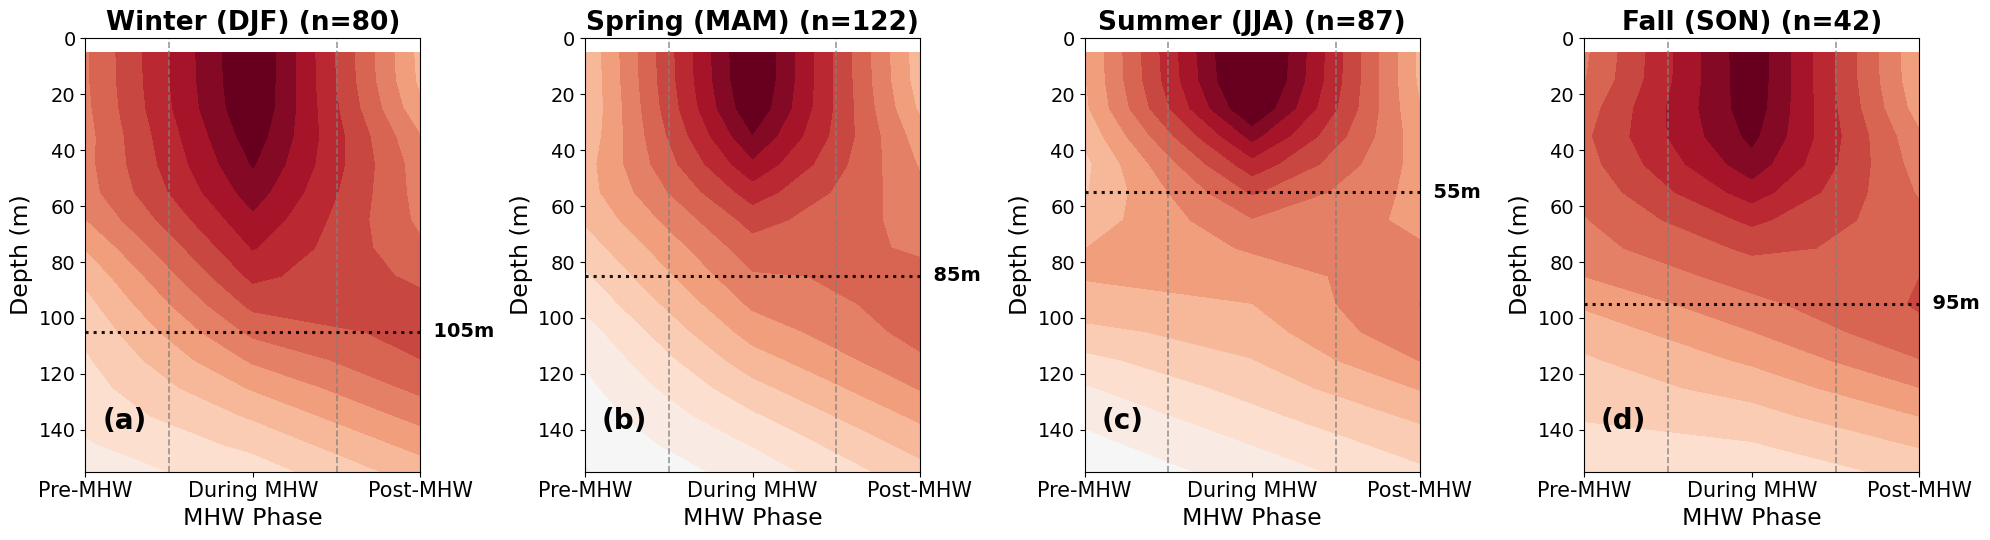

50%-decay depths: {'DJF': 105.0, 'MAM': 85.0, 'JJA': 55.0, 'SON': 95.0}


In [26]:
fig, axes = plt.subplots(1, 4, figsize=(20, 5.5))

season_labels = {'DJF': 'Winter (DJF)', 'MAM': 'Spring (MAM)', 'JJA': 'Summer (JJA)', 'SON': 'Fall (SON)'}
panel_letters = ['(a)', '(b)', '(c)', '(d)']

decay_depths = {}

for ax, season, letter in zip(axes, ['DJF', 'MAM', 'JJA', 'SON'], panel_letters):
    if season not in season_composites:
        ax.set_visible(False)
        continue

    phases = season_composites[season]

    contour = phases.transpose().plot.contourf(
        ax=ax, yincrease=False, cmap='RdBu_r', robust=True,
        levels=25, vmin=-0.6, vmax=0.6, add_colorbar=False
    )

    for x in [0.5, 1.5]:
        ax.axvline(x, color='grey', linestyle='--', linewidth=1.2, alpha=0.8)

    detection_profile = phases.sel(phase='detection')
    surface_val = float(detection_profile.isel(z_t=0))
    half_max = surface_val * 0.5
    above_half = detection_profile.where(detection_profile >= half_max, drop=True)
    decay_depth_cm = float(above_half.z_t.max()) if above_half.size > 0 else np.nan
    decay_depths[season] = decay_depth_cm / 100

    ax.axhline(decay_depth_cm, color='black', linestyle=':', linewidth=2.2, alpha=0.9)
    ax.text(2.0, decay_depth_cm, f'  {decay_depth_cm/100:.0f}m', va='center', ha='left',
            fontsize=14, fontweight='bold', color='black')

    ax.set_xticks([0., 1., 2.])
    ax.set_xticklabels(["Pre-MHW", "During MHW", "Post-MHW"], fontsize=15)
    ax.set_yticks([0, 2000, 4000, 6000, 8000, 10000, 12000, 14000])
    ax.set_yticklabels([0, 20, 40, 60, 80, 100, 120, 140], fontsize=14)
    ax.set_xlabel("MHW Phase", fontsize=17)
    ax.set_ylabel("Depth (m)", fontsize=17)
    ax.set_ylim(15500, 0)
    ax.set_title(f'{season_labels[season]} (n={len(season_groups[season])})', fontsize=19, fontweight='bold')

    ax.text(0.05, 0.15, letter, transform=ax.transAxes, fontsize=20, fontweight='bold', va='top')


plt.tight_layout()
plt.savefig('Figure_subsurface_seasonal_composites_decay.png', dpi=300, bbox_inches='tight')
plt.show()

print("50%-decay depths:", decay_depths)

In [45]:
# ============================================================
# For each analog, find the month with deepest 50%-decay penetration
# ============================================================
def find_deepest_penetration_month(profile, threshold_frac=0.5):
    decay_depths_per_month = []
    for t in range(len(profile.time)):
        month_profile = profile.isel(time=t)
        surface_val = float(month_profile.isel(z_t=0))
        if surface_val <= 0 or np.isnan(surface_val):
            decay_depths_per_month.append(np.nan)
            continue
        half_max = surface_val * threshold_frac
        above_half = month_profile.where(month_profile >= half_max, drop=True)
        depth = float(above_half.z_t.max()) if above_half.size > 0 else np.nan
        decay_depths_per_month.append(depth)

    decay_depths_per_month = np.array(decay_depths_per_month)
    if np.all(np.isnan(decay_depths_per_month)):
        return None, None
    deepest_idx = int(np.nanargmax(decay_depths_per_month))
    return deepest_idx, decay_depths_per_month[deepest_idx]

In [46]:
# ============================================================
# Apply to all analogs
# ============================================================
analog_deepest_penetration = {}

for key, data in subsurface_profiles.items():
    profile = data['profile']
    deepest_idx, deepest_depth_cm = find_deepest_penetration_month(profile)
    if deepest_idx is None:
        continue

    analog_deepest_penetration[key] = {
        'deepest_depth_m': deepest_depth_cm / 100,
        'deepest_month_index': deepest_idx,
        'deepest_time': str(profile.time.values[deepest_idx])[:7],
        'total_padded_length': len(profile.time),
    }

print(f"Computed deepest penetration for {len(analog_deepest_penetration)} analogs")

Computed deepest penetration for 331 analogs


In [47]:
# ============================================================
# Summary statistics
# ============================================================
depths = np.array([v['deepest_depth_m'] for v in analog_deepest_penetration.values()])
print(f"Deepest penetration across analogs: mean={depths.mean():.1f}m, "
      f"median={np.median(depths):.1f}m, max={depths.max():.1f}m, min={depths.min():.1f}m")

# How many analogs hit the 155m ceiling (same caveat as FOSI Blob)?
at_ceiling = np.sum(depths >= 155)
print(f"Analogs reaching the 155m depth ceiling: {at_ceiling} / {len(depths)} ({100*at_ceiling/len(depths):.1f}%)")

Deepest penetration across analogs: mean=147.0m, median=155.0m, max=155.0m, min=75.0m
Analogs reaching the 155m depth ceiling: 241 / 331 (72.8%)


In [27]:
import pop_tools

grid = pop_tools.get_grid('POP_gx1v7')
mask = xr.where((grid['REGION_MASK']>0) & (grid['REGION_MASK']<9), 1, np.nan)

In [61]:
# ============================================================
# Step 1: Load FOSI's raw 3D TEMP field, restricted to 155m
# ============================================================

field = 'TEMP'
firstyear, lastyear = 1979, 2020

fpath = '/glade/campaign/cesm/development/espwg/SMYLE/initial_conditions/SMYLE-FOSI/ocn/proc/tseries/month_1/'
fname = f'g.e22.GOMIPECOIAF_JRA-1p4-2018.TL319_g17.SMYLE.005.pop.h.{field}.030601-036812.nc'

ds_smyle_fosi_temp = xr.open_dataset(fpath+fname)[field].sel(z_t=slice(0, 25000))  # match the 16 depth levels used for LENS (surface-155m)
# ds_smyle_fosi_temp = xr.open_dataset(fpath+fname)[field].isel(z_t=slice(0, 16))  # match the 16 depth levels used for LENS (surface-155m)

fosi_montime_vals = [cftime.DatetimeNoLeap(1958+year, 1+month, 15) for year in range(63) for month in range(12)]
ds_smyle_fosi_temp['time'] = fosi_montime_vals

fosi_temp_raw = ds_smyle_fosi_temp[ds_smyle_fosi_temp.time['time.year'].isin(list(range(firstyear, lastyear+1)))].where(mask==1, np.nan)

print(fosi_temp_raw.dims, fosi_temp_raw.shape)

# ============================================================
# Step 2: Regrid to CESM2-LENS grid (same two-step process as FOSI MLD)
# ============================================================

('time', 'z_t', 'nlat', 'nlon') (504, 23, 384, 320)


In [63]:
import importlib
import analysis_functions as afuncs
import cesm2_lens_utils

importlib.reload(afuncs)
importlib.reload(cesm2_lens_utils)
import xesmf as xe

In [64]:

fosi_temp_1deg_wzeros = afuncs.regrid_SMYLE(fosi_temp_raw)
fosi_temp_1deg = fosi_temp_1deg_wzeros.where(fosi_temp_1deg_wzeros != 0, np.nan)


In [65]:
#### CESM LENS2
var = 'SST'
comp = 'atm'
directory = f'/glade/campaign/cgd/cesm/CESM2-LE/{comp}/proc/tseries/month_1/{var}/'
ens_memb_index = 0
ds_var_hist_SST, ds_var_fut_SST = afuncs.get_ds_var(directory, 'SST','atm', ens_memb_index) 

# selecting our observational time period overlap with ERA5 (1979 to 2022)
CESMLENS_SST_hist_time_slice = ds_var_hist_SST.SST.sel(time=slice('1979-01-01', '2015-01-01'))
    
CESMLENS_SST_fut_time_slice = ds_var_fut_SST.SST.sel(time=slice('2015-02-01', '2020-12-01'))

CESMLENS_SST_ds = xr.concat([CESMLENS_SST_hist_time_slice, CESMLENS_SST_fut_time_slice], dim='time')
CESMLENS_SST = CESMLENS_SST_ds.compute()

In [66]:
# ============================================================
# 4D detrending function (yours, confirmed working)
# ============================================================
def calculate_anomalies_trend_features_4d(ds):
    if 'z_t' not in ds.dims:
        raise ValueError("Input data must have 'z_t' dimension")

    dyr = ds.time.dt.year + ds.time.dt.month/12
    model = np.array([
        np.ones(len(dyr)), dyr - np.mean(dyr),
        np.sin(2*np.pi*dyr), np.cos(2*np.pi*dyr),
        np.sin(4*np.pi*dyr), np.cos(4*np.pi*dyr)
    ])
    pmodel = np.linalg.pinv(model)

    model_da = xr.DataArray(model.T, dims=['time','coeff'], coords={'time': ds.time, 'coeff': np.arange(1,7)})
    pmodel_da = xr.DataArray(pmodel.T, dims=['coeff','time'], coords={'coeff': np.arange(1,7), 'time': ds.time})

    coeffs = xr.dot(pmodel_da, ds)
    mean = model_da[:, 0].dot(coeffs.sel(coeff=1))
    trend = model_da[:, 1].dot(coeffs.sel(coeff=2))
    seas = model_da[:, 2:].dot(coeffs.sel(coeff=slice(3, 6)))

    full_model = model_da.dot(coeffs)
    ssta_notrend = ds - full_model

    if ssta_notrend.chunks:
        ssta_notrend = ssta_notrend.chunk({'time': -1, 'z_t': -1})

    threshold = ssta_notrend.quantile(0.9, dim=('time'))
    features_notrend = ssta_notrend.where(ssta_notrend >= threshold)

    return mean, trend, seas, features_notrend, ssta_notrend

In [67]:
regridder_temp = xe.Regridder(fosi_temp_1deg.sel(time=slice('1979-01-01','2021-01-01')),
                                CESMLENS_SST[:,:,:], 'nearest_s2d', periodic=True)
fosi_temp_regridded = regridder_temp(fosi_temp_1deg.sel(time=slice('1979-01-01','2021-01-01')))

print(fosi_temp_regridded.dims, fosi_temp_regridded.shape)

# ============================================================
# Step 3: Detrend/deseasonalize (reuse the 4D function, now with lat/lon dims)
# ============================================================
mean, trend, seas, features_notrend, fosi_ssta_3d_notrend = calculate_anomalies_trend_features_4d(fosi_temp_regridded)

# Restrict to NEP box, matching the LENS analysis region
fosi_ssta_3d_NEP = fosi_ssta_3d_notrend.sel(lon=slice(150, 250), lat=slice(5, 65))

print(fosi_ssta_3d_NEP.dims, fosi_ssta_3d_NEP.shape)

('time', 'z_t', 'lat', 'lon') (504, 23, 192, 288)
('time', 'z_t', 'lat', 'lon') (504, 23, 64, 81)


In [68]:
mask_3 = xr.open_dataset('mean_mask_3.nc').mhw_obj
mask_3 = xr.where(mask_3 > 0.1, 1, 0)

blob_mask_nan = mask_3
blob_mask = mask_3

In [69]:
# ============================================================
# Step 4: Apply canonical footprint (mask_3), extract Blob's padded profile, phase-split
# ============================================================
fosi_ssta_masked = fosi_ssta_3d_NEP.where(mask_3 == 1)

# blob_times already established (May 2014 - Dec 2015, 20 months)
full_time_index = fosi_ssta_masked.time
first_idx = int(np.where(full_time_index.values == blob_times.values[0])[0][0])
last_idx = int(np.where(full_time_index.values == blob_times.values[-1])[0][0])

pad_start = max(0, first_idx - 2)
pad_end = min(len(full_time_index) - 1, last_idx + 2)
padded_times = full_time_index.isel(time=slice(pad_start, pad_end + 1))

fosi_profile = fosi_ssta_masked.sel(time=padded_times).mean(dim=('lat','lon')).compute()

fosi_phases = three_phases(fosi_profile)
print(fosi_phases.dims, fosi_phases.shape)

('phase', 'z_t') (3, 23)


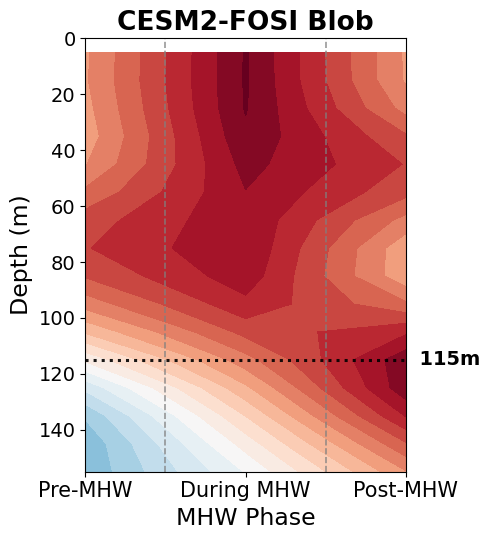

FOSI Blob 50%-decay depth: 115m


In [70]:
# ============================================================
# Step 5: Plot, matching the seasonal composite style
# ============================================================
fig, ax = plt.subplots(figsize=(5, 5.5))

contour = fosi_phases.transpose().plot.contourf(
    ax=ax, yincrease=False, cmap='RdBu_r', robust=True,
    levels=25, vmin=-0.6, vmax=0.6, add_colorbar=False
)

for x in [0.5, 1.5]:
    ax.axvline(x, color='grey', linestyle='--', linewidth=1.2, alpha=0.8)

detection_profile = fosi_phases.sel(phase='detection')
surface_val = float(detection_profile.isel(z_t=0))
half_max = surface_val * 0.5
above_half = detection_profile.where(detection_profile >= half_max, drop=True)
decay_depth_cm = float(above_half.z_t.max()) if above_half.size > 0 else np.nan

ax.axhline(decay_depth_cm, color='black', linestyle=':', linewidth=2.2, alpha=0.9)
ax.text(2.0, decay_depth_cm, f'  {decay_depth_cm/100:.0f}m', va='center', ha='left',
        fontsize=14, fontweight='bold', color='black')

ax.set_xticks([0., 1., 2.])
ax.set_xticklabels(["Pre-MHW", "During MHW", "Post-MHW"], fontsize=15)
ax.set_yticks([0, 2000, 4000, 6000, 8000, 10000, 12000, 14000])
ax.set_yticklabels([0, 20, 40, 60, 80, 100, 120, 140], fontsize=14)
ax.set_xlabel("MHW Phase", fontsize=17)
ax.set_ylabel("Depth (m)", fontsize=17)
ax.set_ylim(15500, 0)
ax.set_title('CESM2-FOSI Blob', fontsize=19, fontweight='bold')

plt.tight_layout()
plt.savefig('Figure_subsurface_FOSI_blob.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"FOSI Blob 50%-decay depth: {decay_depth_cm/100:.0f}m")

In [71]:
def five_phases(profile, ssta_profile=None, pre_post_months=2):
    n_total = len(profile.time)
    core_start = pre_post_months
    core_end = n_total - pre_post_months

    pre_mhw = profile.isel(time=slice(0, pre_post_months)).mean(dim='time')
    post_mhw = profile.isel(time=slice(-pre_post_months, None)).mean(dim='time')

    if ssta_profile is None:
        ssta_profile = profile.isel(z_t=0)
    core_ssta = ssta_profile.isel(time=slice(core_start, core_end))
    peak_idx_within_core = int(core_ssta.argmax('time').values)
    peak_idx_global = core_start + peak_idx_within_core

    has_prepeak = peak_idx_global > core_start
    has_decline = peak_idx_global < core_end - 1

    prepeak = (profile.isel(time=slice(core_start, peak_idx_global)).mean(dim='time')
               if has_prepeak else xr.full_like(pre_mhw, np.nan))
    peak = profile.isel(time=peak_idx_global)
    decline = (profile.isel(time=slice(peak_idx_global + 1, core_end)).mean(dim='time')
               if has_decline else xr.full_like(pre_mhw, np.nan))

    return xr.concat([pre_mhw, prepeak, peak, decline, post_mhw], dim='phase').assign_coords(
        phase=['Pre-MHW', 'pre-peak', 'maximum SSTa', 'decline', 'Post-MHW']
    )

In [72]:
# Apply to FOSI's padded profile (reusing fosi_profile from the 3-phase pipeline)
fosi_phases_5 = five_phases(fosi_profile)
print(fosi_phases_5.dims, fosi_phases_5.shape)

('phase', 'z_t') (5, 23)


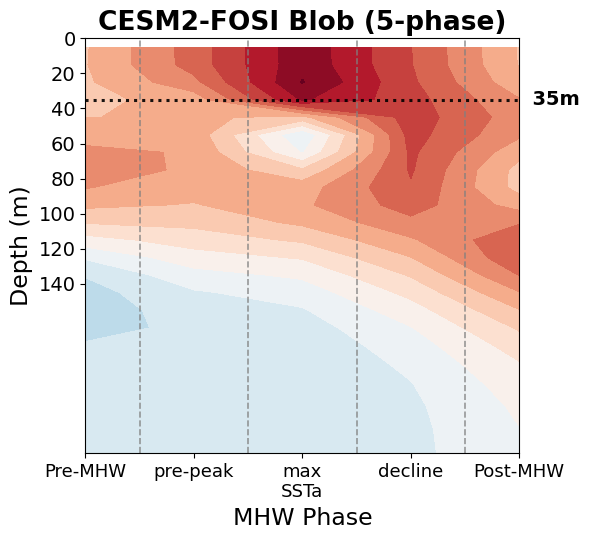

FOSI Blob 50%-decay depth (5-phase, at max SSTa): 35m


In [76]:
fig, ax = plt.subplots(figsize=(6, 5.5))

contour = fosi_phases_5.transpose().plot.contourf(
    ax=ax, yincrease=False, cmap='RdBu_r', robust=True,
    levels=21, vmin=-1, vmax=1, add_colorbar=False
)

for x in [0.5, 1.5, 2.5, 3.5]:
    ax.axvline(x, color='grey', linestyle='--', linewidth=1.2, alpha=0.8)

peak_profile_fosi = fosi_phases_5.sel(phase='maximum SSTa')
surface_val = float(peak_profile_fosi.isel(z_t=0))
half_max = surface_val * 0.5
above_half = peak_profile_fosi.where(peak_profile_fosi >= half_max, drop=True)
decay_depth_cm = float(above_half.z_t.max()) if above_half.size > 0 else np.nan

ax.axhline(decay_depth_cm, color='black', linestyle=':', linewidth=2.2, alpha=0.9)
ax.text(4.0, decay_depth_cm, f'  {decay_depth_cm/100:.0f}m', va='center', ha='left',
        fontsize=14, fontweight='bold', color='black')

ax.set_xticks([0, 1, 2, 3, 4])
ax.set_xticklabels(["Pre-MHW", "pre-peak", "max\nSSTa", "decline", "Post-MHW"], fontsize=13)
ax.set_yticks([0, 2000, 4000, 6000, 8000, 10000, 12000, 14000])
ax.set_yticklabels([0, 20, 40, 60, 80, 100, 120, 140], fontsize=14)
ax.set_xlabel("MHW Phase", fontsize=17)
ax.set_ylabel("Depth (m)", fontsize=17)
ax.set_title('CESM2-FOSI Blob (5-phase)', fontsize=19, fontweight='bold')

plt.tight_layout()
plt.savefig('Figure_subsurface_FOSI_blob_5phase.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"FOSI Blob 50%-decay depth (5-phase, at max SSTa): {decay_depth_cm/100:.0f}m")

In [42]:
# ============================================================
# Find the month of DEEPEST subsurface penetration (not necessarily peak surface SSTa)
# ============================================================
def find_deepest_penetration_month(profile, threshold_frac=0.5):
    """
    profile: DataArray (time, z_t)
    For each timestep, computes the 50%-decay depth (relative to that timestep's own
    surface value), then finds which timestep has the DEEPEST such decay depth.
    """
    decay_depths_per_month = []
    for t in range(len(profile.time)):
        month_profile = profile.isel(time=t)
        surface_val = float(month_profile.isel(z_t=0))
        if surface_val <= 0:
            decay_depths_per_month.append(np.nan)
            continue
        half_max = surface_val * 0.5
        above_half = month_profile.where(month_profile >= half_max, drop=True)
        depth = float(above_half.z_t.max()) if above_half.size > 0 else np.nan
        decay_depths_per_month.append(depth)

    decay_depths_per_month = np.array(decay_depths_per_month)
    deepest_idx = int(np.nanargmax(decay_depths_per_month))
    return deepest_idx, decay_depths_per_month

In [82]:
_, all_decay_depths = find_deepest_penetration_month(fosi_profile)
max_penetration_depth_m = np.nanmax(all_decay_depths) / 100
print(f"FOSI Blob maximum penetration depth: {max_penetration_depth_m:.0f}m")

FOSI Blob maximum penetration depth: 175m


In [83]:
above_threshold = fosi_profile.where(fosi_profile >= 0.5)  # fixed 0.5°C threshold, not relative to monthly surface value
depth_reached = above_threshold.max(dim='time')  # for each depth, does ANY month exceed 0.5°C there?
valid_depths = depth_reached.where(depth_reached.notnull(), drop=True)
max_depth_m = float(valid_depths.z_t.max()) / 100 if valid_depths.size > 0 else np.nan
print(f"FOSI Blob: deepest level ever exceeding 0.5°C = {max_depth_m:.0f}m")

FOSI Blob: deepest level ever exceeding 0.5°C = 135m


In [84]:
def find_max_penetration_depth_absolute(profile, threshold_c=0.5):
    above_threshold = profile.where(profile >= threshold_c)
    if above_threshold.isnull().all():
        return np.nan
    depth_reached = above_threshold.max(dim='time')
    valid_depths = depth_reached.where(depth_reached.notnull(), drop=True)
    if valid_depths.size == 0:
        return np.nan
    return float(valid_depths.z_t.max()) / 100

In [85]:
# Apply to all analogs (using your original 155m-cutoff data, since this is a cleaner definition
# that doesn't depend on chasing a ceiling the way the relative-threshold version did)
analog_max_penetration_absolute = {}
for key, data in subsurface_profiles.items():
    depth_m = find_max_penetration_depth_absolute(data['profile'], threshold_c=0.5)
    if not np.isnan(depth_m):
        analog_max_penetration_absolute[key] = depth_m

depths_abs = np.array(list(analog_max_penetration_absolute.values()))
print(f"Max penetration (0.5°C threshold): mean={depths_abs.mean():.1f}m, median={np.median(depths_abs):.1f}m, max={depths_abs.max():.1f}m")

at_ceiling_abs = np.sum(depths_abs >= 155)
print(f"Analogs reaching 155m ceiling with this definition: {at_ceiling_abs} / {len(depths_abs)} ({100*at_ceiling_abs/len(depths_abs):.1f}%)")

Max penetration (0.5°C threshold): mean=106.8m, median=105.0m, max=155.0m
Analogs reaching 155m ceiling with this definition: 11 / 331 (3.3%)


In [86]:
fosi_max_penetration = 135  # from your confirmed FOSI result

p = np.mean(depths_abs >= fosi_max_penetration)
N_years = 100 * 42
n = len(depths_abs)
rp = N_years / (n * p) if p > 0 else np.inf

print(f"FOSI Blob (135m): {100*p:.1f}% of analogs reach this depth or deeper, return period = {rp:.1f} years")

FOSI Blob (135m): 17.8% of analogs reach this depth or deeper, return period = 71.2 years


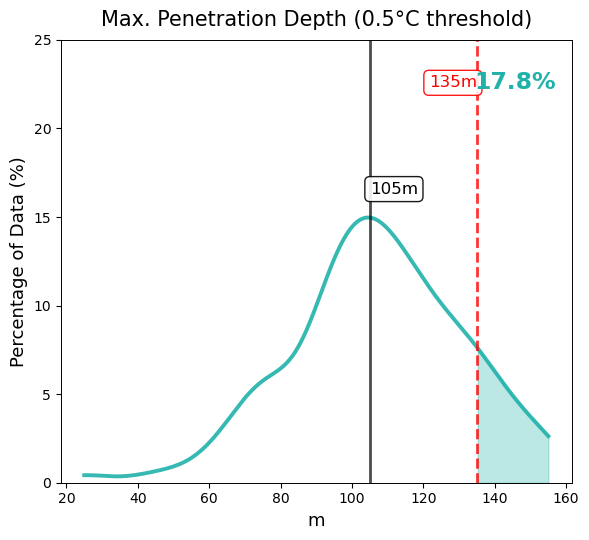

In [87]:
fig, ax = plt.subplots(figsize=(6, 5.5))

values = depths_abs  # max penetration depth (0.5°C threshold), all analogs
threshold = fosi_max_penetration  # 135

counts, bin_edges = np.histogram(values, bins=15)
bin_width = bin_edges[1] - bin_edges[0]
kde = gaussian_kde(values)
x = np.linspace(values.min(), values.max(), 500)
y_kde = kde(x) * bin_width * 100

ax.plot(x, y_kde, color='lightseagreen', linewidth=2.8, alpha=0.9)

mask = x >= threshold
ax.fill_between(x[mask], y_kde[mask], color='lightseagreen', alpha=0.3)

median_val = np.median(values)
ax.axvline(threshold, color='red', linestyle='dashed', lw=2.0, alpha=0.8)
ax.axvline(median_val, color='k', linestyle='-', lw=2, alpha=0.7)

pct_exceeding = 100 * np.mean(values >= threshold)

ax.text(threshold, 23, f'{threshold:.0f}m', ha='right', va='top', fontsize=12, color='red',
        bbox=dict(facecolor='white', edgecolor='red', boxstyle='round,pad=0.3', alpha=0.9))
ax.text(median_val, 17, f'{median_val:.0f}m', ha='left', va='top', fontsize=12, color='k',
        bbox=dict(facecolor='white', edgecolor='k', boxstyle='round,pad=0.3', alpha=0.9))

ax.text(0.97, 0.93, f"{pct_exceeding:.1f}%", transform=ax.transAxes, ha='right', va='top',
        fontsize=17, color='lightseagreen', fontweight='bold')

ax.set_title('Max. Penetration Depth (0.5°C threshold)', fontsize=15, pad=10)
ax.set_xlabel('m', fontsize=13)
ax.set_ylabel('Percentage of Data (%)', fontsize=13)
ax.set_ylim(0, 25)
ax.set_facecolor('white')
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_edgecolor('k')
    spine.set_linewidth(0.7)

plt.tight_layout()
plt.savefig('Figure_penetration_depth.png', dpi=300, bbox_inches='tight')
plt.show()

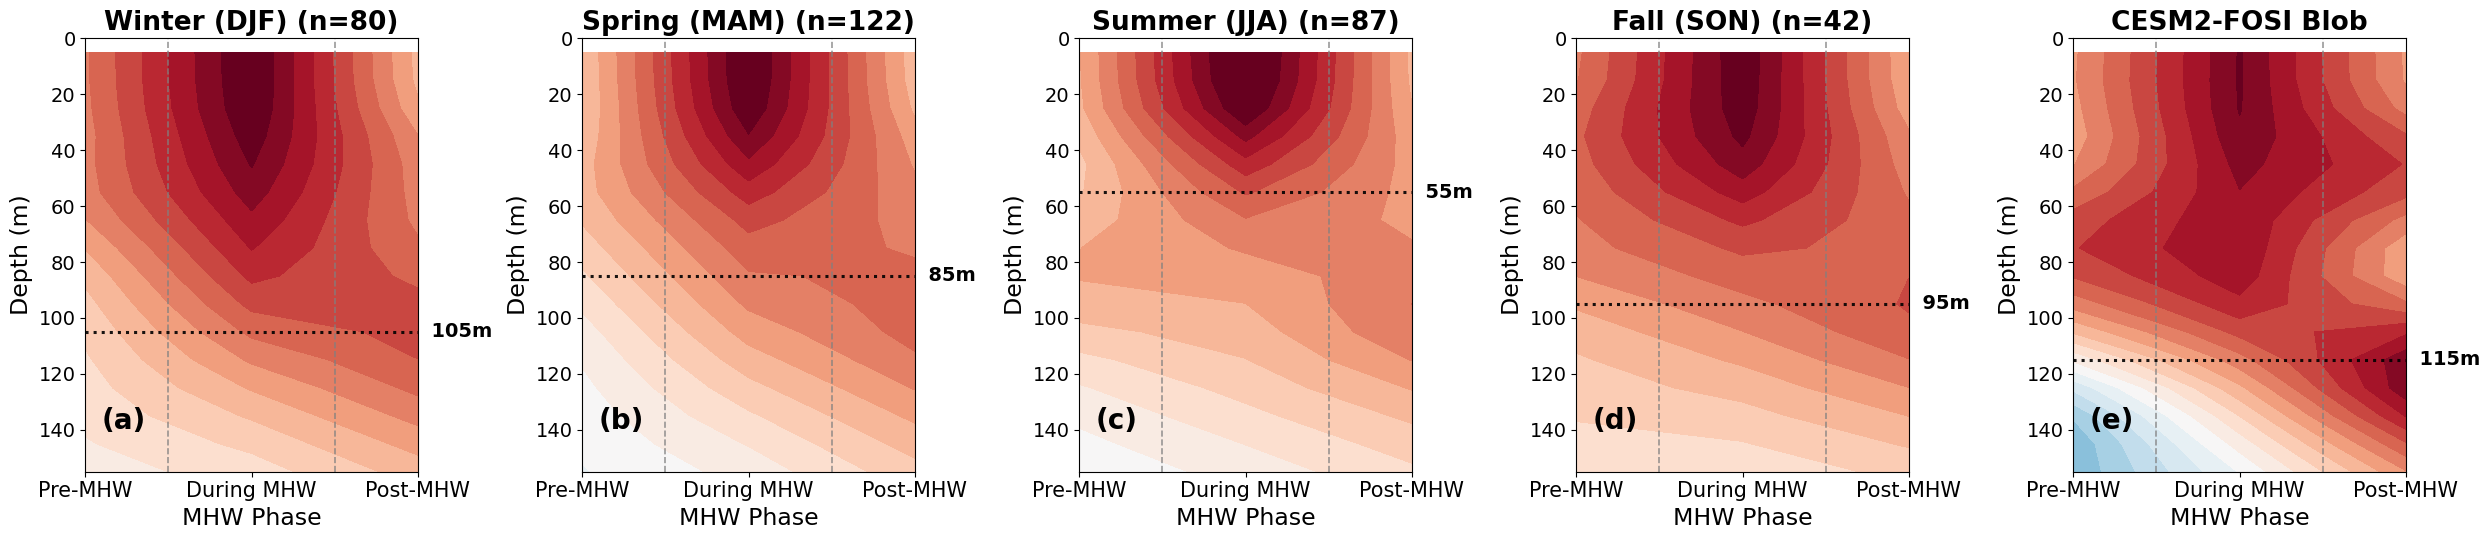

50%-decay depths: {'DJF': 105.0, 'MAM': 85.0, 'JJA': 55.0, 'SON': 95.0, 'FOSI Blob': 115.0}


In [88]:
fig, axes = plt.subplots(1, 5, figsize=(25, 5.5))

season_labels = {'DJF': 'Winter (DJF)', 'MAM': 'Spring (MAM)', 'JJA': 'Summer (JJA)', 'SON': 'Fall (SON)'}
panel_letters = ['(a)', '(b)', '(c)', '(d)', '(e)']
decay_depths = {}

# --- Seasonal composite panels (a)-(d) ---
for ax, season, letter in zip(axes[:4], ['DJF', 'MAM', 'JJA', 'SON'], panel_letters[:4]):
    if season not in season_composites:
        ax.set_visible(False)
        continue

    phases = season_composites[season]
    contour = phases.transpose().plot.contourf(
        ax=ax, yincrease=False, cmap='RdBu_r', robust=True,
        levels=25, vmin=-0.6, vmax=0.6, add_colorbar=False
    )

    for x in [0.5, 1.5]:
        ax.axvline(x, color='grey', linestyle='--', linewidth=1.2, alpha=0.8)

    detection_profile = phases.sel(phase='detection')
    surface_val = float(detection_profile.isel(z_t=0))
    half_max = surface_val * 0.5
    above_half = detection_profile.where(detection_profile >= half_max, drop=True)
    decay_depth_cm = float(above_half.z_t.max()) if above_half.size > 0 else np.nan
    decay_depths[season] = decay_depth_cm / 100

    ax.axhline(decay_depth_cm, color='black', linestyle=':', linewidth=2.2, alpha=0.9)
    ax.text(2.0, decay_depth_cm, f'  {decay_depth_cm/100:.0f}m', va='center', ha='left',
            fontsize=14, fontweight='bold', color='black')

    ax.set_xticks([0., 1., 2.])
    ax.set_xticklabels(["Pre-MHW", "During MHW", "Post-MHW"], fontsize=15)
    ax.set_yticks([0, 2000, 4000, 6000, 8000, 10000, 12000, 14000])
    ax.set_yticklabels([0, 20, 40, 60, 80, 100, 120, 140], fontsize=14)
    ax.set_xlabel("MHW Phase", fontsize=17)
    ax.set_ylabel("Depth (m)", fontsize=17)
    ax.set_ylim(15500, 0)
    ax.set_title(f'{season_labels[season]} (n={len(season_groups[season])})', fontsize=19, fontweight='bold')
    ax.text(0.05, 0.15, letter, transform=ax.transAxes, fontsize=20, fontweight='bold', va='top')

# --- FOSI Blob panel (e) ---
ax = axes[4]
contour = fosi_phases.transpose().plot.contourf(
    ax=ax, yincrease=False, cmap='RdBu_r', robust=True,
    levels=25, vmin=-0.6, vmax=0.6, add_colorbar=False
)

for x in [0.5, 1.5]:
    ax.axvline(x, color='grey', linestyle='--', linewidth=1.2, alpha=0.8)

detection_profile_fosi = fosi_phases.sel(phase='detection')
surface_val_fosi = float(detection_profile_fosi.isel(z_t=0))
half_max_fosi = surface_val_fosi * 0.5
above_half_fosi = detection_profile_fosi.where(detection_profile_fosi >= half_max_fosi, drop=True)
decay_depth_cm_fosi = float(above_half_fosi.z_t.max()) if above_half_fosi.size > 0 else np.nan
decay_depths['FOSI Blob'] = decay_depth_cm_fosi / 100

ax.axhline(decay_depth_cm_fosi, color='black', linestyle=':', linewidth=2.2, alpha=0.9)
ax.text(2.0, decay_depth_cm_fosi, f'  {decay_depth_cm_fosi/100:.0f}m', va='center', ha='left',
        fontsize=14, fontweight='bold', color='black')

ax.set_xticks([0., 1., 2.])
ax.set_xticklabels(["Pre-MHW", "During MHW", "Post-MHW"], fontsize=15)
ax.set_yticks([0, 2000, 4000, 6000, 8000, 10000, 12000, 14000])
ax.set_yticklabels([0, 20, 40, 60, 80, 100, 120, 140], fontsize=14)
ax.set_xlabel("MHW Phase", fontsize=17)
ax.set_ylabel("Depth (m)", fontsize=17)
ax.set_ylim(15500, 0)
ax.set_title('CESM2-FOSI Blob', fontsize=19, fontweight='bold')
ax.text(0.05, 0.15, '(e)', transform=ax.transAxes, fontsize=20, fontweight='bold', va='top')

plt.tight_layout()
plt.savefig('Figure_subsurface_seasonal_composites_with_FOSI.png', dpi=300, bbox_inches='tight')
plt.show()

print("50%-decay depths:", decay_depths)

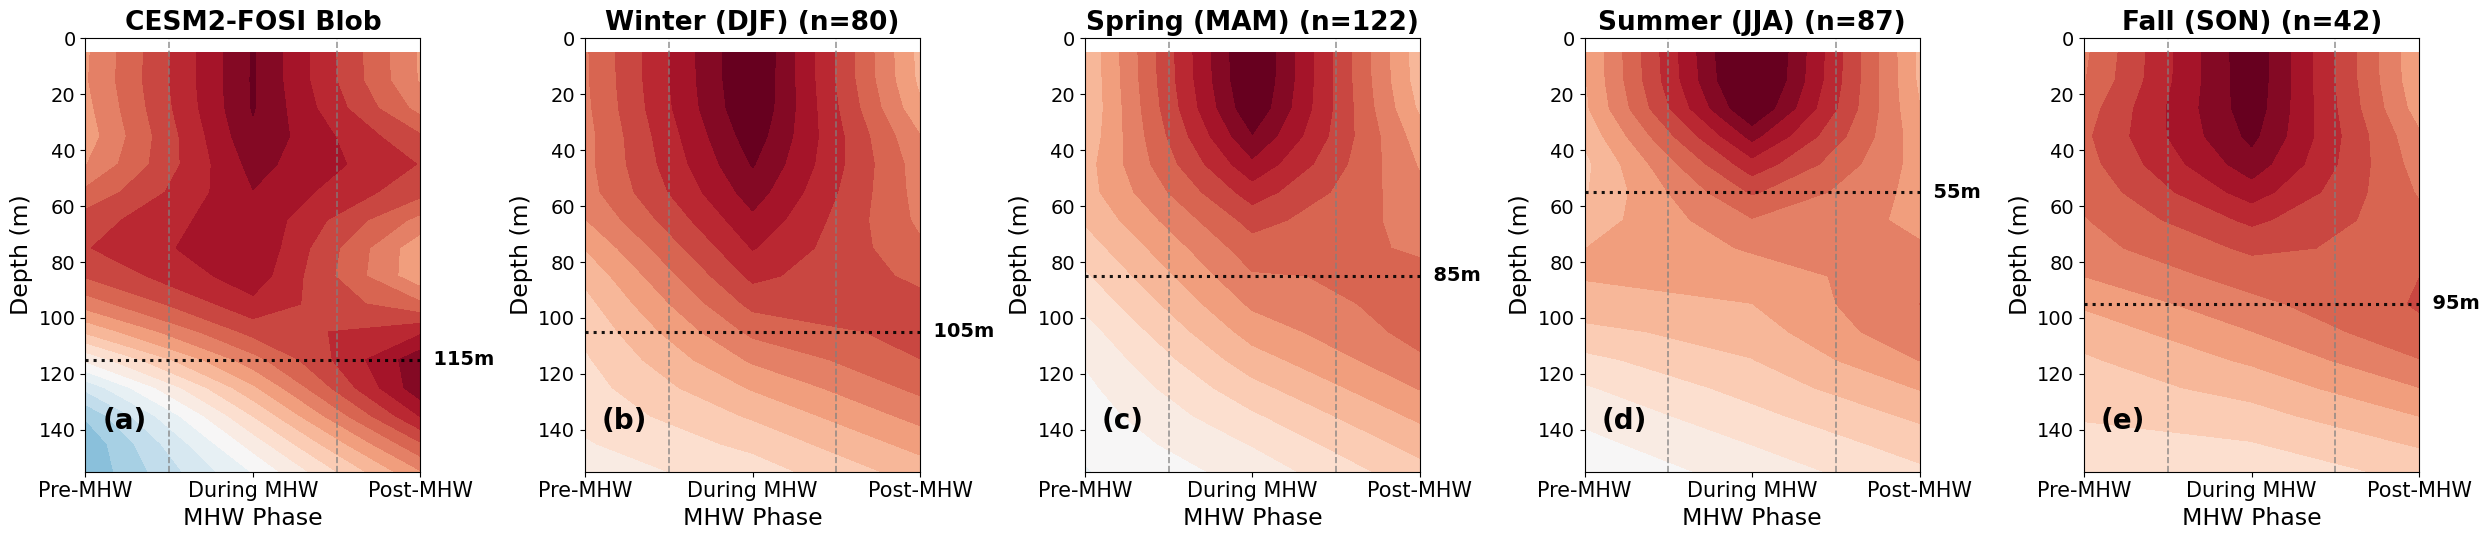

50%-decay depths: {'FOSI Blob': 115.0, 'DJF': 105.0, 'MAM': 85.0, 'JJA': 55.0, 'SON': 95.0}


In [89]:
fig, axes = plt.subplots(1, 5, figsize=(25, 5.5))

season_labels = {'DJF': 'Winter (DJF)', 'MAM': 'Spring (MAM)', 'JJA': 'Summer (JJA)', 'SON': 'Fall (SON)'}
panel_letters = ['(a)', '(b)', '(c)', '(d)', '(e)']
decay_depths = {}

# --- FOSI Blob panel (a), FIRST ---
ax = axes[0]
contour = fosi_phases.transpose().plot.contourf(
    ax=ax, yincrease=False, cmap='RdBu_r', robust=True,
    levels=25, vmin=-0.6, vmax=0.6, add_colorbar=False
)

for x in [0.5, 1.5]:
    ax.axvline(x, color='grey', linestyle='--', linewidth=1.2, alpha=0.8)

detection_profile_fosi = fosi_phases.sel(phase='detection')
surface_val_fosi = float(detection_profile_fosi.isel(z_t=0))
half_max_fosi = surface_val_fosi * 0.5
above_half_fosi = detection_profile_fosi.where(detection_profile_fosi >= half_max_fosi, drop=True)
decay_depth_cm_fosi = float(above_half_fosi.z_t.max()) if above_half_fosi.size > 0 else np.nan
decay_depths['FOSI Blob'] = decay_depth_cm_fosi / 100

ax.axhline(decay_depth_cm_fosi, color='black', linestyle=':', linewidth=2.2, alpha=0.9)
ax.text(2.0, decay_depth_cm_fosi, f'  {decay_depth_cm_fosi/100:.0f}m', va='center', ha='left',
        fontsize=14, fontweight='bold', color='black')

ax.set_xticks([0., 1., 2.])
ax.set_xticklabels(["Pre-MHW", "During MHW", "Post-MHW"], fontsize=15)
ax.set_yticks([0, 2000, 4000, 6000, 8000, 10000, 12000, 14000])
ax.set_yticklabels([0, 20, 40, 60, 80, 100, 120, 140], fontsize=14)
ax.set_xlabel("MHW Phase", fontsize=17)
ax.set_ylabel("Depth (m)", fontsize=17)
ax.set_ylim(15500, 0)
ax.set_title('CESM2-FOSI Blob', fontsize=19, fontweight='bold')
ax.text(0.05, 0.15, '(a)', transform=ax.transAxes, fontsize=20, fontweight='bold', va='top')

# --- Seasonal composite panels (b)-(e) ---
for ax, season, letter in zip(axes[1:], ['DJF', 'MAM', 'JJA', 'SON'], panel_letters[1:]):
    if season not in season_composites:
        ax.set_visible(False)
        continue

    phases = season_composites[season]
    contour = phases.transpose().plot.contourf(
        ax=ax, yincrease=False, cmap='RdBu_r', robust=True,
        levels=25, vmin=-0.6, vmax=0.6, add_colorbar=False
    )

    for x in [0.5, 1.5]:
        ax.axvline(x, color='grey', linestyle='--', linewidth=1.2, alpha=0.8)

    detection_profile = phases.sel(phase='detection')
    surface_val = float(detection_profile.isel(z_t=0))
    half_max = surface_val * 0.5
    above_half = detection_profile.where(detection_profile >= half_max, drop=True)
    decay_depth_cm = float(above_half.z_t.max()) if above_half.size > 0 else np.nan
    decay_depths[season] = decay_depth_cm / 100

    ax.axhline(decay_depth_cm, color='black', linestyle=':', linewidth=2.2, alpha=0.9)
    ax.text(2.0, decay_depth_cm, f'  {decay_depth_cm/100:.0f}m', va='center', ha='left',
            fontsize=14, fontweight='bold', color='black')

    ax.set_xticks([0., 1., 2.])
    ax.set_xticklabels(["Pre-MHW", "During MHW", "Post-MHW"], fontsize=15)
    ax.set_yticks([0, 2000, 4000, 6000, 8000, 10000, 12000, 14000])
    ax.set_yticklabels([0, 20, 40, 60, 80, 100, 120, 140], fontsize=14)
    ax.set_xlabel("MHW Phase", fontsize=17)
    ax.set_ylabel("Depth (m)", fontsize=17)
    ax.set_ylim(15500, 0)
    ax.set_title(f'{season_labels[season]} (n={len(season_groups[season])})', fontsize=19, fontweight='bold')
    ax.text(0.05, 0.15, letter, transform=ax.transAxes, fontsize=20, fontweight='bold', va='top')

plt.tight_layout()
plt.savefig('Figure_subsurface_FOSI_first.png', dpi=300, bbox_inches='tight')
plt.show()

print("50%-decay depths:", decay_depths)

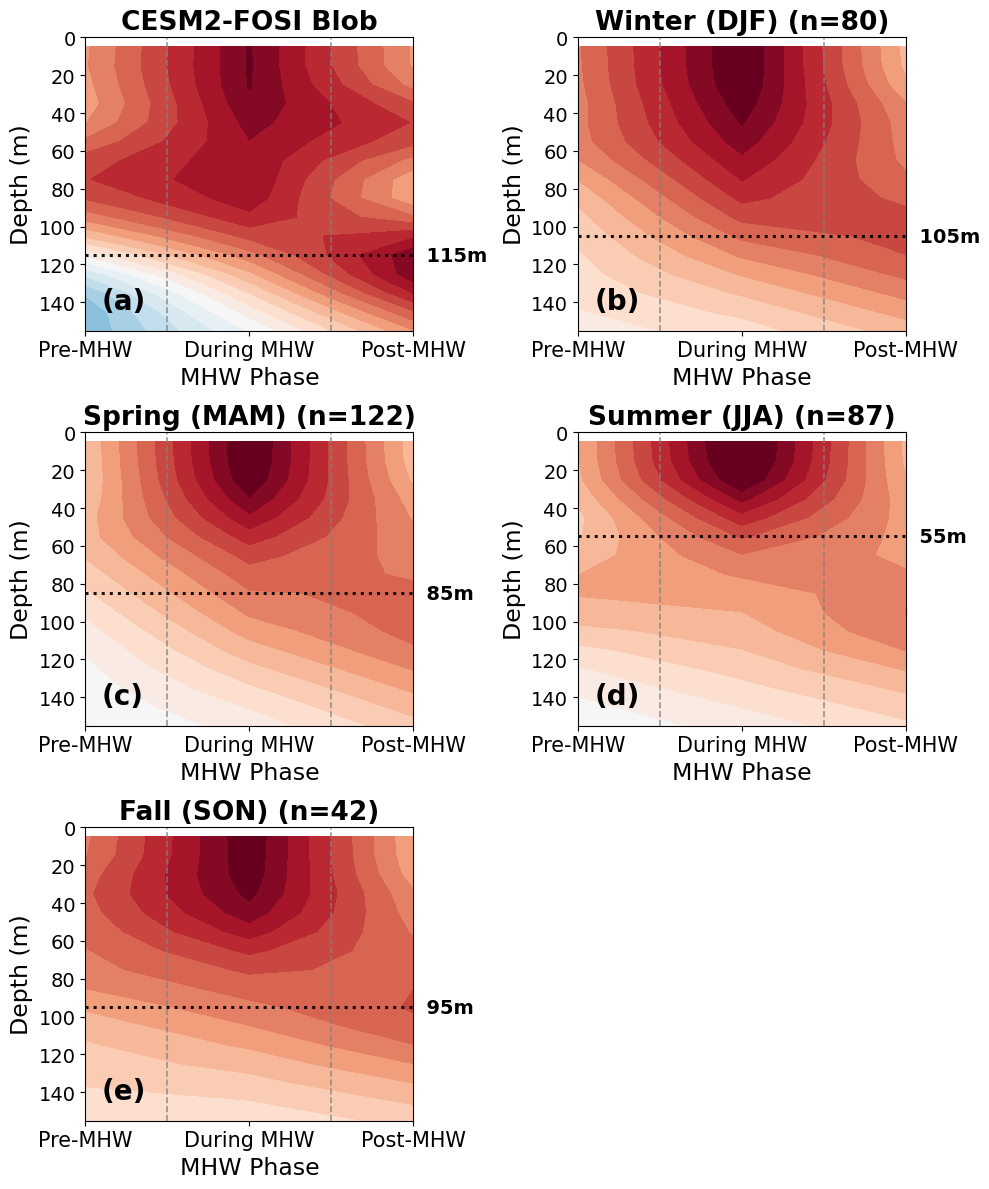

50%-decay depths: {'FOSI': 115.0, 'DJF': 105.0, 'MAM': 85.0, 'JJA': 55.0, 'SON': 95.0}


In [106]:
fig, axes = plt.subplots(3, 2, figsize=(10, 12))

season_labels = {'DJF': 'Winter (DJF)', 'MAM': 'Spring (MAM)', 'JJA': 'Summer (JJA)', 'SON': 'Fall (SON)'}
decay_depths = {}

def plot_panel(ax, phases, title, letter, n=None):
    phases.transpose().plot.contourf(
        ax=ax, yincrease=False, cmap='RdBu_r', robust=True,
        levels=25, vmin=-0.6, vmax=0.6, add_colorbar=False
    )
    for x in [0.5, 1.5]:
        ax.axvline(x, color='grey', linestyle='--', linewidth=1.2, alpha=0.8)

    detection_profile = phases.sel(phase='detection')
    surface_val = float(detection_profile.isel(z_t=0))
    half_max = surface_val * 0.5
    above_half = detection_profile.where(detection_profile >= half_max, drop=True)
    decay_depth_cm = float(above_half.z_t.max()) if above_half.size > 0 else np.nan

    ax.axhline(decay_depth_cm, color='black', linestyle=':', linewidth=2.2, alpha=0.9)
    ax.text(2.0, decay_depth_cm, f'  {decay_depth_cm/100:.0f}m', va='center', ha='left',
            fontsize=14, fontweight='bold', color='black')

    ax.set_xticks([0., 1., 2.])
    ax.set_xticklabels(["Pre-MHW", "During MHW", "Post-MHW"], fontsize=15)
    ax.set_yticks([0, 2000, 4000, 6000, 8000, 10000, 12000, 14000])
    ax.set_yticklabels([0, 20, 40, 60, 80, 100, 120, 140], fontsize=14)
    ax.set_xlabel("MHW Phase", fontsize=17)
    ax.set_ylabel("Depth (m)", fontsize=17)
    ax.set_ylim(15500, 0)
    full_title = f'{title} (n={n})' if n is not None else title
    ax.set_title(full_title, fontsize=19, fontweight='bold')
    ax.text(0.05, 0.15, letter, transform=ax.transAxes, fontsize=20, fontweight='bold', va='top')

    return decay_depth_cm / 100

# Row order: (FOSI, Winter), (Spring, Summer), (Fall, empty)
panels = [
    ('FOSI', fosi_phases, 'CESM2-FOSI Blob', '(a)', None),
    ('DJF', season_composites.get('DJF'), season_labels['DJF'], '(b)', len(season_groups['DJF'])),
    ('MAM', season_composites.get('MAM'), season_labels['MAM'], '(c)', len(season_groups['MAM'])),
    ('JJA', season_composites.get('JJA'), season_labels['JJA'], '(d)', len(season_groups['JJA'])),
    ('SON', season_composites.get('SON'), season_labels['SON'], '(e)', len(season_groups['SON'])),
]

axes_flat = axes.flatten()

for ax, (key, phases, title, letter, n) in zip(axes_flat, panels):
    if phases is None:
        ax.set_visible(False)
        continue
    decay_depths[key] = plot_panel(ax, phases, title, letter, n)

# Hide the unused 6th panel
axes_flat[5].set_visible(False)

plt.tight_layout()
plt.savefig('Figure_subsurface_2col.png', dpi=300, bbox_inches='tight')
plt.show()

print("50%-decay depths:", decay_depths)

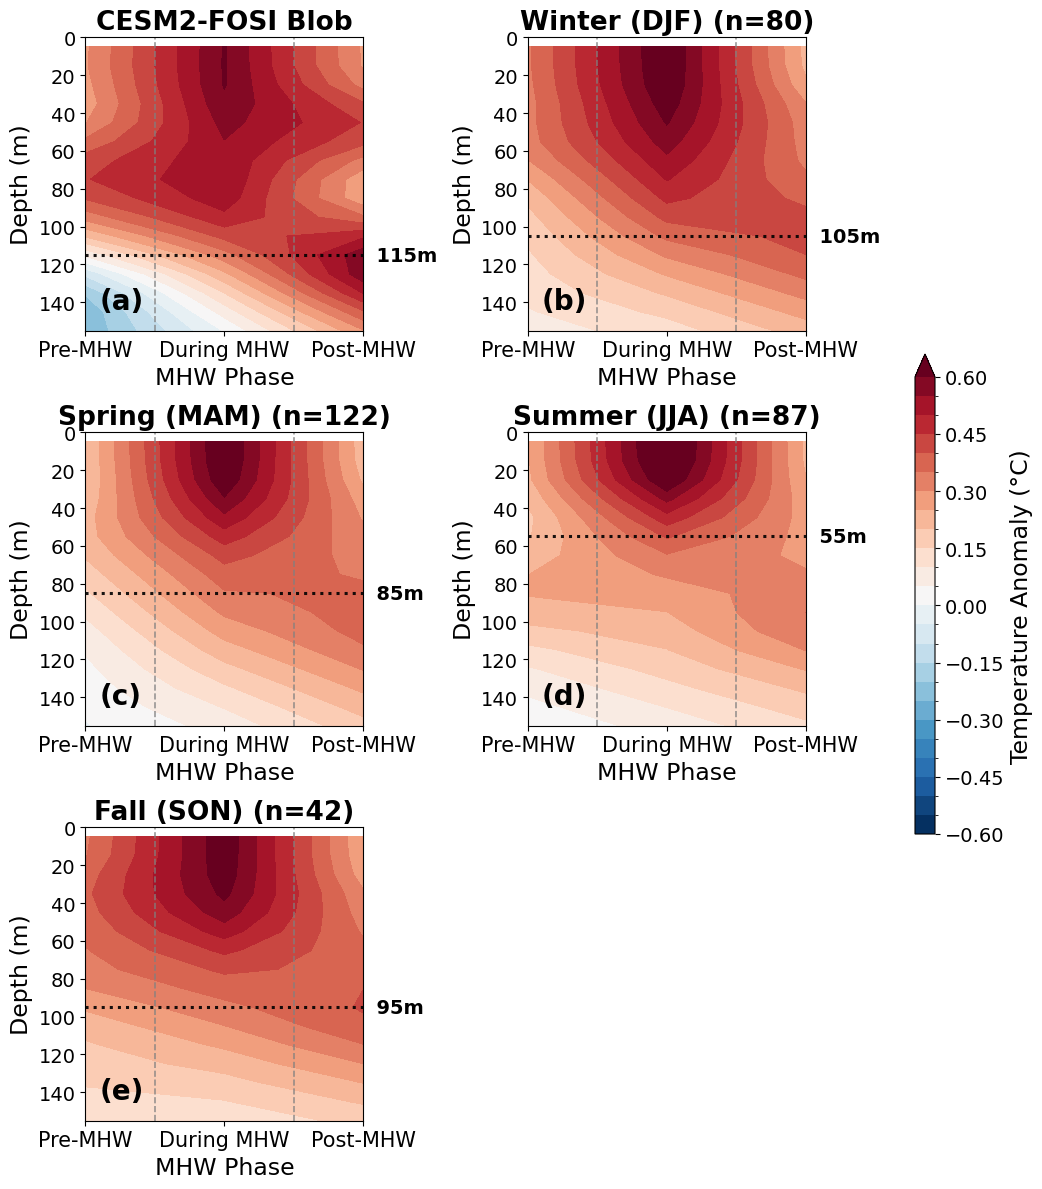

50%-decay depths: {'FOSI': 115.0, 'DJF': 105.0, 'MAM': 85.0, 'JJA': 55.0, 'SON': 95.0}


In [110]:
fig, axes = plt.subplots(3, 2, figsize=(10, 12))

season_labels = {'DJF': 'Winter (DJF)', 'MAM': 'Spring (MAM)', 'JJA': 'Summer (JJA)', 'SON': 'Fall (SON)'}
decay_depths = {}
last_contour = None

def plot_panel(ax, phases, title, letter, n=None):
    global last_contour
    contour = phases.transpose().plot.contourf(
        ax=ax, yincrease=False, cmap='RdBu_r', robust=True,
        levels=25, vmin=-0.6, vmax=0.6, add_colorbar=False
    )
    last_contour = contour

    for x in [0.5, 1.5]:
        ax.axvline(x, color='grey', linestyle='--', linewidth=1.2, alpha=0.8)

    detection_profile = phases.sel(phase='detection')
    surface_val = float(detection_profile.isel(z_t=0))
    half_max = surface_val * 0.5
    above_half = detection_profile.where(detection_profile >= half_max, drop=True)
    decay_depth_cm = float(above_half.z_t.max()) if above_half.size > 0 else np.nan

    ax.axhline(decay_depth_cm, color='black', linestyle=':', linewidth=2.2, alpha=0.9)
    ax.text(2.0, decay_depth_cm, f'  {decay_depth_cm/100:.0f}m', va='center', ha='left',
            fontsize=14, fontweight='bold', color='black')

    ax.set_xticks([0., 1., 2.])
    ax.set_xticklabels(["Pre-MHW", "During MHW", "Post-MHW"], fontsize=15)
    ax.set_yticks([0, 2000, 4000, 6000, 8000, 10000, 12000, 14000])
    ax.set_yticklabels([0, 20, 40, 60, 80, 100, 120, 140], fontsize=14)
    ax.set_xlabel("MHW Phase", fontsize=17)
    ax.set_ylabel("Depth (m)", fontsize=17)
    ax.set_ylim(15500, 0)
    full_title = f'{title} (n={n})' if n is not None else title
    ax.set_title(full_title, fontsize=19, fontweight='bold')
    ax.text(0.05, 0.15, letter, transform=ax.transAxes, fontsize=20, fontweight='bold', va='top')

    return decay_depth_cm / 100

panels = [
    ('FOSI', fosi_phases, 'CESM2-FOSI Blob', '(a)', None),
    ('DJF', season_composites.get('DJF'), season_labels['DJF'], '(b)', len(season_groups['DJF'])),
    ('MAM', season_composites.get('MAM'), season_labels['MAM'], '(c)', len(season_groups['MAM'])),
    ('JJA', season_composites.get('JJA'), season_labels['JJA'], '(d)', len(season_groups['JJA'])),
    ('SON', season_composites.get('SON'), season_labels['SON'], '(e)', len(season_groups['SON'])),
]

axes_flat = axes.flatten()

for ax, (key, phases, title, letter, n) in zip(axes_flat, panels):
    if phases is None:
        ax.set_visible(False)
        continue
    decay_depths[key] = plot_panel(ax, phases, title, letter, n)

axes_flat[5].set_visible(False)

plt.tight_layout(rect=[0, 0, 0.9, 1])

cbar_ax = fig.add_axes([0.92, 0.3, 0.02, 0.4])
cbar = fig.colorbar(last_contour, cax=cbar_ax)
cbar.set_label('Temperature Anomaly (°C)', fontsize=17)
cbar.ax.tick_params(labelsize=14)

plt.savefig('Figure_subsurface_2col_cbar_right.png', dpi=300, bbox_inches='tight')
plt.show()

print("50%-decay depths:", decay_depths)

In [111]:
N_years = 100 * 42
fosi_decay_depth = 115.0
fosi_max_penetration = 135.0

# Decay depth vs DJF
djf_decay = np.array(season_decay_depths_individual['DJF'])
p_djf_decay = np.mean(djf_decay >= fosi_decay_depth)
rp_djf_decay = N_years / (len(djf_decay) * p_djf_decay) if p_djf_decay > 0 else np.inf
print(f"Decay depth vs DJF: {100*p_djf_decay:.1f}% exceed, return period = {rp_djf_decay:.1f} years")

# Penetration depth vs DJF
djf_pen = np.array(season_penetration_depths_individual['DJF'])
p_djf_pen = np.mean(djf_pen >= fosi_max_penetration)
rp_djf_pen = N_years / (len(djf_pen) * p_djf_pen) if p_djf_pen > 0 else np.inf
print(f"Penetration depth vs DJF: {100*p_djf_pen:.1f}% exceed, return period = {rp_djf_pen:.1f} years")

Decay depth vs DJF: 41.2% exceed, return period = 127.3 years
Penetration depth vs DJF: 22.5% exceed, return period = 233.3 years


In [90]:
# ============================================================
# Standard deviation for penetration depth (0.5°C threshold)
# ============================================================
print(f"Max penetration depth: mean={depths_abs.mean():.1f}m, std={depths_abs.std():.1f}m, "
      f"median={np.median(depths_abs):.1f}m")

Max penetration depth: mean=106.8m, std=24.3m, median=105.0m


In [91]:
# ============================================================
# Standard deviation for 50%-decay depth, per season
# (need per-analog decay depths, not just the seasonal composite's single value)
# ============================================================
season_decay_depths_individual = {season: [] for season in ['DJF', 'MAM', 'JJA', 'SON']}

for key, phases in phase_profiles_all.items():
    season_month = subsurface_profiles[key]['season']
    season = get_season(season_month)

    detection_profile = phases.sel(phase='detection')
    surface_val = float(detection_profile.isel(z_t=0))
    if surface_val <= 0 or np.isnan(surface_val):
        continue
    half_max = surface_val * 0.5
    above_half = detection_profile.where(detection_profile >= half_max, drop=True)
    if above_half.size > 0:
        season_decay_depths_individual[season].append(float(above_half.z_t.max()) / 100)

for season, depths_list in season_decay_depths_individual.items():
    arr = np.array(depths_list)
    print(f"{season}: 50%-decay depth = {arr.mean():.1f}±{arr.std():.1f}m (n={len(arr)})")

DJF: 50%-decay depth = 106.8±26.1m (n=80)
MAM: 50%-decay depth = 86.1±32.0m (n=122)
JJA: 50%-decay depth = 76.1±36.7m (n=87)
SON: 50%-decay depth = 98.8±28.9m (n=42)


In [44]:
print(f"Total padded length: {len(fosi_profile.time)}")
print(f"blob_times (core event) length: {len(blob_times)}")
print(f"First padded time: {fosi_profile.time.values[0]}")
print(f"Last padded time: {fosi_profile.time.values[-1]}")
print(f"blob_times start: {blob_times.values[0]}, end: {blob_times.values[-1]}")

print(f"\nIs index 21's date within blob_times? {fosi_profile.time.values[21] in blob_times.values}")

Total padded length: 24
blob_times (core event) length: 20
First padded time: 2014-03-15 00:00:00
Last padded time: 2016-02-15 00:00:00
blob_times start: 2014-05-15 00:00:00, end: 2015-12-15 00:00:00

Is index 21's date within blob_times? True


In [92]:
# ============================================================
# Standard deviation for duration, per season (reload from physical characteristics if needed)
# ============================================================
for season, keys in season_groups.items():
    valid_keys = [k for k in keys if k in all_analog_characteristics]
    durations = np.array([all_analog_characteristics[k]['duration'] for k in valid_keys])
    print(f"{season}: duration = {durations.mean():.1f}±{durations.std():.1f} months (n={len(valid_keys)})")

DJF: duration = 16.4±7.3 months (n=80)
MAM: duration = 13.6±7.3 months (n=122)
JJA: duration = 9.2±6.3 months (n=87)
SON: duration = 10.9±6.4 months (n=42)


In [94]:
N_years = 100 * 42

# ============================================================
# Return period for penetration depth (already have this, repeated for completeness)
# ============================================================
fosi_max_penetration = 135
p_pen = np.mean(depths_abs >= fosi_max_penetration)
rp_pen = N_years / (len(depths_abs) * p_pen) if p_pen > 0 else np.inf
print(f"Penetration depth (135m): {100*p_pen:.1f}% exceed, return period = {rp_pen:.1f} years")

# ============================================================
# Return period for 50%-decay depth, per season (comparing FOSI's own 115m against each season's distribution)
# ============================================================
fosi_decay_depth = 115.0

for season in ['DJF', 'MAM', 'JJA', 'SON']:
    depths_arr = np.array(season_decay_depths_individual[season])
    n = len(depths_arr)
    p = np.mean(depths_arr >= fosi_decay_depth)
    rp = N_years / (n * p) if p > 0 else np.inf
    print(f"{season} decay depth vs FOSI's 115m: {100*p:.1f}% of {season} analogs exceed, return period = {rp:.1f} years")

# ============================================================
# Return period for duration, per season (comparing FOSI's own 20-month duration against each season)
# ============================================================
fosi_duration = 20

for season, keys in season_groups.items():
    valid_keys = [k for k in keys if k in all_analog_characteristics]
    durations = np.array([all_analog_characteristics[k]['duration'] for k in valid_keys])
    n = len(durations)
    p = np.mean(durations >= fosi_duration)
    rp = N_years / (n * p) if p > 0 else np.inf
    print(f"{season} duration vs FOSI's 20 months: {100*p:.1f}% exceed, return period = {rp:.1f} years")

# ============================================================
# Overall (all seasons combined) return period for decay depth and duration,
# matching your original whole-population statistics
# ============================================================
all_decay_depths_flat = np.concatenate([np.array(v) for v in season_decay_depths_individual.values()])
p_decay_all = np.mean(all_decay_depths_flat >= fosi_decay_depth)
rp_decay_all = N_years / (len(all_decay_depths_flat) * p_decay_all) if p_decay_all > 0 else np.inf
print(f"\nOverall decay depth vs FOSI's 115m: {100*p_decay_all:.1f}% exceed, return period = {rp_decay_all:.1f} years")

all_durations_flat = np.array([all_analog_characteristics[k]['duration'] for k in all_analog_characteristics])
p_dur_all = np.mean(all_durations_flat >= fosi_duration)
rp_dur_all = N_years / (len(all_durations_flat) * p_dur_all) if p_dur_all > 0 else np.inf
print(f"Overall duration vs FOSI's 20 months: {100*p_dur_all:.1f}% exceed, return period = {rp_dur_all:.1f} years")

Penetration depth (135m): 17.8% exceed, return period = 71.2 years
DJF decay depth vs FOSI's 115m: 41.2% of DJF analogs exceed, return period = 127.3 years
MAM decay depth vs FOSI's 115m: 26.2% of MAM analogs exceed, return period = 131.2 years
JJA decay depth vs FOSI's 115m: 21.8% of JJA analogs exceed, return period = 221.1 years
SON decay depth vs FOSI's 115m: 26.2% of SON analogs exceed, return period = 381.8 years
DJF duration vs FOSI's 20 months: 28.7% exceed, return period = 182.6 years
MAM duration vs FOSI's 20 months: 23.0% exceed, return period = 150.0 years
JJA duration vs FOSI's 20 months: 9.2% exceed, return period = 525.0 years
SON duration vs FOSI's 20 months: 11.9% exceed, return period = 840.0 years

Overall decay depth vs FOSI's 115m: 28.7% exceed, return period = 44.2 years
Overall duration vs FOSI's 20 months: 19.3% exceed, return period = 65.6 years


In [95]:
# ============================================================
# Per-analog penetration depth (0.5°C absolute threshold), core event only (no padding)
# ============================================================
def find_max_penetration_depth_absolute_core(profile, times_present_length, pre_post_months=2, threshold_c=0.5):
    """
    profile: padded (time, z_t) DataArray
    times_present_length: number of months in the CORE event (excludes padding)
    Restricts the search to the core event window only, excluding Pre-MHW/Post-MHW padding.
    """
    core_profile = profile.isel(time=slice(pre_post_months, pre_post_months + times_present_length))

    above_threshold = core_profile.where(core_profile >= threshold_c)
    if above_threshold.isnull().all():
        return np.nan

    depth_reached = above_threshold.max(dim='time')
    valid_depths = depth_reached.where(depth_reached.notnull(), drop=True)
    if valid_depths.size == 0:
        return np.nan

    return float(valid_depths.z_t.max()) / 100

In [96]:
# ============================================================
# Apply per analog, split by season
# ============================================================
season_penetration_depths_individual = {season: [] for season in ['DJF', 'MAM', 'JJA', 'SON']}
analog_max_penetration_core = {}

for key, data in subsurface_profiles.items():
    profile = data['profile']
    season_month = data['season']
    season = get_season(season_month)

    # Need the core event length for this analog - pull from all_analog_characteristics
    if key not in all_analog_characteristics:
        continue
    core_length = all_analog_characteristics[key]['duration']

    depth_m = find_max_penetration_depth_absolute_core(profile, core_length, threshold_c=0.5)
    if not np.isnan(depth_m):
        analog_max_penetration_core[key] = depth_m
        season_penetration_depths_individual[season].append(depth_m)

print(f"Total analogs with penetration depth: {len(analog_max_penetration_core)}")

Total analogs with penetration depth: 331


In [97]:
# ============================================================
# Summary stats, per season and overall
# ============================================================
for season, depths_list in season_penetration_depths_individual.items():
    arr = np.array(depths_list)
    print(f"{season}: penetration depth = {arr.mean():.1f}±{arr.std():.1f}m (n={len(arr)})")

all_pen_depths = np.array(list(analog_max_penetration_core.values()))
print(f"\nOverall: penetration depth = {all_pen_depths.mean():.1f}±{all_pen_depths.std():.1f}m (n={len(all_pen_depths)})")

at_ceiling_core = np.sum(all_pen_depths >= 155)
print(f"Analogs reaching 155m ceiling: {at_ceiling_core}/{len(all_pen_depths)} ({100*at_ceiling_core/len(all_pen_depths):.1f}%)")

DJF: penetration depth = 110.9±24.3m (n=80)
MAM: penetration depth = 98.7±25.2m (n=122)
JJA: penetration depth = 82.9±29.4m (n=87)
SON: penetration depth = 98.6±23.0m (n=42)

Overall: penetration depth = 97.5±27.8m (n=331)
Analogs reaching 155m ceiling: 8/331 (2.4%)


In [98]:
# ============================================================
# Return periods: overall and MAM-specific (Blob's own season)
# ============================================================
fosi_max_penetration = 135
N_years = 100 * 42

p_overall = np.mean(all_pen_depths >= fosi_max_penetration)
rp_overall = N_years / (len(all_pen_depths) * p_overall) if p_overall > 0 else np.inf
print(f"Overall: {100*p_overall:.1f}% exceed 135m, return period = {rp_overall:.1f} years")

mam_depths = np.array(season_penetration_depths_individual['MAM'])
p_mam = np.mean(mam_depths >= fosi_max_penetration)
rp_mam = N_years / (len(mam_depths) * p_mam) if p_mam > 0 else np.inf
print(f"MAM only: {100*p_mam:.1f}% exceed 135m, return period = {rp_mam:.1f} years")

Overall: 12.1% exceed 135m, return period = 105.0 years
MAM only: 12.3% exceed 135m, return period = 280.0 years


In [51]:
def five_phases(profile, ssta_profile=None, pre_post_months=2):
    """
    Splits a padded event profile into 5 phases:
    (1) Pre-MHW (first pre_post_months, i.e. before detection)
    (2) pre-peak (detection start to month of max SSTa)
    (3) maximum SSTa (the single peak month)
    (4) decline (month after peak to detection end)
    (5) Post-MHW (last pre_post_months, after detection)

    profile: DataArray (time, z_t), padded with pre_post_months on each side
    ssta_profile: 1D array-like (time,) or DataArray used to find peak month;
                  if None, uses the surface-most z_t level of `profile` as a proxy
    """
    n_total = len(profile.time)
    core_start = pre_post_months
    core_end = n_total - pre_post_months  # exclusive

    pre_mhw = profile.isel(time=slice(0, pre_post_months)).mean(dim='time')
    post_mhw = profile.isel(time=slice(-pre_post_months, None)).mean(dim='time')

    # Find peak month WITHIN the core (detected) period only
    if ssta_profile is None:
        ssta_profile = profile.isel(z_t=0)  # shallowest level as proxy for surface SSTa
    core_ssta = ssta_profile.isel(time=slice(core_start, core_end))
    peak_idx_within_core = int(core_ssta.argmax('time').values)
    peak_idx_global = core_start + peak_idx_within_core

    # Guard: if peak is at the very start or end of the core period, pre-peak or decline is undefined
    has_prepeak = peak_idx_global > core_start
    has_decline = peak_idx_global < core_end - 1

    prepeak = (profile.isel(time=slice(core_start, peak_idx_global)).mean(dim='time')
               if has_prepeak else xr.full_like(pre_mhw, np.nan))
    peak = profile.isel(time=peak_idx_global)
    decline = (profile.isel(time=slice(peak_idx_global + 1, core_end)).mean(dim='time')
               if has_decline else xr.full_like(pre_mhw, np.nan))

    return xr.concat([pre_mhw, prepeak, peak, decline, post_mhw], dim='phase').assign_coords(
        phase=['Pre-MHW', 'pre-peak', 'maximum SSTa', 'decline', 'Post-MHW']
    )

In [52]:
# ============================================================
# Apply to all analogs, using the shallowest depth level as the SSTa proxy for finding peak month
# ============================================================
phase_profiles_5 = {}
for key, data in subsurface_profiles.items():
    phase_profiles_5[key] = five_phases(data['profile'])

print(f"5-phase split complete: {len(phase_profiles_5)} analogs")

5-phase split complete: 331 analogs


In [53]:
# ============================================================
# Re-composite by season
# ============================================================
season_composites_5 = {}
for season, keys in season_groups.items():
    valid_keys = [k for k in keys if k in phase_profiles_5]
    if len(valid_keys) == 0:
        continue
    profiles_in_season = xr.concat([phase_profiles_5[k] for k in valid_keys], dim='analog')
    season_composites_5[season] = profiles_in_season.mean(dim='analog', skipna=True)

print(f"Composited (5-phase): {list(season_composites_5.keys())}")

Composited (5-phase): ['DJF', 'MAM', 'JJA', 'SON']


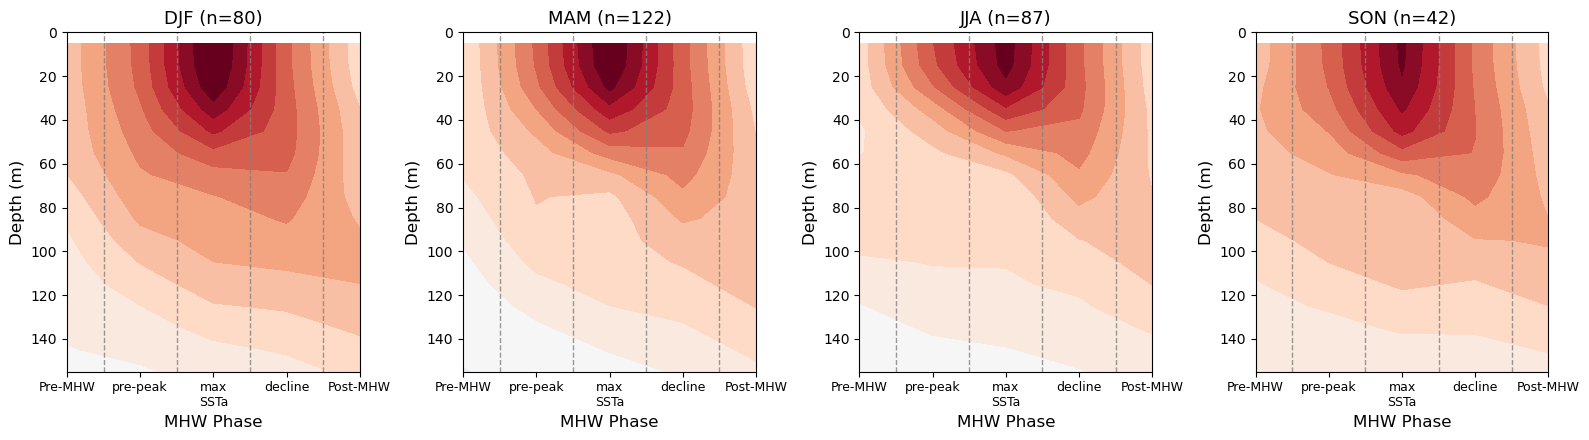

In [54]:
# ============================================================
# Plot - 5 columns instead of 3
# ============================================================
fig, axes = plt.subplots(1, 4, figsize=(16, 4.5))

for ax, season in zip(axes, ['DJF', 'MAM', 'JJA', 'SON']):
    if season not in season_composites_5:
        ax.set_visible(False)
        continue

    phases = season_composites_5[season]
    contour = phases.transpose().plot.contourf(
        ax=ax, yincrease=False, cmap='RdBu_r', robust=True,
        levels=21, vmin=-1, vmax=1, add_colorbar=False
    )

    for x in [0.5, 1.5, 2.5, 3.5]:
        ax.axvline(x, color='grey', linestyle='--', linewidth=1., alpha=0.8)

    ax.set_xticks([0, 1, 2, 3, 4])
    ax.set_xticklabels(["Pre-MHW", "pre-peak", "max\nSSTa", "decline", "Post-MHW"], fontsize=9, rotation=0)
    ax.set_yticks([0, 2000, 4000, 6000, 8000, 10000, 12000, 14000])
    ax.set_yticklabels([0, 20, 40, 60, 80, 100, 120, 140], fontsize=10)
    ax.set_xlabel("MHW Phase", fontsize=12)
    ax.set_ylabel("Depth (m)", fontsize=12)
    ax.set_ylim(15500, 0)
    ax.set_title(f'{season} (n={len(season_groups[season])})', fontsize=13)

plt.tight_layout()
plt.savefig('Figure_subsurface_5phase_seasonal.png', dpi=300, bbox_inches='tight')
plt.show()

In [55]:
with open('/glade/derecho/scratch/cassiacai/section_3_2_analog_data.pkl', 'rb') as f:
    physical_bundle = pickle.load(f)

all_analog_characteristics = physical_bundle['all_analog_characteristics']
blob_fosi_characteristics = physical_bundle['blob_fosi_characteristics']

print(f"Loaded {len(all_analog_characteristics)} analogs with physical characteristics")

# ============================================================
# Duration groups (using tercile splits, or fixed bins - let's check the distribution first)
# ============================================================
durations = np.array([all_analog_characteristics[k]['duration'] for k in phase_profiles_5 if k in all_analog_characteristics])
print(f"Duration range: {durations.min()}-{durations.max()} months")
print(f"Terciles: {np.percentile(durations, [33, 67])}")

Loaded 331 analogs with physical characteristics
Duration range: 2-39 months
Terciles: [ 8. 14.]


In [56]:
# Define duration bins based on the terciles (or adjust to round numbers once you see the printout)
def get_duration_group(dur, low_thresh, high_thresh):
    if dur <= low_thresh:
        return 'Short'
    elif dur <= high_thresh:
        return 'Medium'
    else:
        return 'Long'

low_thresh, high_thresh = np.percentile(durations, [33, 67])

duration_groups = {'Short': [], 'Medium': [], 'Long': []}
for key in phase_profiles_5:
    if key not in all_analog_characteristics:
        continue
    dur = all_analog_characteristics[key]['duration']
    group = get_duration_group(dur, low_thresh, high_thresh)
    duration_groups[group].append(key)

for group, keys in duration_groups.items():
    print(f"{group}: {len(keys)} analogs")

Short: 113 analogs
Medium: 116 analogs
Long: 102 analogs


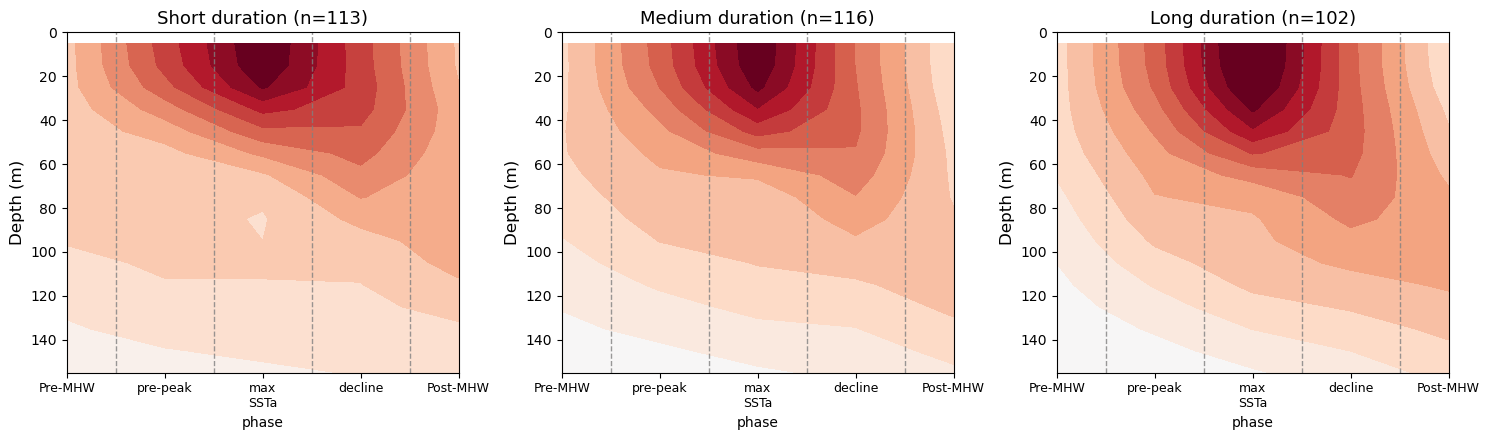

In [57]:
# Composite and plot by duration group
duration_composites = {}
for group, keys in duration_groups.items():
    if len(keys) == 0:
        continue
    profiles = xr.concat([phase_profiles_5[k] for k in keys], dim='analog')
    duration_composites[group] = profiles.mean(dim='analog', skipna=True)

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
for ax, group in zip(axes, ['Short', 'Medium', 'Long']):
    if group not in duration_composites:
        ax.set_visible(False)
        continue
    phases = duration_composites[group]
    phases.transpose().plot.contourf(ax=ax, yincrease=False, cmap='RdBu_r', robust=True,
                                       levels=21, vmin=-1, vmax=1, add_colorbar=False)
    for x in [0.5, 1.5, 2.5, 3.5]:
        ax.axvline(x, color='grey', linestyle='--', linewidth=1., alpha=0.8)
    ax.set_xticks([0,1,2,3,4])
    ax.set_xticklabels(["Pre-MHW","pre-peak","max\nSSTa","decline","Post-MHW"], fontsize=9)
    ax.set_yticks([0,2000,4000,6000,8000,10000,12000,14000])
    ax.set_yticklabels([0,20,40,60,80,100,120,140], fontsize=10)
    ax.set_ylabel("Depth (m)", fontsize=12)
    ax.set_ylim(15500, 0)
    ax.set_title(f'{group} duration (n={len(duration_groups[group])})', fontsize=13)

plt.tight_layout()
plt.savefig('Figure_subsurface_by_duration.png', dpi=300, bbox_inches='tight')
plt.show()

In [58]:
# ============================================================
# For each analog, find the depth of maximum SSTa at the peak phase
# ============================================================
depth_of_max = {}
for key, phases in phase_profiles_5.items():
    peak_profile = phases.sel(phase='maximum SSTa')  # 1D array over z_t
    if peak_profile.isnull().all():
        continue
    max_depth_idx = int(peak_profile.argmax('z_t').values)
    depth_of_max[key] = float(peak_profile.z_t.values[max_depth_idx]) / 100  # convert to meters

depths = np.array(list(depth_of_max.values()))
print(f"Depth of max SSTa range: {depths.min():.0f}-{depths.max():.0f} m")
print(f"Terciles: {np.percentile(depths, [33, 67])}")

Depth of max SSTa range: 5-75 m
Terciles: [ 5. 25.]


In [59]:
low_d, high_d = np.percentile(depths, [33, 67])

def get_depth_group(d, low, high):
    if d <= low: return 'Shallow'
    elif d <= high: return 'Mid'
    else: return 'Deep'

depth_groups = {'Shallow': [], 'Mid': [], 'Deep': []}
for key, d in depth_of_max.items():
    group = get_depth_group(d, low_d, high_d)
    depth_groups[group].append(key)

for group, keys in depth_groups.items():
    print(f"{group}: {len(keys)} analogs")

Shallow: 188 analogs
Mid: 56 analogs
Deep: 87 analogs


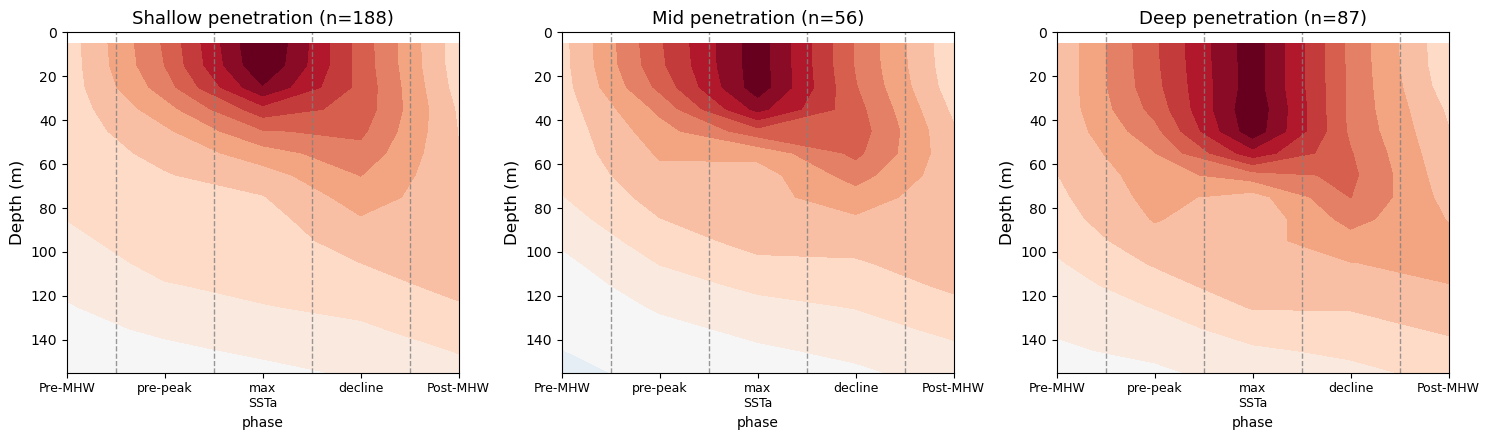

In [60]:
depth_composites = {}
for group, keys in depth_groups.items():
    if len(keys) == 0:
        continue
    profiles = xr.concat([phase_profiles_5[k] for k in keys], dim='analog')
    depth_composites[group] = profiles.mean(dim='analog', skipna=True)

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
for ax, group in zip(axes, ['Shallow', 'Mid', 'Deep']):
    if group not in depth_composites:
        ax.set_visible(False)
        continue
    phases = depth_composites[group]
    phases.transpose().plot.contourf(ax=ax, yincrease=False, cmap='RdBu_r', robust=True,
                                       levels=21, vmin=-1, vmax=1, add_colorbar=False)
    for x in [0.5, 1.5, 2.5, 3.5]:
        ax.axvline(x, color='grey', linestyle='--', linewidth=1., alpha=0.8)
    ax.set_xticks([0,1,2,3,4])
    ax.set_xticklabels(["Pre-MHW","pre-peak","max\nSSTa","decline","Post-MHW"], fontsize=9)
    ax.set_yticks([0,2000,4000,6000,8000,10000,12000,14000])
    ax.set_yticklabels([0,20,40,60,80,100,120,140], fontsize=10)
    ax.set_ylabel("Depth (m)", fontsize=12)
    ax.set_ylim(15500, 0)
    ax.set_title(f'{group} penetration (n={len(depth_groups[group])})', fontsize=13)

plt.tight_layout()
plt.savefig('Figure_subsurface_by_depth.png', dpi=300, bbox_inches='tight')
plt.show()

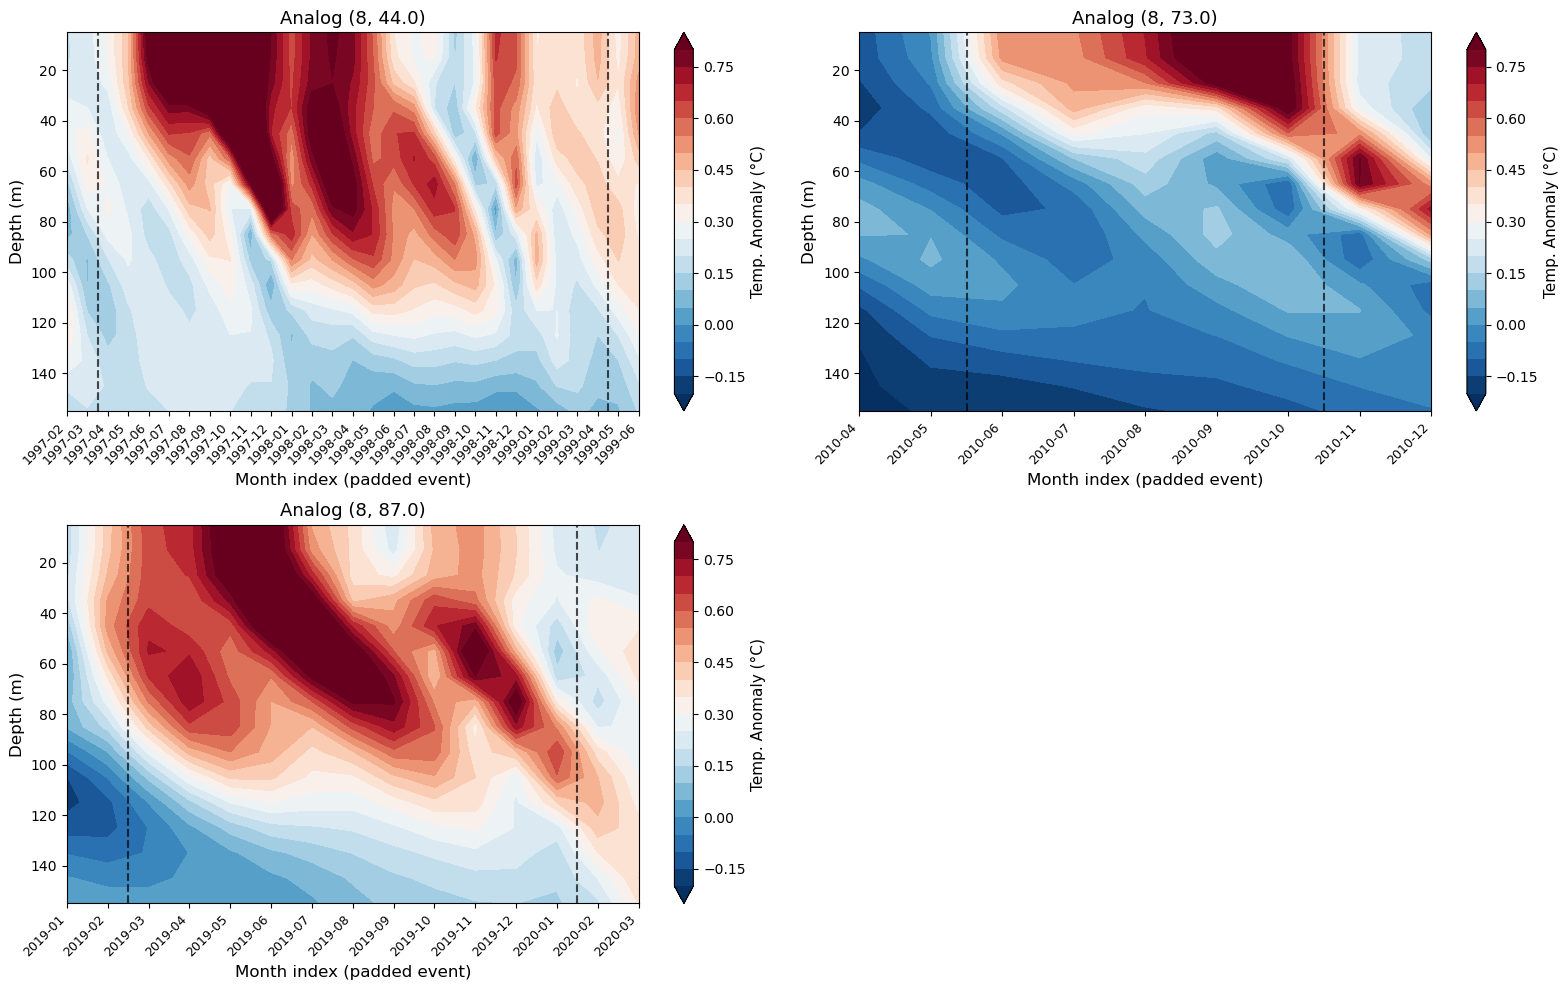

In [5]:
n_analogs = len(member_0_data)
ncols = 2
nrows = int(np.ceil(n_analogs / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(16, 5*nrows))
axes = np.atleast_1d(axes).flatten()

for ax, (key, data) in zip(axes, member_0_data.items()):
    profile = data['profile']
    depth_m = profile.z_t.values / 100

    im = ax.contourf(
        np.arange(len(profile.time)), depth_m, profile.values.T,
        levels=np.linspace(-0.2, 0.8, 21), cmap='RdBu_r', extend='both'
    )

    ax.invert_yaxis()
    ax.set_xlabel('Month index (padded event)', fontsize=12)
    ax.set_ylabel('Depth (m)', fontsize=12)
    ax.set_title(f'Analog {key}', fontsize=13)

    month_labels = [str(t)[:7] for t in profile.time.values]
    ax.set_xticks(np.arange(len(profile.time)))
    ax.set_xticklabels(month_labels, rotation=45, ha='right', fontsize=9)

    ax.axvline(1.5, color='k', linestyle='--', linewidth=1.5, alpha=0.7)
    ax.axvline(len(profile.time)-2.5, color='k', linestyle='--', linewidth=1.5, alpha=0.7)

    cbar = fig.colorbar(im, ax=ax)
    cbar.set_label('Temp. Anomaly (°C)', fontsize=11)

# Hide any unused axes if n_analogs isn't a perfect multiple of ncols
for ax in axes[n_analogs:]:
    ax.set_visible(False)

plt.tight_layout()
# plt.savefig('Figure_subsurface_member0_analogs.png', dpi=300, bbox_inches='tight')
plt.show()